# Maternal Stage EF — Pre vs Post (PD1/PD3/PD4) (1-Hz frequency)

## Task
Binary classification: y=0 pre-conception, y=1 early postpartum (PD1 + PD3 + PD4 home-cage).
1-Hz-resolution feature set to investigate finer frequency structure than the 3-band variant.

## Model
**dCSFA-NMF Ver1**
- `n_components=10`, `n_sup_networks=1`
- Encoder: `Linear(1944 → 128) + BN + LeakyReLU + Linear(128 → 10) + Softplus`
- Optimizer: `SGD, lr=1e-3, momentum=0.9, batch_size=512`
- `sup_weight (μ) = 0.03`, `fixed_corr="Positive"`, `recon_loss=MSE`
- `nmf_max_iter=500` (larger than 3-band sister to accommodate higher dim_in)

## Training data
`Spec_Features_1Hz_8roi/combined/full_spec_features_Trim_All.pkl`
- 8 C-group animals (control)
- Features: 54 × 1-Hz bins (2-56 Hz) × (8-ROI power + 28-pair coherence) = 1944 dims

## Pipeline (3-stage nested LOO — see Methods)
1. **Step 1 — Validation-split LOO**: 9:1 train/val per fold + early stopping (patience=20)
2. **Step 2 — Pure LOO**: re-run with fixed `n_epochs=400` for fold-wise test AUC
3. **Step 3 — Final model on all C animals** → `Maternal_model_TrainC_Pre_P134_1Hz_*.pt`

## Outputs
- Final model checkpoint
- Loadings **dot-heatmap** (1-Hz layout): `Selection_PrePost_1Hz_*.{png,pdf}`
- Circos inputs (MATLAB): `AreaNames.mat`, `NormalizedCrossSpectra.mat`
- LOO summary

## Backproject
- **Untrimmed full stages** (Pre/Ges/P1/P3/P4/P8/P14/P20)
- **Cross-task**: On/Off-nest, Licking vs NonLicking, Licking vs Grooming, Pup Retrieval (PD4)
- **External**: ELS animals (E group)

## Sister notebook
`PreVsPost134_3band.ipynb` — same task with 3 wide bands (2-7, 8-12, 14-23 Hz)


In [10]:
# Allow imports from ../src (this notebook lives in notebooks/, model code in src/)
import sys, os
_repo_root = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
if os.path.join(_repo_root, 'src') not in sys.path:
    sys.path.insert(0, os.path.join(_repo_root, 'src'))

from dCSFA_NMF_Ver1 import dCSFA_NMF
import umc_data_tools as umc_dt
import pandas as pd
import pickle
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import roc_auc_score
from scipy.stats import mannwhitneyu
from matplotlib.lines import Line2D
import matplotlib.cm as cm
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

def get_W_nmf(W_nmf):
        W = nn.Softplus()(W_nmf)
        return W

def process_W_nmf(W_normalized, train_dict, threshold_ratio=0.9):

    rows_power = train_dict["region"][:8]
    rows_coh = train_dict["region_pair"][:28]
    columns = train_dict["freq_band"]

    total_rows = len(rows_power) + len(rows_coh)
    df = pd.DataFrame(W_normalized[0, :].detach().numpy().reshape(total_rows, len(columns)),
                      index=rows_power + rows_coh,
                      columns=columns)

#     squared_values = df.values ** 2
#     flattened_squared_values = squared_values.flatten()
#     total_l2_norm = np.sqrt(np.sum(flattened_squared_values))
#     sorted_indices = np.argsort(flattened_squared_values)[::-1]
#     sorted_squared_values = flattened_squared_values[sorted_indices]
#     cumulative_sum = np.cumsum(sorted_squared_values)
#     cumulative_l2_norm = np.sqrt(cumulative_sum)
#     threshold = threshold_ratio * total_l2_norm
#     selected_indices = sorted_indices[cumulative_l2_norm <= threshold]
#     selected_positions = np.unravel_index(selected_indices, df.shape)

    squared_values = df.values ** 2
    flattened_squared_values = squared_values.flatten()
    total_l2_square = np.sum(flattened_squared_values)
    sorted_indices = np.argsort(flattened_squared_values)[::-1]
    sorted_squared_values = flattened_squared_values[sorted_indices]
    cumulative_sum = np.cumsum(sorted_squared_values)
    threshold = threshold_ratio * total_l2_square
    selected_indices = sorted_indices[cumulative_sum <= threshold]
    selected_positions = np.unravel_index(selected_indices, df.shape)


    df_selected = pd.DataFrame(np.nan, index=df.index, columns=df.columns)
    for row, col in zip(selected_positions[0], selected_positions[1]):
        df_selected.iat[row, col] = df.iat[row, col]
    
    pd.set_option('display.float_format', lambda x: '%.3f' % x)
    print("Selected DataFrame (df_selected):")
    print(df_selected)
    
    return df, df_selected

def process_W_nmf_k(W_normalized, train_dict, threshold_ratio=0.9, k=0):

    rows_power = train_dict["region"][:8]
    rows_coh = train_dict["region_pair"][:28]
    columns = train_dict["freq_band"]

    total_rows = len(rows_power) + len(rows_coh)
    df = pd.DataFrame(W_normalized[k, :].detach().numpy().reshape(total_rows, len(columns)),
                      index=rows_power + rows_coh,
                      columns=columns)

    squared_values = df.values ** 2
    flattened_squared_values = squared_values.flatten()
    total_l2_square = np.sum(flattened_squared_values)
    sorted_indices = np.argsort(flattened_squared_values)[::-1]
    sorted_squared_values = flattened_squared_values[sorted_indices]
    cumulative_sum = np.cumsum(sorted_squared_values)
    threshold = threshold_ratio * total_l2_square
    selected_indices = sorted_indices[cumulative_sum <= threshold]
    selected_positions = np.unravel_index(selected_indices, df.shape)


    df_selected = pd.DataFrame(np.nan, index=df.index, columns=df.columns)
    for row, col in zip(selected_positions[0], selected_positions[1]):
        df_selected.iat[row, col] = df.iat[row, col]
    
    pd.set_option('display.float_format', lambda x: '%.3f' % x)
    print("Selected DataFrame (df_selected):")
    print(df_selected)
    
    return df, df_selected

# Data Loading and Processing for Trimmed Data

# LOO Training

In [2]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_auc_score

In [3]:
def calculate_per_mouse_auc(model, X, y_true, mouse_ids, dataset_name):
    """
    Calculate ROC-AUC for each mouse and return summary statistics
    CRITICAL: Ensures model is in eval mode
    """
    # CRITICAL: Ensure eval mode
    was_training = model.training
    model.eval()
    
    # Model predictions
    y_pred_proba, s = model.predict_proba(X, include_scores=True)
    
    # Restore original mode
    if was_training:
        model.train()
    
    # Overall AUC
    overall_auc = roc_auc_score(y_true, y_pred_proba)
    print(f"\n=== {dataset_name} Results ===")
    print(f"Overall AUC: {overall_auc:.4f}")
    
    # Per-mouse AUC
    unique_mouse_ids = np.unique(mouse_ids)
    per_mouse_aucs = []
    
    print("Per-mouse AUC:")
    for mouse_id in unique_mouse_ids:
        mouse_mask = mouse_ids == mouse_id
        y_true_mouse = y_true[mouse_mask]
        y_pred_mouse = y_pred_proba[mouse_mask]
        
        if len(np.unique(y_true_mouse)) > 1:
            mouse_auc = roc_auc_score(y_true_mouse, y_pred_mouse)
            per_mouse_aucs.append(mouse_auc)
            print(f"  {mouse_id}: {mouse_auc:.4f} (n={len(y_true_mouse)})")
        else:
            print(f"  {mouse_id}: skipped - single class (n={len(y_true_mouse)})")
    
    if per_mouse_aucs:
        mean_auc = np.mean(per_mouse_aucs)
        std_auc = np.std(per_mouse_aucs, ddof=1)
        sem_auc = std_auc / np.sqrt(len(per_mouse_aucs))
        print(f"Mean ± SEM: {mean_auc:.4f} ± {sem_auc:.4f} (n={len(per_mouse_aucs)} mice)")
        return overall_auc, per_mouse_aucs, mean_auc, std_auc, sem_auc
    else:
        print("No mice available for AUC calculation")
        return overall_auc, [], None, None, None

In [ ]:
# ================================================================
# LOO Cross-Validation with 10% Validation Split
# Task: Pre home (y=0) vs P1/P3/P4 home (y=1) - has pups
# Data: 8 C group mice
# Purpose: Determine optimal sup_weight and n_epochs
# ================================================================

import pickle
import numpy as np
import os
import shutil
import re
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from scipy.stats import wilcoxon
import matplotlib.pyplot as plt
import torch

# # Import the fixed model
# from dCSFA_NMF_v1_3_fixed import dCSFA_NMF

# ================================================================
# Setup output directories (， "Too many links")
# ================================================================
OUTPUT_DIR = "./results_prehome_loo_val"
MODEL_CHECKPOINT_DIR = "./model_checkpoints_prehome"




import tempfile
TEMP_MODEL_FILE = os.path.join(tempfile.gettempdir(), "temp_best_model.pt")
print(f"Using temp file: {TEMP_MODEL_FILE}")
# 
if os.path.exists(TEMP_MODEL_FILE):
    os.remove(TEMP_MODEL_FILE)




for d in [OUTPUT_DIR, MODEL_CHECKPOINT_DIR]:
    if os.path.exists(d):
        shutil.rmtree(d)
    os.makedirs(d, exist_ok=True)
print("Directories cleaned and recreated.\n")

if os.path.exists(TEMP_MODEL_FILE):
    os.remove(TEMP_MODEL_FILE)

# ================================================================
# PART 1: Data Loading and Preparation
# ================================================================

TRAINING_DATA_FILE = "/Volumes/rdss_rhultman/datashare/ELS and Maternal Behavior/Spec_Features_1Hz_8roi/combined/full_spec_features_Trim_All.pkl"
X_FEATURE_LIST = ["power", "coh_sq_coherence"]
X_FEATURE_WEIGHTS = [1, 1]
Y_FEATURE = "period"

print("=" * 60)
print("LOADING DATA")
print("=" * 60)

with open(TRAINING_DATA_FILE, "rb") as f:
    train_dict = pickle.load(f)

print("Data loaded successfully!")

# Define filters
periods_to_keep = ['Pre home', 'P1', 'P3', 'P4 home']
target_mouse_ids = ['C7ELS11', 'C2ELS18', 'C5ELS20', 'C7ELS22', 
                   'C1ELS32', 'C5ELS40', 'C6ELS42', 'C7ELS45']

# Clean mouse_id
def clean_mouse_id(mouse_id):
    cleaned = mouse_id.replace('Mouse', '')
    cleaned = re.sub(r'F\d+', '', cleaned)
    return cleaned

cleaned_mouse_ids = np.array([clean_mouse_id(mid) for mid in train_dict['mouse_id']])

# Create filter mask
period_mask = np.isin(train_dict[Y_FEATURE], periods_to_keep)
mouse_mask = np.isin(cleaned_mouse_ids, target_mouse_ids)
combined_mask = period_mask & mouse_mask

print(f"\nFiltered samples: {np.sum(combined_mask)}")

# Filter all arrays
filtered_data = {}
for key in train_dict:
    if isinstance(train_dict[key], np.ndarray) and len(train_dict[key]) == len(train_dict[Y_FEATURE]):
        filtered_data[key] = train_dict[key][combined_mask]

# Update cleaned mouse_ids
filtered_mouse_ids = cleaned_mouse_ids[combined_mask]

# Build X
X_data = np.hstack([filtered_data[feature] * weight for feature, weight in zip(X_FEATURE_LIST, X_FEATURE_WEIGHTS)])

# Build y: Pre home = 0, P1/P3/P4 home = 1
y_binary = np.zeros(len(filtered_data[Y_FEATURE]), dtype=int)
positive_periods = ['P1', 'P3', 'P4 home']
positive_mask = np.isin(filtered_data[Y_FEATURE], positive_periods)
y_binary[positive_mask] = 1
y_data = y_binary.reshape(-1, 1)

mouse_ids_data = filtered_mouse_ids
y_sampling_data = OrdinalEncoder().fit_transform(mouse_ids_data.reshape(-1, 1))

print(f"\n{'='*60}")
print("DATASET STATISTICS")
print(f"{'='*60}")
print(f"X shape: {X_data.shape}")
print(f"y shape: {y_data.shape}")
print(f"Periods: {np.unique(filtered_data[Y_FEATURE])}")
print(f"With pups (y=1): {np.sum(y_data == 1)} ({np.sum(y_data == 1)/len(y_data)*100:.1f}%)")
print(f"Pre home (y=0): {np.sum(y_data == 0)} ({np.sum(y_data == 0)/len(y_data)*100:.1f}%)")
print(f"Unique mice: {np.unique(mouse_ids_data)}")
print(f"Number of mice: {len(np.unique(mouse_ids_data))}")

print("\nPer-mouse breakdown:")
for mouse_id in np.unique(mouse_ids_data):
    mask = mouse_ids_data == mouse_id
    mouse_y = y_data[mask]
    mouse_periods = filtered_data[Y_FEATURE][mask]
    label_0_count = np.sum(mouse_y == 0)
    label_1_count = np.sum(mouse_y == 1)
    unique_periods = np.unique(mouse_periods)
    print(f"  {mouse_id}: with_pups={label_1_count}, pre_home={label_0_count}, periods={unique_periods}")


# ================================================================
# PART 2: Model and Training Parameters
# ================================================================

model_params = {
    'n_components': 10,
    'dim_in': X_data.shape[1],
    'n_sup_networks': 1,
    'optim_name': "SGD",
    'recon_loss': "MSE",
    'sup_recon_weight': 0.0,
    'sup_weight': 0.03,            #  value
    'phi_weight': 0,
    'n_intercepts': 1,
    'useDeepEnc': True,
    'h': 128,
    'sup_recon_type': "Residual",
    'feature_groups': None,
    'group_weights': None,
    'fixed_corr': "Positive",
    'momentum': 0.9,
    'sup_smoothness_weight': 1
}

training_params = {
    'n_epochs': 500,
    'n_pre_epochs': 100,
    'nmf_max_iter': 500,
    'batch_size': 512,
    'lr': 1e-3,
    'pretrain': True,
    'verbose': True,
    # Early stopping parameters
    'patience': 20,
    'min_delta': 1e-4,
}

VAL_SPLIT = 0.1
SEED = 2025


# ================================================================
# PART 3: Plot Training History Function
# ================================================================

def plot_training_history(model, fold_idx, test_mouse, save_path=None):
    """Plot training and validation loss history for a single fold."""
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    
    # Total Loss
    axes[0, 0].plot(model.train_total_hist, label='Train', alpha=0.8, linewidth=1.5)
    if hasattr(model, 'val_total_hist') and len(model.val_total_hist) > 0:
        axes[0, 0].plot(model.val_total_hist, label='Validation', alpha=0.8, linewidth=1.5)
        if hasattr(model, 'best_epoch'):
            axes[0, 0].axvline(x=model.best_epoch, color='r', linestyle='--', 
                              linewidth=2, label=f'Best epoch: {model.best_epoch}')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].set_title('Total Loss')
    axes[0, 0].legend()
    axes[0, 0].grid(alpha=0.3)
    
    # Reconstruction Loss
    axes[0, 1].plot(model.train_recon_hist, label='Train', alpha=0.8, linewidth=1.5)
    if hasattr(model, 'val_recon_hist') and len(model.val_recon_hist) > 0:
        axes[0, 1].plot(model.val_recon_hist, label='Validation', alpha=0.8, linewidth=1.5)
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Loss')
    axes[0, 1].set_title('Reconstruction Loss (MSE)')
    axes[0, 1].legend()
    axes[0, 1].grid(alpha=0.3)
    
    # Prediction Loss
    axes[0, 2].plot(model.train_pred_hist, label='Train', alpha=0.8, linewidth=1.5)
    if hasattr(model, 'val_pred_hist') and len(model.val_pred_hist) > 0:
        axes[0, 2].plot(model.val_pred_hist, label='Validation', alpha=0.8, linewidth=1.5)
    axes[0, 2].set_xlabel('Epoch')
    axes[0, 2].set_ylabel('Loss')
    axes[0, 2].set_title('Prediction Loss (SUP_WEIGHT × BCE)')
    axes[0, 2].legend()
    axes[0, 2].grid(alpha=0.3)
    
    # Phi L2 Loss
    if hasattr(model, 'train_phi_loss_hist') and len(model.train_phi_loss_hist) > 0:
        axes[1, 0].plot(model.train_phi_loss_hist, label='Phi L2 Loss', alpha=0.8, linewidth=1.5)
        axes[1, 0].set_xlabel('Epoch')
        axes[1, 0].set_ylabel('Loss')
        axes[1, 0].set_title('Phi L2 Regularization Loss')
        axes[1, 0].legend()
        axes[1, 0].grid(alpha=0.3)
    else:
        axes[1, 0].text(0.5, 0.5, 'Phi L2 Loss\n(phi_weight=0)', 
                       ha='center', va='center', fontsize=12)
        axes[1, 0].set_title('Phi L2 Regularization Loss')
    
    # AUC History
    if hasattr(model, 'train_auc_hist') and len(model.train_auc_hist) > 0:
        train_aucs = [auc[0] for auc in model.train_auc_hist]
        axes[1, 1].plot(train_aucs, label='Train AUC', alpha=0.8, linewidth=1.5)
        if hasattr(model, 'val_auc_hist') and len(model.val_auc_hist) > 0:
            val_aucs = [auc[0] for auc in model.val_auc_hist]
            axes[1, 1].plot(val_aucs, label='Validation AUC', alpha=0.8, linewidth=1.5)
        axes[1, 1].axhline(y=0.5, color='gray', linestyle=':', alpha=0.5, label='Chance')
        axes[1, 1].set_xlabel('Epoch')
        axes[1, 1].set_ylabel('AUC')
        axes[1, 1].set_title('AUC History')
        axes[1, 1].legend()
        axes[1, 1].grid(alpha=0.3)
        axes[1, 1].set_ylim([0.4, 1.0])
    
    # Model Info
    info_text = f"Test Mouse: {test_mouse}\n"
    if hasattr(model, 'best_epoch'):
        info_text += f"Best Epoch: {model.best_epoch}\n"
    if hasattr(model, 'best_val_loss'):
        info_text += f"Best Val Loss: {model.best_val_loss:.4f}\n"
    if hasattr(model, 'phi_list'):
        actual_phi = model.get_phi(0).item()
        raw_phi = model.phi_list[0].item()
        info_text += f"Actual φ: {actual_phi:.4f}\n"
        info_text += f"(Raw param: {raw_phi:.4f})"
    
    axes[1, 2].text(0.5, 0.5, info_text, transform=axes[1, 2].transAxes,
                   fontsize=14, verticalalignment='center', horizontalalignment='center',
                   bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    axes[1, 2].set_title('Model Info')
    axes[1, 2].axis('off')
    
    plt.suptitle(f'Fold {fold_idx+1} Training History (Test: {test_mouse})', 
                fontsize=14, fontweight='bold')
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()


# ================================================================
# PART 4: LOO with Validation Split
# ================================================================

def leave_one_out_with_val_split(X, y, mouse_ids, y_sampling,
                                  model_params, training_params, 
                                  val_split=0.1, seed=2025):
    """LOO cross-validation with validation split for early stopping."""
    unique_mice = np.unique(mouse_ids)
    n_mice = len(unique_mice)
    
    print(f"\n{'='*80}")
    print(f"LEAVE-ONE-OUT CROSS-VALIDATION WITH {int(val_split*100)}% VALIDATION SPLIT")
    print(f"{'='*80}")
    print(f"Total mice: {n_mice}")
    print(f"Each fold: {int((1-val_split)*100)}% train, {int(val_split*100)}% validation")
    print(f"Early stopping: patience={training_params.get('patience')}, min_delta={training_params.get('min_delta')}")
    
    results = {}
    all_test_aucs = []
    all_best_epochs = []
    all_models = []
    
    for i, test_mouse in enumerate(unique_mice):
        print(f"\n{'='*60}")
        print(f"Fold {i+1}/{n_mice}: Test mouse = {test_mouse}")
        print(f"{'='*60}")
        
        # Split data
        test_mask = mouse_ids == test_mouse
        train_full_mask = ~test_mask
        
        X_train_full = X[train_full_mask]
        y_train_full = y[train_full_mask]
        mouse_ids_train_full = mouse_ids[train_full_mask]
        
        X_test = X[test_mask]
        y_test = y[test_mask]
        
        print(f"Full training set: {X_train_full.shape[0]} samples from {len(np.unique(mouse_ids_train_full))} mice")
        print(f"Test set: {X_test.shape[0]} samples from mouse {test_mouse}")
        print(f"Test set - with_pups={np.sum(y_test == 1)}, pre_home={np.sum(y_test == 0)}")
        
        # Check test set
        if len(np.unique(y_test)) <= 1:
            print(f"⚠ Skipping mouse {test_mouse} - only one class in test set")
            results[test_mouse] = {
                'test_auc': None,
                'test_samples': X_test.shape[0],
                'test_with_pups': int(np.sum(y_test == 1)),
                'test_pre_home': int(np.sum(y_test == 0)),
                'skip_reason': 'single_class'
            }
            continue
        
        # 90:10 Split for Validation
        fold_seed = seed + i
        random.seed(fold_seed)
        np.random.seed(fold_seed)
        torch.manual_seed(fold_seed)
        torch.cuda.manual_seed_all(fold_seed)
        
        try:
            X_train, X_val, y_train, y_val, mouse_ids_train, mouse_ids_val = \
                train_test_split(
                    X_train_full, y_train_full, mouse_ids_train_full,
                    test_size=val_split, random_state=fold_seed, stratify=y_train_full.squeeze()
                )
        except ValueError as e:
            print(f"Warning: Stratified split failed, using random split. Error: {e}")
            X_train, X_val, y_train, y_val, mouse_ids_train, mouse_ids_val = \
                train_test_split(
                    X_train_full, y_train_full, mouse_ids_train_full,
                    test_size=val_split, random_state=fold_seed
                )
        
        print(f"After {int((1-val_split)*100)}:{int(val_split*100)} split:")
        print(f"  Train: {X_train.shape[0]} samples (with_pups={np.sum(y_train==1)}, pre_home={np.sum(y_train==0)})")
        print(f"  Val: {X_val.shape[0]} samples (with_pups={np.sum(y_val==1)}, pre_home={np.sum(y_val==0)})")
        
        # Re-encode y_sampling for training set
        y_sampling_encoder = OrdinalEncoder()
        y_sampling_train = y_sampling_encoder.fit_transform(mouse_ids_train.reshape(-1, 1))
        
        # Create model
        model = dCSFA_NMF(**model_params)
        
        # Prepare training params - file
        train_params_with_val = {
            'n_epochs': training_params['n_epochs'],
            'n_pre_epochs': training_params['n_pre_epochs'],
            'nmf_max_iter': training_params['nmf_max_iter'],
            'batch_size': training_params['batch_size'],
            'lr': training_params['lr'],
            'pretrain': training_params['pretrain'],
            'verbose': training_params['verbose'],
            'X_val': X_val,
            'y_val': y_val,
            'patience': training_params.get('patience'),
            'min_delta': training_params.get('min_delta', 1e-4),
            'best_model_name': TEMP_MODEL_FILE,  # ← ，
        }
        
        # Train
        print(f"Training model for fold {i+1}...")
        model.fit(X_train, y_train,
                 y_sample_groups=y_sampling_train.squeeze(),
                 y_pred_weights=None,
                 intercept_mask=None,
                 task_mask=None,
                 **train_params_with_val)
        
        # Record best epoch
        best_epoch = model.best_epoch if hasattr(model, 'best_epoch') else training_params['n_epochs']
        all_best_epochs.append(best_epoch)
        print(f"Best epoch: {best_epoch}")
        
        # Plot training history for this fold
        plot_training_history(model, i, test_mouse, 
                            save_path=os.path.join(OUTPUT_DIR, f'training_history_fold{i+1}_{test_mouse}.png'))
        
        all_models.append(model)
        
        # Test
        model.eval()
        y_pred_proba, s_test = model.predict_proba(X_test, include_scores=True)
        test_auc = roc_auc_score(y_test, y_pred_proba)
        all_test_aucs.append(test_auc)
        
        print(f"✓ Test AUC: {test_auc:.4f}")
        
        # Store results
        results[test_mouse] = {
            'test_auc': test_auc,
            'test_samples': X_test.shape[0],
            'test_with_pups': int(np.sum(y_test == 1)),
            'test_pre_home': int(np.sum(y_test == 0)),
            'best_epoch': best_epoch,
            'best_val_loss': model.best_val_loss if hasattr(model, 'best_val_loss') else None,
            'phi_value': model.get_phi(0).item(),
            'y_pred_proba': y_pred_proba,
            'y_true': y_test
        }
    
    # Summary
    print(f"\n{'='*80}")
    print("LEAVE-ONE-OUT VALIDATION SUMMARY")
    print(f"{'='*80}")
    
    valid_aucs = [auc for auc in all_test_aucs if auc is not None]
    if valid_aucs:
        mean_auc = np.mean(valid_aucs)
        std_auc = np.std(valid_aucs, ddof=1)
        sem_auc = std_auc / np.sqrt(len(valid_aucs))
        
        print(f"\nCross-validation AUC: {mean_auc:.4f} ± {sem_auc:.4f} (mean ± SEM)")
        print(f"Standard deviation: {std_auc:.4f}")
        print(f"Valid folds: {len(valid_aucs)}/{n_mice}")
        
        print(f"\nBest Epoch Statistics:")
        print(f"  All best epochs: {all_best_epochs}")
        print(f"  Mean: {np.mean(all_best_epochs):.1f}")
        print(f"  Median: {int(np.median(all_best_epochs))}")
        print(f"  Min: {min(all_best_epochs)}, Max: {max(all_best_epochs)}")
        
        print(f"\nPer-mouse results:")
        for mouse, result in results.items():
            if result.get('test_auc') is not None:
                print(f"  {mouse}: AUC = {result['test_auc']:.4f}, "
                      f"best_epoch = {result['best_epoch']}, "
                      f"(n={result['test_samples']}, with_pups={result['test_with_pups']})")
            else:
                print(f"  {mouse}: skipped - {result.get('skip_reason', 'unknown')}")
    
    return results, valid_aucs, all_best_epochs, all_models


# ================================================================
# PART 5: Run LOO Cross-Validation
# ================================================================

print(f"\n{'='*80}")
print("STARTING LOO CROSS-VALIDATION WITH VALIDATION SPLIT")
print(f"{'='*80}")
print(f"Task: Pre home (y=0) vs With pups (y=1)")
print(f"Dataset: {X_data.shape[0]} samples from {len(np.unique(mouse_ids_data))} mice")

loo_results, valid_aucs, all_best_epochs, all_models = leave_one_out_with_val_split(
    X_data, y_data, mouse_ids_data, y_sampling_data,
    model_params, training_params,
    val_split=VAL_SPLIT, seed=SEED
)


# ================================================================
# PART 6: Statistical Analysis
# ================================================================

individual_aucs = np.array(valid_aucs)
n_mice = len(individual_aucs)

print(f"\n{'='*80}")
print("STATISTICAL ANALYSIS")
print(f"{'='*80}")

mean_auc = individual_aucs.mean()
std_auc = individual_aucs.std(ddof=1)
sem_auc = std_auc / np.sqrt(n_mice)
median_auc = np.median(individual_aucs)

print(f"\nNumber of mice: {n_mice}")
print(f"Individual AUCs: {individual_aucs}")
print(f"\nMean AUC: {mean_auc:.4f} ± {sem_auc:.4f} (SEM)")
print(f"Standard Deviation: {std_auc:.4f}")
print(f"Median AUC: {median_auc:.4f}")
print(f"Min: {individual_aucs.min():.4f}, Max: {individual_aucs.max():.4f}")

print(f"\nBest Epoch Statistics:")
print(f"  Median: {int(np.median(all_best_epochs))}")
print(f"  Mean: {np.mean(all_best_epochs):.1f}")
print(f"  Recommended n_epochs for final model: {int(np.median(all_best_epochs))}")

# Wilcoxon test
print(f"\n{'='*80}")
print("WILCOXON SIGNED-RANK TEST")
print(f"{'='*80}")

differences = individual_aucs - 0.5
statistic, p_value = wilcoxon(differences, alternative='greater')

print(f"\nDifferences from chance (0.5): {differences}")
print(f"\nWilcoxon Signed-Rank Test (one-sided)")
print(f"H0: AUC = 0.5, H1: AUC > 0.5")
print(f"Test Statistic: {statistic}")
print(f"P-value: {p_value:.6f}")

if p_value < 0.001: significance = "*** (p < 0.001)"
elif p_value < 0.01: significance = "** (p < 0.01)"
elif p_value < 0.05: significance = "* (p < 0.05)"
else: significance = "ns (not significant)"

print(f"Significance: {significance}")
print(f"Mice with AUC > 0.5: {np.sum(individual_aucs > 0.5)}/{n_mice}")


# ================================================================
# PART 7: Summary Visualization
# ================================================================

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

mice_names = list(loo_results.keys())
mice_aucs = [loo_results[m]['test_auc'] if loo_results[m].get('test_auc') is not None else 0 for m in mice_names]
colors = ['green' if auc > 0.5 else 'red' for auc in mice_aucs]

# Plot 1: Per-mouse AUC
axes[0, 0].bar(range(len(mice_names)), mice_aucs, color=colors, edgecolor='black', alpha=0.7)
axes[0, 0].axhline(y=0.5, color='gray', linestyle=':', linewidth=2, label='Chance')
axes[0, 0].axhline(y=mean_auc, color='blue', linestyle='--', linewidth=2, label=f'Mean: {mean_auc:.3f}')
axes[0, 0].set_xticks(range(len(mice_names)))
axes[0, 0].set_xticklabels(mice_names, rotation=45, ha='right')
axes[0, 0].set_xlabel('Mouse')
axes[0, 0].set_ylabel('Test AUC')
axes[0, 0].set_title('LOO Test AUC per Mouse')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3, axis='y')
axes[0, 0].set_ylim([0.3, 1.0])

# Plot 2: Box plot
axes[0, 1].boxplot([individual_aucs], widths=0.5, patch_artist=True,
                  boxprops=dict(facecolor='lightblue', alpha=0.7),
                  medianprops=dict(color='red', linewidth=2))
axes[0, 1].scatter(np.ones(n_mice), individual_aucs, alpha=0.6, s=100, color='navy', zorder=3)
axes[0, 1].axhline(y=0.5, color='gray', linestyle=':', linewidth=2)
axes[0, 1].set_ylabel('Test AUC')
axes[0, 1].set_title(f'AUC Distribution\n(Mean±SEM: {mean_auc:.3f}±{sem_auc:.3f}, p={p_value:.4f})')
axes[0, 1].set_xticks([1])
axes[0, 1].set_xticklabels([f'n={n_mice}'])
axes[0, 1].set_ylim([0.3, 1.0])
axes[0, 1].grid(alpha=0.3, axis='y')

# Plot 3: Best epochs
axes[0, 2].bar(range(len(all_best_epochs)), all_best_epochs, color='coral', edgecolor='black', alpha=0.7)
axes[0, 2].axhline(y=np.median(all_best_epochs), color='blue', linestyle='--', 
                  linewidth=2, label=f'Median: {int(np.median(all_best_epochs))}')
axes[0, 2].set_xticks(range(len(mice_names)))
axes[0, 2].set_xticklabels(mice_names, rotation=45, ha='right')
axes[0, 2].set_xlabel('Mouse')
axes[0, 2].set_ylabel('Best Epoch')
axes[0, 2].set_title('Best Epoch per Fold')
axes[0, 2].legend()
axes[0, 2].grid(alpha=0.3, axis='y')

# Plot 4: Differences from chance
diff_colors = ['green' if d > 0 else 'red' for d in differences]
axes[1, 0].bar(range(n_mice), differences, color=diff_colors, edgecolor='black', alpha=0.7)
axes[1, 0].axhline(y=0, color='gray', linestyle='-', linewidth=2)
axes[1, 0].set_xticks(range(n_mice))
axes[1, 0].set_xticklabels(mice_names, rotation=45, ha='right')
axes[1, 0].set_xlabel('Mouse')
axes[1, 0].set_ylabel('AUC - 0.5')
axes[1, 0].set_title('Difference from Chance Level')
axes[1, 0].grid(alpha=0.3, axis='y')

# Plot 5: AUC vs Best Epoch
best_epochs_valid = [loo_results[m]['best_epoch'] for m in mice_names if loo_results[m].get('test_auc') is not None]
aucs_valid = [loo_results[m]['test_auc'] for m in mice_names if loo_results[m].get('test_auc') is not None]
axes[1, 1].scatter(best_epochs_valid, aucs_valid, s=100, alpha=0.7, c='navy', edgecolors='black')
axes[1, 1].axhline(y=0.5, color='gray', linestyle=':', linewidth=2)
axes[1, 1].set_xlabel('Best Epoch')
axes[1, 1].set_ylabel('Test AUC')
axes[1, 1].set_title('Test AUC vs Best Epoch')
axes[1, 1].grid(alpha=0.3)

# Plot 6: Summary text
summary_text = f"""
LOO Cross-Validation Summary
{'='*35}

Task: Pre home vs With pups
Periods: Pre home, P1, P3, P4 home
Validation Split: {int(VAL_SPLIT*100)}%

Hyperparameters:
  sup_weight: {model_params['sup_weight']}
  n_epochs: {training_params['n_epochs']}
  patience: {training_params.get('patience')}

Results (n={n_mice} mice):
  Mean AUC: {mean_auc:.4f} ± {sem_auc:.4f}
  Std: {std_auc:.4f}
  Median: {median_auc:.4f}

Wilcoxon Test:
  p-value: {p_value:.6f}
  Significance: {significance}

Best Epoch:
  Median: {int(np.median(all_best_epochs))}
  Mean: {np.mean(all_best_epochs):.1f}
  
Recommended:
  n_epochs = {int(np.median(all_best_epochs))}
"""

axes[1, 2].text(0.05, 0.95, summary_text, transform=axes[1, 2].transAxes,
               fontsize=10, verticalalignment='top', fontfamily='monospace',
               bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
axes[1, 2].set_title('Summary')
axes[1, 2].axis('off')

plt.suptitle('LOO Cross-Validation: Pre home vs With pups (with 10% Validation)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'loo_validation_summary.png'), dpi=300, bbox_inches='tight')
plt.show()


# ================================================================
# PART 8: Aggregated Training Curves
# ================================================================

def plot_aggregated_training_curves(all_models, all_best_epochs, individual_aucs, mean_auc, save_path=None):
    """Plot aggregated training curves from all folds."""
    fig, axes = plt.subplots(3, 2, figsize=(14, 15))
    
    all_train_total = [m.train_total_hist for m in all_models]
    all_val_total = [m.val_total_hist for m in all_models if len(m.val_total_hist) > 0]
    all_train_recon = [m.train_recon_hist for m in all_models]
    all_val_recon = [m.val_recon_hist for m in all_models if len(m.val_recon_hist) > 0]
    all_train_pred = [m.train_pred_hist for m in all_models]
    all_val_pred = [m.val_pred_hist for m in all_models if len(m.val_pred_hist) > 0]
    all_train_auc = [[a[0] for a in m.train_auc_hist] for m in all_models if len(m.train_auc_hist) > 0]
    all_val_auc = [[a[0] for a in m.val_auc_hist] for m in all_models if len(m.val_auc_hist) > 0]
    
    # Total Loss
    for curve in all_train_total: axes[0, 0].plot(curve, alpha=0.3, color='blue')
    if all_train_total:
        min_len = min(len(c) for c in all_train_total)
        axes[0, 0].plot(np.mean([c[:min_len] for c in all_train_total], axis=0), 'b-', linewidth=2, label='Train (mean)')
    for curve in all_val_total: axes[0, 0].plot(curve, alpha=0.3, color='orange')
    if all_val_total:
        min_len = min(len(c) for c in all_val_total)
        axes[0, 0].plot(np.mean([c[:min_len] for c in all_val_total], axis=0), 'orange', linewidth=2, label='Val (mean)')
    axes[0, 0].set_xlabel('Epoch'); axes[0, 0].set_ylabel('Total Loss'); axes[0, 0].set_title('Total Loss (All Folds)')
    axes[0, 0].legend(); axes[0, 0].grid(alpha=0.3)
    
    # AUC
    for curve in all_train_auc: axes[0, 1].plot(curve, alpha=0.3, color='blue')
    if all_train_auc:
        min_len = min(len(c) for c in all_train_auc)
        axes[0, 1].plot(np.mean([c[:min_len] for c in all_train_auc], axis=0), 'b-', linewidth=2, label='Train (mean)')
    for curve in all_val_auc: axes[0, 1].plot(curve, alpha=0.3, color='orange')
    if all_val_auc:
        min_len = min(len(c) for c in all_val_auc)
        axes[0, 1].plot(np.mean([c[:min_len] for c in all_val_auc], axis=0), 'orange', linewidth=2, label='Val (mean)')
    axes[0, 1].axhline(y=0.5, color='gray', linestyle=':', alpha=0.5)
    axes[0, 1].set_xlabel('Epoch'); axes[0, 1].set_ylabel('AUC'); axes[0, 1].set_title('AUC (All Folds)')
    axes[0, 1].legend(); axes[0, 1].grid(alpha=0.3); axes[0, 1].set_ylim([0.4, 1.0])
    
    # Reconstruction Loss
    for curve in all_train_recon: axes[1, 0].plot(curve, alpha=0.3, color='blue')
    if all_train_recon:
        min_len = min(len(c) for c in all_train_recon)
        axes[1, 0].plot(np.mean([c[:min_len] for c in all_train_recon], axis=0), 'b-', linewidth=2, label='Train (mean)')
    for curve in all_val_recon: axes[1, 0].plot(curve, alpha=0.3, color='orange')
    if all_val_recon:
        min_len = min(len(c) for c in all_val_recon)
        axes[1, 0].plot(np.mean([c[:min_len] for c in all_val_recon], axis=0), 'orange', linewidth=2, label='Val (mean)')
    axes[1, 0].set_xlabel('Epoch'); axes[1, 0].set_ylabel('Recon Loss'); axes[1, 0].set_title('Reconstruction Loss (All Folds)')
    axes[1, 0].legend(); axes[1, 0].grid(alpha=0.3)
    
    # Prediction Loss
    for curve in all_train_pred: axes[1, 1].plot(curve, alpha=0.3, color='blue')
    if all_train_pred:
        min_len = min(len(c) for c in all_train_pred)
        axes[1, 1].plot(np.mean([c[:min_len] for c in all_train_pred], axis=0), 'b-', linewidth=2, label='Train (mean)')
    for curve in all_val_pred: axes[1, 1].plot(curve, alpha=0.3, color='orange')
    if all_val_pred:
        min_len = min(len(c) for c in all_val_pred)
        axes[1, 1].plot(np.mean([c[:min_len] for c in all_val_pred], axis=0), 'orange', linewidth=2, label='Val (mean)')
    axes[1, 1].set_xlabel('Epoch'); axes[1, 1].set_ylabel('Pred Loss'); axes[1, 1].set_title('Prediction Loss (All Folds)')
    axes[1, 1].legend(); axes[1, 1].grid(alpha=0.3)
    
    # Best epochs histogram
    axes[2, 0].hist(all_best_epochs, bins=20, color='coral', edgecolor='black', alpha=0.7)
    axes[2, 0].axvline(x=np.median(all_best_epochs), color='blue', linestyle='--', linewidth=2, label=f'Median: {int(np.median(all_best_epochs))}')
    axes[2, 0].set_xlabel('Best Epoch'); axes[2, 0].set_ylabel('Count'); axes[2, 0].set_title('Distribution of Best Epochs')
    axes[2, 0].legend(); axes[2, 0].grid(alpha=0.3)
    
    # Test AUC histogram
    axes[2, 1].hist(individual_aucs, bins=10, color='skyblue', edgecolor='black', alpha=0.7)
    axes[2, 1].axvline(x=0.5, color='gray', linestyle=':', linewidth=2, label='Chance')
    axes[2, 1].axvline(x=mean_auc, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_auc:.3f}')
    axes[2, 1].set_xlabel('Test AUC'); axes[2, 1].set_ylabel('Count'); axes[2, 1].set_title('Distribution of Test AUCs')
    axes[2, 1].legend(); axes[2, 1].grid(alpha=0.3)
    
    plt.suptitle('Aggregated Results Across All Folds', fontsize=14, fontweight='bold')
    plt.tight_layout()
    if save_path: plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

plot_aggregated_training_curves(all_models, all_best_epochs, individual_aucs, mean_auc,
                               save_path=os.path.join(OUTPUT_DIR, 'aggregated_training_curves.png'))


# ================================================================
# PART 9: Cleanup and Final Output
# ================================================================

# file
if os.path.exists(TEMP_MODEL_FILE):
    os.remove(TEMP_MODEL_FILE)
    print(f"Temporary model file removed: {TEMP_MODEL_FILE}")

print(f"\n{'='*80}")
print("COMPLETE!")
print(f"{'='*80}")

print(f"\nOutput files saved to: {OUTPUT_DIR}")
print(f"  - loo_validation_summary.png")
print(f"  - aggregated_training_curves.png")
print(f"  - training_history_fold*.png (one per fold)")

print(f"\nFinal Results:")
print(f"  Task: Pre home vs With pups")
print(f"  LOO AUC: {mean_auc:.4f} ± {sem_auc:.4f} (n={n_mice})")
print(f"  Wilcoxon p-value: {p_value:.6f} {significance}")

print(f"\nRecommended hyperparameters for final model:")
print(f"  sup_weight: {model_params['sup_weight']}")
print(f"  n_epochs: {int(np.median(all_best_epochs))}")

print(f"\n{'='*80}")

Using temp file: /var/folders/g4/n3wgfscs0cz3llsz9vwf6bj00000gn/T/temp_best_model.pt
Directories cleaned and recreated.

LOADING DATA


### no validation - pure LOO retrain/val -- take epoch=300

LOADING DATA
Data loaded successfully!

Filtered samples: 65600

DATASET STATISTICS
X shape: (65600, 108)
y shape: (65600, 1)
Periods: ['P1' 'P3' 'P4 home' 'Pre home']
With pups (y=1): 64000 (97.6%)
Pre home (y=0): 1600 (2.4%)
Unique mice: ['C1ELS32' 'C2ELS18' 'C5ELS20' 'C5ELS40' 'C6ELS42' 'C7ELS11' 'C7ELS22'
 'C7ELS45']
Number of mice: 8

Per-mouse breakdown:
  C1ELS32: with_pups=8800, pre_home=200, periods=['P1' 'P3' 'P4 home' 'Pre home']
  C2ELS18: with_pups=8400, pre_home=200, periods=['P1' 'P3' 'Pre home']
  C5ELS20: with_pups=8400, pre_home=200, periods=['P1' 'P3' 'Pre home']
  C5ELS40: with_pups=8800, pre_home=200, periods=['P1' 'P3' 'P4 home' 'Pre home']
  C6ELS42: with_pups=8800, pre_home=200, periods=['P1' 'P3' 'P4 home' 'Pre home']
  C7ELS11: with_pups=3600, pre_home=200, periods=['P3' 'Pre home']
  C7ELS22: with_pups=8400, pre_home=200, periods=['P1' 'P3' 'Pre home']
  C7ELS45: with_pups=8800, pre_home=200, periods=['P1' 'P3' 'P4 home' 'Pre home']
LOO CROSS-VALIDATION WITHO

/opt/anaconda3/lib/python3.8/site-packages/sklearn/decomposition/_nmf.py:289: FutureWarning: The 'init' value, when 'init=None' and n_components is less than n_samples and n_features, will be changed from 'nndsvd' to 'nndsvda' in 1.1 (renaming of 0.26).
  warnings.warn(
/opt/anaconda3/lib/python3.8/site-packages/sklearn/decomposition/_nmf.py:1637: ConvergenceWarning: Maximum number of iterations 100 reached. Increase it to improve convergence.
  warnings.warn(


Identifying predictive components for network 0


100%|███████████████████████████████████████████| 10/10 [00:00<00:00, 32.03it/s]


Selecting network: 2 with auc 0.6405750905797102 for sup net 0 using constraint positive correlation


...

Selecting network: 2 with auc 0.6834523421325052 for sup net 0 using constraint positive correlation


Pretrain Epoch: 99, Recon Loss: 2.86: 100%|███| 100/100 [00:44<00:00,  2.23it/s]


Pretraining Complete
Beginning Training


Epoch: 399, Loss: 0.0125, Recon: 0.0083, AUC: 0.704: 100%|█| 400/400 [08:03<00:0


✓ Test AUC: 0.9248
  φ (actual): 0.3884, β: 2.1270

LOO CROSS-VALIDATION RESULTS

Per-mouse Test AUC:
Mouse        AUC        Samples    WithPups   PreHome    φ         
--------------------------------------------------------------
C1ELS32      0.7238     9000       8800       200        1.3894    
C2ELS18      0.8256     8600       8400       200        0.6117    
C5ELS20      0.8440     8600       8400       200        1.2173    
C5ELS40      0.7259     9000       8800       200        0.8600    
C6ELS42      0.7087     9000       8800       200        0.9177    
C7ELS11      0.8009     3800       3600       200        0.0355    
C7ELS22      0.8616     8600       8400       200        0.7261    
C7ELS45      0.9248     9000       8800       200        0.3884    

Summary Statistics:
  Individual AUCs: [0.72377756 0.82564494 0.84395536 0.7258625  0.70867358 0.80091319
 0.86160565 0.92477983]
  Mean AUC: 0.8019 ± 0.0272 (SEM)
  Std: 0.0771
  Median: 0.8133
  Range: [0.7087, 0.9248]



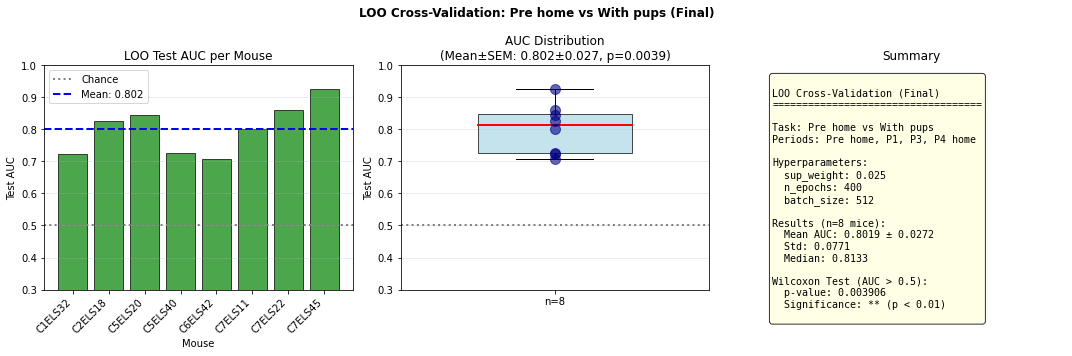


FINAL RESULT

Task: Pre home vs With pups (Stage)
LOO AUC: 0.8019 ± 0.0272 (n=8)
Wilcoxon p-value: 0.003906 ** (p < 0.01)

Figure saved: loo_final_prehome_summary.png


In [35]:
# ================================================================
# LOO Cross-Validation WITHOUT Validation Split (Final)
# Task: Pre home (y=0) vs P1/P3/P4 home (y=1) - has pups
# Parameters determined from validation:
#   sup_weight = 0.02
#   n_epochs = 300
#   batch_size = 256
# data: X_data, y_data, mouse_ids_data
# ================================================================

import numpy as np
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import roc_auc_score
from scipy.stats import wilcoxon
import matplotlib.pyplot as plt
import torch


# ================================================================
# PART 1: Data Loading and Preparation
# ================================================================

TRAINING_DATA_FILE = "/Volumes/rdss_rhultman/datashare/ELS and Maternal Behavior/Spec_Features_1Hz_8roi/combined/full_spec_features_Trim_All.pkl"
X_FEATURE_LIST = ["power", "coh_sq_coherence"]
X_FEATURE_WEIGHTS = [1, 1]
Y_FEATURE = "period"

print("=" * 60)
print("LOADING DATA")
print("=" * 60)

with open(TRAINING_DATA_FILE, "rb") as f:
    train_dict = pickle.load(f)

print("Data loaded successfully!")

# Define filters
periods_to_keep = ['Pre home', 'P1', 'P3', 'P4 home']
target_mouse_ids = ['C7ELS11', 'C2ELS18', 'C5ELS20', 'C7ELS22', 
                   'C1ELS32', 'C5ELS40', 'C6ELS42', 'C7ELS45']

# Clean mouse_id
def clean_mouse_id(mouse_id):
    cleaned = mouse_id.replace('Mouse', '')
    cleaned = re.sub(r'F\d+', '', cleaned)
    return cleaned

cleaned_mouse_ids = np.array([clean_mouse_id(mid) for mid in train_dict['mouse_id']])

# Create filter mask
period_mask = np.isin(train_dict[Y_FEATURE], periods_to_keep)
mouse_mask = np.isin(cleaned_mouse_ids, target_mouse_ids)
combined_mask = period_mask & mouse_mask

print(f"\nFiltered samples: {np.sum(combined_mask)}")

# Filter all arrays
filtered_data = {}
for key in train_dict:
    if isinstance(train_dict[key], np.ndarray) and len(train_dict[key]) == len(train_dict[Y_FEATURE]):
        filtered_data[key] = train_dict[key][combined_mask]

# Update cleaned mouse_ids
filtered_mouse_ids = cleaned_mouse_ids[combined_mask]

# Build X
X_data = np.hstack([filtered_data[feature] * weight for feature, weight in zip(X_FEATURE_LIST, X_FEATURE_WEIGHTS)])

# Build y: Pre home = 0, P1/P3/P4 home = 1
y_binary = np.zeros(len(filtered_data[Y_FEATURE]), dtype=int)
positive_periods = ['P1', 'P3', 'P4 home']
positive_mask = np.isin(filtered_data[Y_FEATURE], positive_periods)
y_binary[positive_mask] = 1
y_data = y_binary.reshape(-1, 1)

mouse_ids_data = filtered_mouse_ids
y_sampling_data = OrdinalEncoder().fit_transform(mouse_ids_data.reshape(-1, 1))

print(f"\n{'='*60}")
print("DATASET STATISTICS")
print(f"{'='*60}")
print(f"X shape: {X_data.shape}")
print(f"y shape: {y_data.shape}")
print(f"Periods: {np.unique(filtered_data[Y_FEATURE])}")
print(f"With pups (y=1): {np.sum(y_data == 1)} ({np.sum(y_data == 1)/len(y_data)*100:.1f}%)")
print(f"Pre home (y=0): {np.sum(y_data == 0)} ({np.sum(y_data == 0)/len(y_data)*100:.1f}%)")
print(f"Unique mice: {np.unique(mouse_ids_data)}")
print(f"Number of mice: {len(np.unique(mouse_ids_data))}")

print("\nPer-mouse breakdown:")
for mouse_id in np.unique(mouse_ids_data):
    mask = mouse_ids_data == mouse_id
    mouse_y = y_data[mask]
    mouse_periods = filtered_data[Y_FEATURE][mask]
    label_0_count = np.sum(mouse_y == 0)
    label_1_count = np.sum(mouse_y == 1)
    unique_periods = np.unique(mouse_periods)
    print(f"  {mouse_id}: with_pups={label_1_count}, pre_home={label_0_count}, periods={unique_periods}")


# ================================================================
# Model and Training Parameters (Determined from Validation)
# ================================================================

model_params = {
    'n_components': 10,
    'dim_in': X_data.shape[1],
    'n_sup_networks': 1,
    'optim_name': "SGD",
    'recon_loss': "MSE",
    'sup_recon_weight': 0.0,
    'sup_weight': 0.03,            # ← from validation 
    'phi_weight': 0,
    'n_intercepts': 1,
    'useDeepEnc': True,
    'h': 128,
    'sup_recon_type': "Residual",
    'feature_groups': None,
    'group_weights': None,
    'fixed_corr': "Positive",
    'momentum': 0.9,
    'sup_smoothness_weight': 1
}

training_params = {
    'n_epochs': 400,               # ← from validation 
    'n_pre_epochs': 100,
    'nmf_max_iter': 500,
    'batch_size': 512,             # ← from validation 
    'lr': 1e-3,
    'pretrain': True,
    'verbose': True,
    'X_val': None,
    'y_val': None,
}

SEED = 2025

# ================================================================
# LOO Cross-Validation
# ================================================================

print(f"{'='*80}")
print("LOO CROSS-VALIDATION WITHOUT VALIDATION SPLIT")
print(f"{'='*80}")
print(f"Task: Pre home (y=0) vs With pups (y=1)")
print(f"Parameters (from validation):")
print(f"  sup_weight: {model_params['sup_weight']}")
print(f"  n_epochs: {training_params['n_epochs']}")
print(f"  batch_size: {training_params['batch_size']}")
print(f"Dataset: {X_data.shape[0]} samples from {len(np.unique(mouse_ids_data))} mice")

unique_mice = np.unique(mouse_ids_data)
results = {}
all_test_aucs = []

for i, test_mouse in enumerate(unique_mice):
    print(f"\n{'='*60}")
    print(f"Fold {i+1}/{len(unique_mice)}: Test mouse = {test_mouse}")
    print(f"{'='*60}")
    
    # Split data
    test_mask = mouse_ids_data == test_mouse
    train_mask = ~test_mask
    
    X_train = X_data[train_mask]
    y_train = y_data[train_mask]
    mouse_ids_train = mouse_ids_data[train_mask]
    
    X_test = X_data[test_mask]
    y_test = y_data[test_mask]
    
    print(f"Train: {X_train.shape[0]} samples (with_pups={np.sum(y_train == 1)}, pre_home={np.sum(y_train == 0)})")
    print(f"Test: {X_test.shape[0]} samples (with_pups={np.sum(y_test == 1)}, pre_home={np.sum(y_test == 0)})")
    
    # Check test set
    if len(np.unique(y_test)) <= 1:
        print(f"⚠ Skipping mouse {test_mouse} - only one class in test set")
        results[test_mouse] = {'test_auc': None, 'test_samples': X_test.shape[0],
            'test_with_pups': int(np.sum(y_test == 1)), 'test_pre_home': int(np.sum(y_test == 0)), 
            'skip_reason': 'single_class'}
        continue
    
    # Re-encode y_sampling
    y_sampling_train = OrdinalEncoder().fit_transform(mouse_ids_train.reshape(-1, 1))
    
    # Set random seed
    fold_seed = SEED + i
    random.seed(fold_seed)
    np.random.seed(fold_seed)
    torch.manual_seed(fold_seed)
    torch.cuda.manual_seed_all(fold_seed)
    
    # Create and train model
    model = dCSFA_NMF(**model_params)
    
    print(f"Training model...")
    model.fit(X_train, y_train, y_sample_groups=y_sampling_train.squeeze(),
             y_pred_weights=None, intercept_mask=None, task_mask=None, **training_params)
    
    # Test
    model.eval()
    y_pred_proba, s_test = model.predict_proba(X_test, include_scores=True)
    test_auc = roc_auc_score(y_test, y_pred_proba)
    all_test_aucs.append(test_auc)
    
    print(f"✓ Test AUC: {test_auc:.4f}")
    print(f"  φ (actual): {model.get_phi(0).item():.4f}, β: {model.beta_list[0].item():.4f}")
    
    results[test_mouse] = {
        'test_auc': test_auc, 'test_samples': X_test.shape[0],
        'test_with_pups': int(np.sum(y_test == 1)), 'test_pre_home': int(np.sum(y_test == 0)),
        'phi_value': model.get_phi(0).item(), 'beta_value': model.beta_list[0].item()
    }

# ================================================================
# Results Summary
# ================================================================

individual_aucs = np.array(all_test_aucs)
n_mice = len(individual_aucs)

print(f"\n{'='*80}")
print("LOO CROSS-VALIDATION RESULTS")
print(f"{'='*80}")

print(f"\nPer-mouse Test AUC:")
print(f"{'Mouse':<12} {'AUC':<10} {'Samples':<10} {'WithPups':<10} {'PreHome':<10} {'φ':<10}")
print("-" * 62)
for mouse, result in sorted(results.items()):
    if result['test_auc'] is not None:
        print(f"{mouse:<12} {result['test_auc']:<10.4f} {result['test_samples']:<10} "
              f"{result['test_with_pups']:<10} {result['test_pre_home']:<10} {result['phi_value']:<10.4f}")
    else:
        print(f"{mouse:<12} {'SKIPPED':<10} {result['test_samples']:<10} "
              f"{result['test_with_pups']:<10} {result['test_pre_home']:<10} {'N/A':<10}")

mean_auc = individual_aucs.mean()
std_auc = individual_aucs.std(ddof=1)
sem_auc = std_auc / np.sqrt(n_mice)
median_auc = np.median(individual_aucs)

print(f"\nSummary Statistics:")
print(f"  Individual AUCs: {individual_aucs}")
print(f"  Mean AUC: {mean_auc:.4f} ± {sem_auc:.4f} (SEM)")
print(f"  Std: {std_auc:.4f}")
print(f"  Median: {median_auc:.4f}")
print(f"  Range: [{individual_aucs.min():.4f}, {individual_aucs.max():.4f}]")

# ================================================================
# Wilcoxon Test
# ================================================================

print(f"\n{'='*80}")
print("WILCOXON SIGNED-RANK TEST")
print(f"{'='*80}")

differences = individual_aucs - 0.5
statistic, p_value = wilcoxon(differences, alternative='greater')

print(f"\nDifferences from chance (0.5): {differences}")
print(f"\nWilcoxon Signed-Rank Test (one-sided): H1: AUC > 0.5")
print(f"Test Statistic: {statistic}")
print(f"P-value: {p_value:.6f}")

if p_value < 0.001: significance = "*** (p < 0.001)"
elif p_value < 0.01: significance = "** (p < 0.01)"
elif p_value < 0.05: significance = "* (p < 0.05)"
else: significance = "ns (not significant)"

print(f"Significance: {significance}")
print(f"Mice with AUC > 0.5: {np.sum(individual_aucs > 0.5)}/{n_mice}")

# ================================================================
# Summary Figure
# ================================================================

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

mice_names = [m for m in results.keys() if results[m]['test_auc'] is not None]
mice_aucs = [results[m]['test_auc'] for m in mice_names]
colors = ['green' if auc > 0.5 else 'red' for auc in mice_aucs]

axes[0].bar(range(len(mice_names)), mice_aucs, color=colors, edgecolor='black', alpha=0.7)
axes[0].axhline(y=0.5, color='gray', linestyle=':', linewidth=2, label='Chance')
axes[0].axhline(y=mean_auc, color='blue', linestyle='--', linewidth=2, label=f'Mean: {mean_auc:.3f}')
axes[0].set_xticks(range(len(mice_names)))
axes[0].set_xticklabels(mice_names, rotation=45, ha='right')
axes[0].set_xlabel('Mouse'); axes[0].set_ylabel('Test AUC'); axes[0].set_title('LOO Test AUC per Mouse')
axes[0].legend(); axes[0].grid(alpha=0.3, axis='y'); axes[0].set_ylim([0.3, 1.0])

axes[1].boxplot([individual_aucs], widths=0.5, patch_artist=True,
               boxprops=dict(facecolor='lightblue', alpha=0.7), medianprops=dict(color='red', linewidth=2))
axes[1].scatter(np.ones(n_mice), individual_aucs, alpha=0.6, s=100, color='navy', zorder=3)
axes[1].axhline(y=0.5, color='gray', linestyle=':', linewidth=2)
axes[1].set_ylabel('Test AUC')
axes[1].set_title(f'AUC Distribution\n(Mean±SEM: {mean_auc:.3f}±{sem_auc:.3f}, p={p_value:.4f})')
axes[1].set_xticks([1]); axes[1].set_xticklabels([f'n={n_mice}']); axes[1].set_ylim([0.3, 1.0]); axes[1].grid(alpha=0.3, axis='y')

summary_text = f"""
LOO Cross-Validation (Final)
{'='*35}

Task: Pre home vs With pups
Periods: Pre home, P1, P3, P4 home

Hyperparameters:
  sup_weight: {model_params['sup_weight']}
  n_epochs: {training_params['n_epochs']}
  batch_size: {training_params['batch_size']}

Results (n={n_mice} mice):
  Mean AUC: {mean_auc:.4f} ± {sem_auc:.4f}
  Std: {std_auc:.4f}
  Median: {median_auc:.4f}

Wilcoxon Test (AUC > 0.5):
  p-value: {p_value:.6f}
  Significance: {significance}
"""
axes[2].text(0.05, 0.95, summary_text, transform=axes[2].transAxes, fontsize=10,
            verticalalignment='top', fontfamily='monospace',
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
axes[2].set_title('Summary'); axes[2].axis('off')

plt.suptitle('LOO Cross-Validation: Pre home vs With pups (Final)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('loo_final_prehome_summary.png', dpi=300, bbox_inches='tight')
plt.show()

# ================================================================
# Final Output
# ================================================================

print(f"\n{'='*80}")
print("FINAL RESULT")
print(f"{'='*80}")
print(f"\nTask: Pre home vs With pups (Stage)")
print(f"LOO AUC: {mean_auc:.4f} ± {sem_auc:.4f} (n={n_mice})")
print(f"Wilcoxon p-value: {p_value:.6f} {significance}")
print(f"\nFigure saved: loo_final_prehome_summary.png")
print(f"{'='*80}")

# Complete training and evaluation

In [4]:
import numpy as np
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import roc_auc_score
from scipy.stats import wilcoxon
import matplotlib.pyplot as plt
import torch


# ================================================================
# PART 1: Data Loading and Preparation
# ================================================================

TRAINING_DATA_FILE = "/Volumes/rdss_rhultman/datashare/ELS and Maternal Behavior/Spec_Features_1Hz_8roi/combined/full_spec_features_Trim_All.pkl"
X_FEATURE_LIST = ["power", "coh_sq_coherence"]
X_FEATURE_WEIGHTS = [1, 1]
Y_FEATURE = "period"

print("=" * 60)
print("LOADING DATA")
print("=" * 60)

with open(TRAINING_DATA_FILE, "rb") as f:
    train_dict = pickle.load(f)

print("Data loaded successfully!")

LOADING DATA
Data loaded successfully!


In [11]:
import numpy as np
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
import re
import pandas as pd

# ID
periods_to_keep = ['Pre home', 'P1', 'P3', 'P4 home']
target_mouse_ids = ['C7ELS11', 'C2ELS18', 'C5ELS20', 'C7ELS22', 
                   'C1ELS32', 'C5ELS40', 'C6ELS42', 'C7ELS45']

# mouse_id，"Mouse""FX"
def clean_mouse_id(mouse_id):
    cleaned = mouse_id.replace('Mouse', '')
    cleaned = re.sub(r'F\d+', '', cleaned)
    return cleaned

# hasmouse_id
cleaned_mouse_ids = np.array([clean_mouse_id(mid) for mid in train_dict['mouse_id']])

# Build 
period_mask = np.isin(train_dict[Y_FEATURE], periods_to_keep)
mouse_mask = np.isin(cleaned_mouse_ids, target_mouse_ids)
combined_mask = period_mask & mouse_mask

print(f"n_samples: {np.sum(combined_mask)}")

# hasgroup
filtered_data = {}
for key in train_dict:
    if isinstance(train_dict[key], np.ndarray) and len(train_dict[key]) == len(train_dict[Y_FEATURE]):
        filtered_data[key] = train_dict[key][combined_mask]

# updatedmouse_id
filtered_mouse_ids = cleaned_mouse_ids[combined_mask]

print(f"Unique periods after filter: {np.unique(filtered_data[Y_FEATURE])}")
print(f"Unique mouse IDs after filter: {np.unique(filtered_mouse_ids)}")



# Build Train Cdataset（hasdataTrain set）
def create_train_c_dataset():
    # X
    X_train_c = np.hstack([filtered_data[feature]*weight for feature, weight in zip(X_FEATURE_LIST, X_FEATURE_WEIGHTS)])
    
    #  value: Pre home = 0, P1/P3/P4 home = 1
    y_binary = np.zeros(len(filtered_data[Y_FEATURE]), dtype=int)
    positive_periods = ['P1', 'P3', 'P4 home']
    positive_mask = np.isin(filtered_data[Y_FEATURE], positive_periods)
    y_binary[positive_mask] = 1
    
    y_train_c = y_binary.reshape(-1, 1)
    
    # intercept（mouse_id）
    y_intercept_train_c = filtered_mouse_ids
    
    # Build 
    ordinal_encoder = OrdinalEncoder()
    y_sampling_train_c = ordinal_encoder.fit_transform(y_intercept_train_c.reshape(-1, 1))
    
    onehot_encoder = OneHotEncoder()
    y_intercept_mask_train_c = onehot_encoder.fit_transform(y_intercept_train_c.reshape(-1, 1)).todense()
    
    train_c_dataset = {
        'X_train_c': X_train_c,
        'y_train_c': y_train_c,
        'y_intercept_train_c': y_intercept_train_c,
        'y_sampling_train_c': y_sampling_train_c,
        'y_intercept_mask_train_c': y_intercept_mask_train_c,
        'train_c_periods': filtered_data[Y_FEATURE],
        'train_c_intercept_dim': y_intercept_mask_train_c.shape[1],
        'train_c_mouse_list': np.unique(filtered_mouse_ids)
    }
    
    return train_c_dataset

# Build Train Cdataset
train_c_dataset = create_train_c_dataset()

print(f"\n" + "="*80)
print("TRAIN C DATASET CREATED")
print("="*80)
print(f"Train C shape: X={train_c_dataset['X_train_c'].shape}, y={train_c_dataset['y_train_c'].shape}")
print(f"Train C intercept dimension: {train_c_dataset['train_c_intercept_dim']}")
print(f"Train C mice: {train_c_dataset['train_c_mouse_list']}")
print("Note: P4 home data limited to first 20 minutes (≤400 windows) per mouse")

# updated
print(f"\n (P4 home):")
print(f"Pre home samples (=0): {np.sum(train_c_dataset['y_train_c'] == 0)}")
print(f"Early postnatal samples (P1/P3/P4 home, =1): {np.sum(train_c_dataset['y_train_c'] == 1)}")

# 
print(f"\n (P4 home):")
for period in periods_to_keep:
    period_mask = filtered_data[Y_FEATURE] == period
    count = np.sum(period_mask)
    if period == 'Pre home':
        label = 0
        label_desc = "=0"
    else:
        label = 1
        label_desc = "=1"
    period_note = " (≤400 windows per mouse)" if period == 'P4 home' else ""
    print(f"{period}: {count}  ({label_desc}){period_note}")

# verify valueis
print(f"\nverify:")
print(f"Total samples: {len(train_c_dataset['y_train_c'])}")
print(f"0 sample count: {np.sum(train_c_dataset['y_train_c'] == 0)}")
print(f"1 sample count: {np.sum(train_c_dataset['y_train_c'] == 1)}")
print(f"Label distribution: {np.sum(train_c_dataset['y_train_c'] == 0) / len(train_c_dataset['y_train_c']):.2%} (0) vs "
      f"{np.sum(train_c_dataset['y_train_c'] == 1) / len(train_c_dataset['y_train_c']):.2%} (1)")

# P4 homeTrain setTotal samples
p4_home_total = np.sum(filtered_data[Y_FEATURE] == 'P4 home')
n_mice_with_p4 = len([m for m in target_mouse_ids if np.sum((filtered_mouse_ids == m) & (filtered_data[Y_FEATURE] == 'P4 home')) > 0])
print(f"\nP4 homeTotal samples: {p4_home_total} ({n_mice_with_p4}，≤400 )")

print("="*80)

初始过滤后样本数: 65600
过滤后的唯一期间: ['P1' 'P3' 'P4 home' 'Pre home']
过滤后的唯一小鼠ID: ['C1ELS32' 'C2ELS18' 'C5ELS20' 'C5ELS40' 'C6ELS42' 'C7ELS11' 'C7ELS22'
 'C7ELS45']

TRAIN C DATASET CREATED
Train C shape: X=(65600, 1944), y=(65600, 1)
Train C intercept dimension: 8
Train C mice: ['C1ELS32' 'C2ELS18' 'C5ELS20' 'C5ELS40' 'C6ELS42' 'C7ELS11' 'C7ELS22'
 'C7ELS45']
Note: P4 home data limited to first 20 minutes (≤400 windows) per mouse

标签统计 (P4 home限制后):
Pre home samples (标签=0): 1600
Early postnatal samples (P1/P3/P4 home, 标签=1): 64000

各期间的样本分布 (P4 home限制后):
Pre home: 1600个样本 (标签=0)
P1: 33600个样本 (标签=1)
P3: 28800个样本 (标签=1)
P4 home: 1600个样本 (标签=1) (≤400 windows per mouse)

标签验证:
总样本数: 65600
标签为0的样本数: 1600
标签为1的样本数: 64000
标签分布: 2.44% (标签0) vs 97.56% (标签1)

P4 home总样本数: 1600 (来自4只小鼠，每只≤400个窗口)



DATA PREPARED FOR MODEL TRAINING
X_data shape: (65600, 1944)
y_data shape: (65600, 1)
mouse_ids_data shape: (65600,)
Unique mice: ['C1ELS32' 'C2ELS18' 'C5ELS20' 'C5ELS40' 'C6ELS42' 'C7ELS11' 'C7ELS22'
 'C7ELS45']
FINAL MODEL TRAINING ON ALL C DATA

Task: Pre home (y=0) vs With pups (y=1)
Periods: Pre home, P1, P3, P4 home

Hyperparameters (from LOO-CV):
  sup_weight: 0.03
  n_epochs: 400
  batch_size: 512

Training Data:
  X shape: (65600, 1944)
  y shape: (65600, 1)
  With pups (y=1): 64000 (97.6%)
  Pre home (y=0): 1600 (2.4%)
  Mice: ['C1ELS32' 'C2ELS18' 'C5ELS20' 'C5ELS40' 'C6ELS42' 'C7ELS11' 'C7ELS22'
 'C7ELS45']

Model version: 1.3

Training model...
Pretraining....
Pretraining NMF...


/opt/anaconda3/lib/python3.8/site-packages/sklearn/decomposition/_nmf.py:289: FutureWarning: The 'init' value, when 'init=None' and n_components is less than n_samples and n_features, will be changed from 'nndsvd' to 'nndsvda' in 1.1 (renaming of 0.26).
  warnings.warn(
/opt/anaconda3/lib/python3.8/site-packages/sklearn/decomposition/_nmf.py:1637: ConvergenceWarning: Maximum number of iterations 500 reached. Increase it to improve convergence.
  warnings.warn(


Identifying predictive components for network 0


100%|███████████████████████████████████████████| 10/10 [00:00<00:00, 23.71it/s]


Selecting network: 1 with auc 0.653401806640625 for sup net 0 using constraint positive correlation


Pretrain Epoch: 99, Recon Loss: 5.31: 100%|███| 100/100 [02:59<00:00,  1.80s/it]


Pretraining Complete
Beginning Training


Epoch: 399, Loss: 0.0355, Recon: 0.0309, AUC: 0.648: 100%|█| 400/400 [24:33<00:0



Saving model...
  Full model saved to: Maternal_model_TrainC_Pre_P134_1Hz_ver2.pt
  State dict saved to: Maternal_sd_TrainC_Pre_P134_1Hz_ver2.pt

Plotting training history...


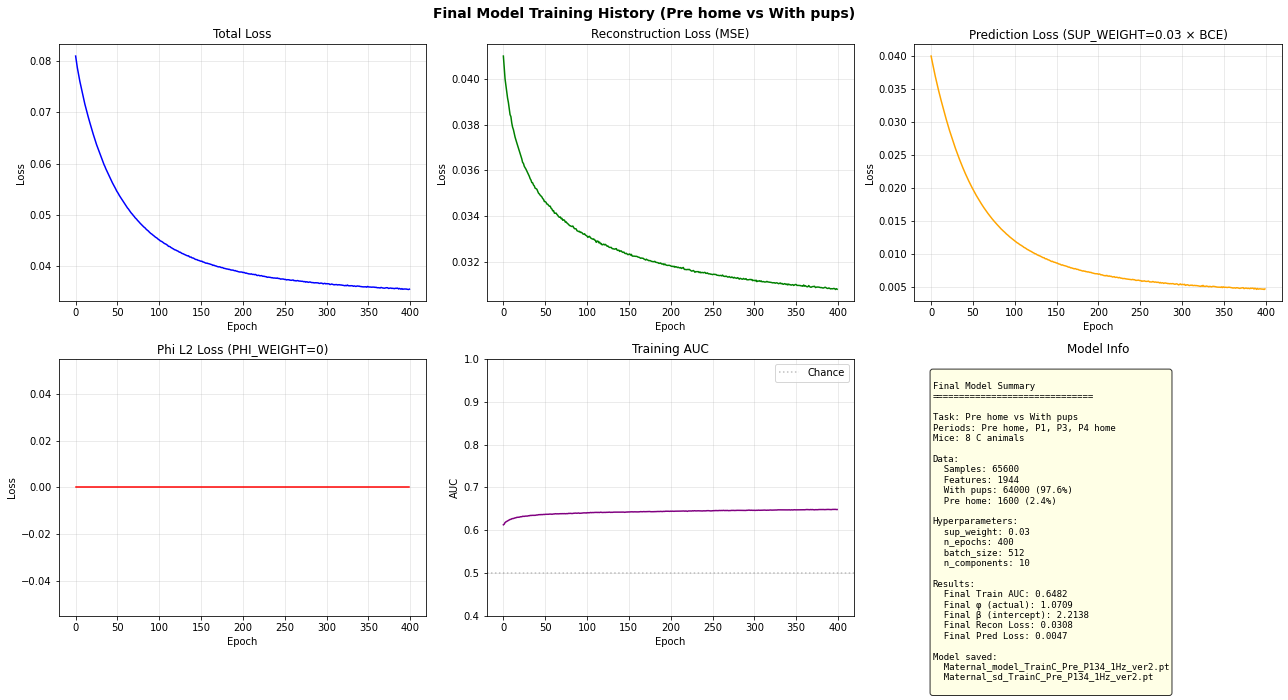


TRAINING COMPLETE

Final Model Parameters:
  φ (actual, after Softplus): 1.0709
  φ (raw parameter): 0.6513
  β (intercept): 2.2138

Final Training Metrics:
  Total Loss: 0.0355
  Recon Loss: 0.0308
  Pred Loss:  0.0047
  Train AUC:  0.6482

Model saved to:
  Full model: Maternal_model_TrainC_Pre_P134_1Hz_ver2.pt
  State dict: Maternal_sd_TrainC_Pre_P134_1Hz_ver2.pt

Figure saved: final_model_prehome_training_history.png



In [12]:
# ================================================================
# Final Model Training on All C Data
# Task: Pre home (y=0) vs P1/P3/P4 home (y=1) - has pups
# Parameters from LOO validation:
#   sup_weight = 0.025
#   n_epochs = 400
#   batch_size = 512
# data: X_data, y_data, mouse_ids_data
# ================================================================

import numpy as np
import matplotlib.pyplot as plt
import torch
import random

# ================================================================
# Extract data for model training
# ================================================================

X_data = train_c_dataset['X_train_c']
y_data = train_c_dataset['y_train_c']
mouse_ids_data = train_c_dataset['y_intercept_train_c']

print(f"\n" + "="*80)
print("DATA PREPARED FOR MODEL TRAINING")
print("="*80)
print(f"X_data shape: {X_data.shape}")
print(f"y_data shape: {y_data.shape}")
print(f"mouse_ids_data shape: {mouse_ids_data.shape}")
print(f"Unique mice: {np.unique(mouse_ids_data)}")
print("="*80)


# ================================================================
# Model Save Files
# ================================================================

MODEL_SAVE_FILE = "Maternal_model_TrainC_Pre_P134_1Hz_ver2.pt"
MODEL_STATE_DICT = "Maternal_sd_TrainC_Pre_P134_1Hz_ver2.pt"

# ================================================================
# Model and Training Parameters (from LOO validation)
# ================================================================

model_params = {
    'n_components': 10,
    'dim_in': X_data.shape[1],
    'n_sup_networks': 1,
    'optim_name': "SGD",
    'recon_loss': "MSE",
    'sup_recon_weight': 0.0,
    'sup_weight': 0.03,           # ← from LOO validation 
    'phi_weight': 0,
    'n_intercepts': 1,
    'useDeepEnc': True,
    'h': 128,
    'sup_recon_type': "Residual",
    'feature_groups': None,
    'group_weights': None,
    'fixed_corr': "Positive",
    'momentum': 0.9,
    'sup_smoothness_weight': 1
}

N_EPOCHS = 400                     # ← from LOO validation 
N_PRE_EPOCHS = 100
NMF_MAX_ITER = 500
BATCH_SIZE = 512                   # ← from LOO validation 
LR = 1e-3
SEED = 2025

# ================================================================
# Set Random Seed and Train
# ================================================================
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

print("=" * 80)
print("FINAL MODEL TRAINING ON ALL C DATA")
print("=" * 80)

print(f"\nTask: Pre home (y=0) vs With pups (y=1)")
print(f"Periods: Pre home, P1, P3, P4 home")

print(f"\nHyperparameters (from LOO-CV):")
print(f"  sup_weight: {model_params['sup_weight']}")
print(f"  n_epochs: {N_EPOCHS}")
print(f"  batch_size: {BATCH_SIZE}")

print(f"\nTraining Data:")
print(f"  X shape: {X_data.shape}")
print(f"  y shape: {y_data.shape}")
print(f"  With pups (y=1): {np.sum(y_data == 1)} ({np.sum(y_data == 1)/len(y_data)*100:.1f}%)")
print(f"  Pre home (y=0): {np.sum(y_data == 0)} ({np.sum(y_data == 0)/len(y_data)*100:.1f}%)")
print(f"  Mice: {np.unique(mouse_ids_data)}")

# Create model
model = dCSFA_NMF(**model_params)
print(f"\nModel version: {model.__version__}")

# Prepare y_sampling
from sklearn.preprocessing import OrdinalEncoder
y_sampling_train = OrdinalEncoder().fit_transform(mouse_ids_data.reshape(-1, 1))

# Train
print("\nTraining model...")
model.fit(
    X_data,
    y_data,
    y_sample_groups=y_sampling_train.squeeze(),
    y_pred_weights=None,
    intercept_mask=None,
    task_mask=None,
    n_epochs=N_EPOCHS,
    n_pre_epochs=N_PRE_EPOCHS,
    nmf_max_iter=NMF_MAX_ITER,
    batch_size=BATCH_SIZE,
    lr=LR,
    pretrain=True,
    verbose=True,
    X_val=None,
    y_val=None
)

# ================================================================
# Save Model
# ================================================================

print("\nSaving model...")
torch.save(model, MODEL_SAVE_FILE)
torch.save(model.state_dict(), MODEL_STATE_DICT)
print(f"  Full model saved to: {MODEL_SAVE_FILE}")
print(f"  State dict saved to: {MODEL_STATE_DICT}")

# ================================================================
# Plot Training History
# ================================================================

print("\nPlotting training history...")

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Total Loss
axes[0, 0].plot(model.train_total_hist, color='blue', linewidth=1.5)
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Total Loss')
axes[0, 0].grid(alpha=0.3)

# 2. Reconstruction Loss
axes[0, 1].plot(model.train_recon_hist, color='green', linewidth=1.5)
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].set_title('Reconstruction Loss (MSE)')
axes[0, 1].grid(alpha=0.3)

# 3. Prediction Loss
axes[0, 2].plot(model.train_pred_hist, color='orange', linewidth=1.5)
axes[0, 2].set_xlabel('Epoch')
axes[0, 2].set_ylabel('Loss')
axes[0, 2].set_title(f'Prediction Loss (SUP_WEIGHT={model_params["sup_weight"]} × BCE)')
axes[0, 2].grid(alpha=0.3)

# 4. Phi L2 Loss
axes[1, 0].plot(model.train_phi_loss_hist, color='red', linewidth=1.5)
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Loss')
axes[1, 0].set_title(f'Phi L2 Loss (PHI_WEIGHT={model_params["phi_weight"]})')
axes[1, 0].grid(alpha=0.3)

# 5. Training AUC
train_aucs = [auc[0] for auc in model.train_auc_hist]
axes[1, 1].plot(train_aucs, color='purple', linewidth=1.5)
axes[1, 1].axhline(y=0.5, color='gray', linestyle=':', alpha=0.5, label='Chance')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('AUC')
axes[1, 1].set_title('Training AUC')
axes[1, 1].set_ylim([0.4, 1.0])
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

# 6. Model Info
info_text = f"""
Final Model Summary
{'='*30}

Task: Pre home vs With pups
Periods: Pre home, P1, P3, P4 home
Mice: {len(np.unique(mouse_ids_data))} C animals

Data:
  Samples: {X_data.shape[0]}
  Features: {X_data.shape[1]}
  With pups: {np.sum(y_data == 1)} ({np.sum(y_data == 1)/len(y_data)*100:.1f}%)
  Pre home: {np.sum(y_data == 0)} ({np.sum(y_data == 0)/len(y_data)*100:.1f}%)

Hyperparameters:
  sup_weight: {model_params['sup_weight']}
  n_epochs: {N_EPOCHS}
  batch_size: {BATCH_SIZE}
  n_components: {model_params['n_components']}

Results:
  Final Train AUC: {train_aucs[-1]:.4f}
  Final φ (actual): {model.get_phi(0).item():.4f}
  Final β (intercept): {model.beta_list[0].item():.4f}
  Final Recon Loss: {model.train_recon_hist[-1]:.4f}
  Final Pred Loss: {model.train_pred_hist[-1]:.4f}

Model saved:
  {MODEL_SAVE_FILE}
  {MODEL_STATE_DICT}
"""

axes[1, 2].text(0.05, 0.95, info_text, transform=axes[1, 2].transAxes,
               fontsize=9, verticalalignment='top', fontfamily='monospace',
               bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
axes[1, 2].set_title('Model Info')
axes[1, 2].axis('off')

plt.suptitle('Final Model Training History (Pre home vs With pups)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('final_model_prehome_training_history.png', dpi=300, bbox_inches='tight')
plt.show()

# ================================================================
# Final Summary
# ================================================================

print("\n" + "=" * 80)
print("TRAINING COMPLETE")
print("=" * 80)

print(f"\nFinal Model Parameters:")
print(f"  φ (actual, after Softplus): {model.get_phi(0).item():.4f}")
print(f"  φ (raw parameter): {model.phi_list[0].item():.4f}")
print(f"  β (intercept): {model.beta_list[0].item():.4f}")

print(f"\nFinal Training Metrics:")
print(f"  Total Loss: {model.train_total_hist[-1]:.4f}")
print(f"  Recon Loss: {model.train_recon_hist[-1]:.4f}")
print(f"  Pred Loss:  {model.train_pred_hist[-1]:.4f}")
print(f"  Train AUC:  {train_aucs[-1]:.4f}")

print(f"\nModel saved to:")
print(f"  Full model: {MODEL_SAVE_FILE}")
print(f"  State dict: {MODEL_STATE_DICT}")

print(f"\nFigure saved: final_model_prehome_training_history.png")

print("\n" + "=" * 80)

Phi value: Parameter containing:
tensor([0.6513], requires_grad=True)
Selected DataFrame (df_selected):
           (2, 3)  (3, 4)  (4, 5)  (5, 6)  (6, 7)  (7, 8)  (8, 9)  (9, 10)  \
BLA           NaN     NaN     NaN     NaN     NaN     NaN     NaN      NaN   
CeA           NaN     NaN     NaN     NaN     NaN     NaN     NaN      NaN   
IL            NaN     NaN     NaN     NaN     NaN     NaN     NaN      NaN   
MeA         0.994   1.085   0.997   0.981   0.969   0.962   0.964    0.843   
NAc           NaN     NaN     NaN     NaN     NaN     NaN     NaN      NaN   
PrL           NaN     NaN     NaN     NaN     NaN     NaN     NaN      NaN   
VHipp       1.062   1.109   1.079   1.095   1.141   1.196   1.140    1.042   
VTA           NaN     NaN     NaN     NaN     NaN     NaN     NaN      NaN   
BLA-CeA       NaN   0.867   0.844   0.877   0.901   0.932   0.988    0.944   
BLA-IL        NaN     NaN     NaN     NaN     NaN     NaN     NaN      NaN   
BLA-MeA     1.266   1.419   1.362   1.


文件已保存: selected_data.csv 和 selected_data.xlsx


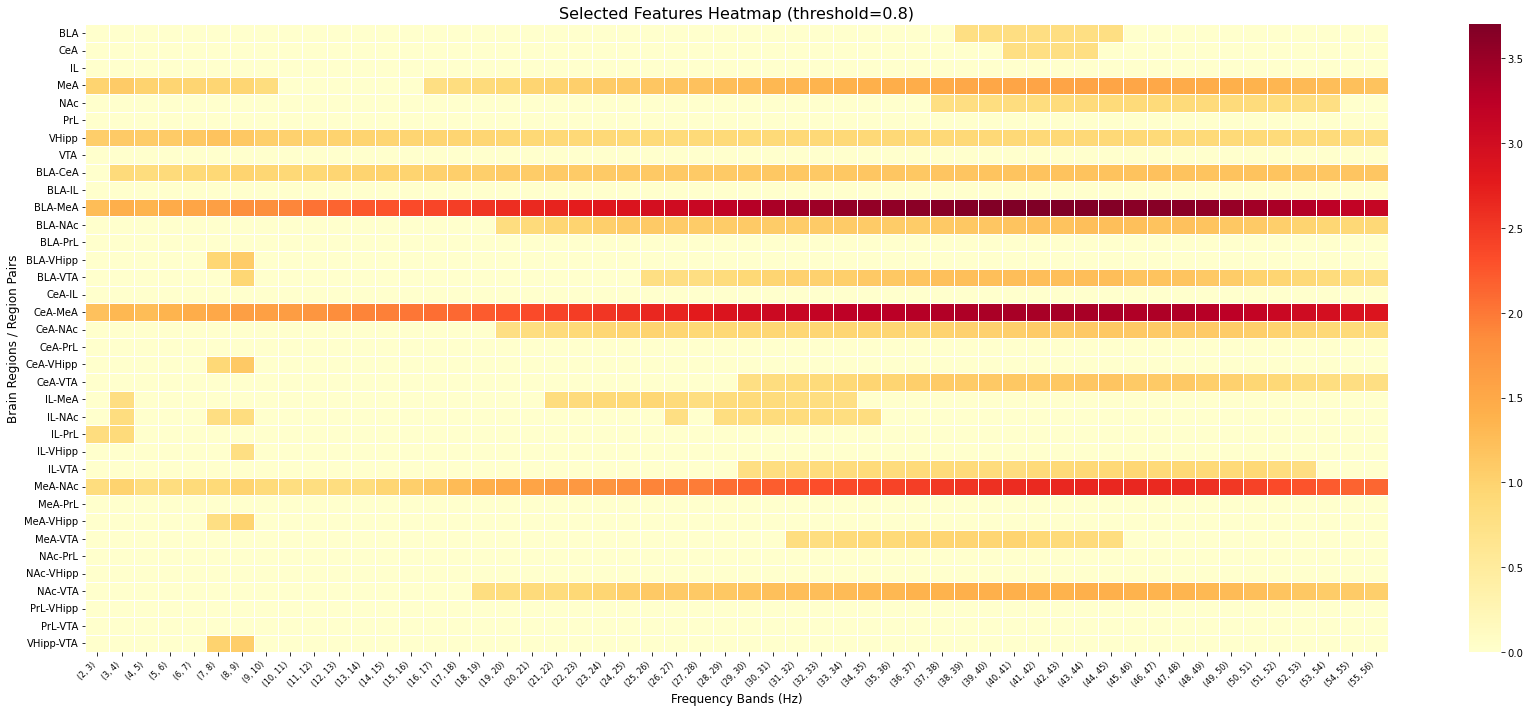

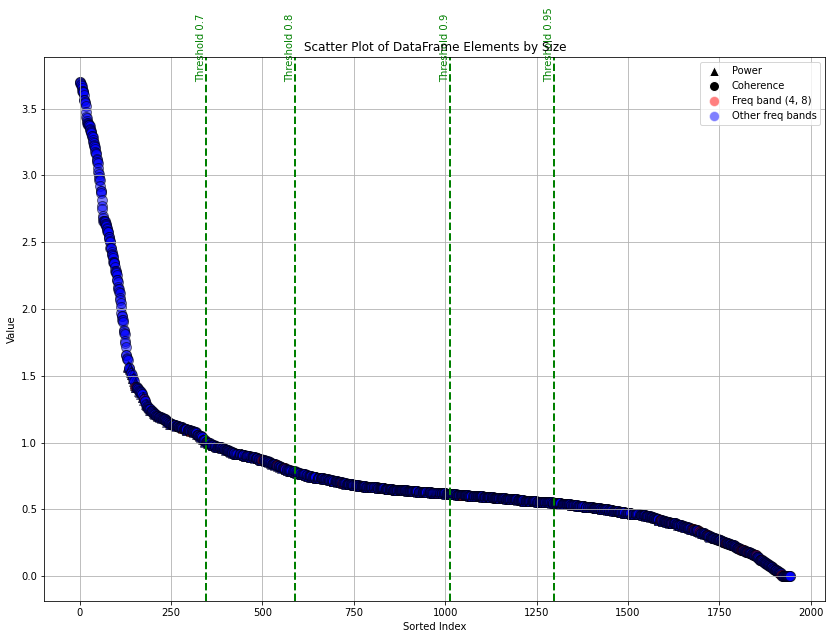

In [13]:
model = torch.load(MODEL_SAVE_FILE, map_location='cpu')
model.device = 'cpu'
model.eval()  # set
print(f"Phi value: {model.phi_list[0]}")

# =====  1: set pandas  =====
pd.set_option('display.max_columns', None)  # has
pd.set_option('display.width', None)  # 
pd.set_option('display.max_rows', None)  # has rows
pd.set_option('display.float_format', lambda x: '%.3f' % x)

# W_nmf
df, df_select = process_W_nmf_k(model.get_W_nmf(), train_dict, threshold_ratio=0.8, k=0)

# =====  2: saved tofile =====
df_select.to_csv('selected_data.csv')
df_select.to_excel('selected_data.xlsx')
print("\nfilesaved: selected_data.csv  selected_data.xlsx")

# =====  3:  =====
import seaborn as sns

plt.figure(figsize=(24, 10))
sns.heatmap(df_select.fillna(0), cmap='YlOrRd', annot=False, cbar=True, 
            xticklabels=True, yticklabels=True, linewidths=0.5)
plt.title('Selected Features Heatmap (threshold=0.8)', fontsize=16)
plt.xlabel('Frequency Bands (Hz)', fontsize=12)
plt.ylabel('Brain Regions / Region Pairs', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.savefig('selected_features_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

# has
flattened_values = df.values.flatten()
sorted_indices = np.argsort(flattened_values)[::-1]  
sorted_values = flattened_values[sorted_indices]
original_positions = np.unravel_index(sorted_indices, df.shape)
shapes = np.array(['^' if i < 8 else 'o' for i in original_positions[0]])  
colors = np.array(['r' if j == 1 else 'b' for j in original_positions[1]])  
squared_values = df.values ** 2
flattened_squared_values = squared_values.flatten()
total_l2_square = np.sum(flattened_squared_values)
sorted_squared_values = flattened_squared_values[sorted_indices]
cumulative_sum = np.cumsum(sorted_squared_values)
thresholds = [0.7, 0.8, 0.9, 0.95]
threshold_indices = [np.argmax(cumulative_sum >= t * total_l2_square) for t in thresholds]

plt.figure(figsize=(14, 10))
for i in range(len(sorted_values)):
    plt.scatter(i, sorted_values[i], alpha=0.5, color=colors[i], marker=shapes[i], edgecolors='black', s=100)
for idx, threshold in zip(threshold_indices, thresholds):
    plt.axvline(x=idx, color='green', linestyle='--', linewidth=2)
    plt.text(idx, max(sorted_values), f'Threshold {threshold}', rotation=90, verticalalignment='bottom', horizontalalignment='right', color='green')
legend_elements = [
    Line2D([0], [0], marker='^', color='w', label='Power', markerfacecolor='black', markersize=10),
    Line2D([0], [0], marker='o', color='w', label='Coherence', markerfacecolor='black', markersize=10),
    Line2D([0], [0], marker='o', color='w', label='Freq band (4, 8)', markerfacecolor='r', markersize=10, alpha=0.5),
    Line2D([0], [0], marker='o', color='w', label='Other freq bands', markerfacecolor='b', markersize=10, alpha=0.5)
]
plt.legend(handles=legend_elements, loc='upper right')
plt.title('Scatter Plot of DataFrame Elements by Size')
plt.xlabel('Sorted Index')
plt.ylabel('Value')
plt.grid(True)
plt.show()

### Circos Plot

# change circos plot Jan 1

In [11]:
# import pickle
# import scipy.io
# import numpy as np
# import pandas as pd
# import torch

# # ============================================
# # 1. datagenerate AreaNames.mat
# # ============================================

# TRAINING_DATA_FILE = "/Volumes/rdss_rhultman/datashare/ELS and Maternal Behavior/Spec_Features_8Yes/combined/full_onnest_spec_features_8roi_Jan212026_Trim.pkl"

# with open(TRAINING_DATA_FILE, "rb") as f:
#     train_dict = pickle.load(f)
    
# rows_power = train_dict["region"][:8]
# print(rows_power)

# # 
# print(f"\nfreq_band: {train_dict['freq_band']}")
# print(f"freq_band: {len(train_dict['freq_band'])}")

# # numpygroup
# area_names = np.array(rows_power, dtype=object).reshape(-1, 1)

# # dataas dict
# data = {'AreaNames': area_names}

# # Save as AreaNames.mat filetotarget path
# scipy.io.savemat('/Users/yilinwang/Library/CloudStorage/OneDrive-UniversityofIowa/intern/Fw_ more on computational neuroscience collaboration/CircosScripts/bin/AreaNames_maternal.mat', data)

# # ============================================
# # 2. 
# # ============================================

# MODEL_SAVE_FILE = "Maternal_model_TrainC_Pre_P134_1Hz_ver2.pt"

# model = torch.load(MODEL_SAVE_FILE, map_location='cpu')
# model.device = 'cpu'

# # ============================================
# # 3. generate NormalizedCrossSpectra.mat
# # ============================================

# #  W_nmf data: [10, 1944] (10 components × 36 features × 54 freqs)
# W_nmf_data = model.get_W_nmf()
# print(f"\nW_nmfshape: {W_nmf_data.shape}")

# # 1. datafrom
# W_nmf_complex = W_nmf_data + 1j * 0

# # 2. torch tensor  numpy array
# W_nmf_np = W_nmf_complex.detach().numpy()

# # 3. shape：1944 element 36×54 
# # 36 = 8 power + 28 coherence
# # 54 = 54  (2-3 Hz, 3-4 Hz, ..., 55-56 Hz)
# W_nmf_reshaped = W_nmf_np.reshape(10, 36, 54)
# print(f"W_nmfshape: {W_nmf_reshaped.shape}")

# # 4. 54 
# expanded_data = W_nmf_reshaped  # shape: (10, 36, 54)

# # 5. 
# transposed_data = np.transpose(expanded_data, (0, 2, 1))  # shape: (10, 54, 36)

# # 6. expand and rewrite 3rd dim: 36 -> 8×8
# # 8 is(power), 28 is(coherence)
# final_data = np.zeros((10, 54, 8, 8), dtype=complex)

# for i in range(10):  # 10 components
#     for j in range(54):  # 54 
#         matrix_8x8 = np.zeros((8, 8), dtype=complex)
        
#         # : power (8 element)
#         matrix_8x8[np.diag_indices(8)] = transposed_data[i, j, 0:8]
        
#         # : coherence (28 element)
#         upper_triangle_indices = np.triu_indices(8, k=1)
#         matrix_8x8[upper_triangle_indices] = transposed_data[i, j, 8:36]
        
#         # :  = 
#         matrix_8x8 = matrix_8x8 + matrix_8x8.T - np.diag(np.diag(matrix_8x8))
        
#         final_data[i, j] = matrix_8x8

# print(f"final_datashape: {final_data.shape}")  # is (10, 54, 8, 8)

# # MATLAB: (8, 8, 54, 10)
# final_data_transposed = np.transpose(final_data, (2, 3, 1, 0))
# print(f"final_data_transposedshape: {final_data_transposed.shape}")

# # s frequency: 2-55 Hz (54 : 2-3, 3-4, ..., 55-56 Hz)
# s = np.arange(2, 56, dtype=float)  # [2.0, 3.0, 4.0, ..., 55.0]
# print(f"frequencyrange: {s[0]} Hz to {s[-1]} Hz,  {len(s)}  ")
# print(f": {s[0]}-{s[0]+1} Hz, {s[1]}-{s[1]+1} Hz, ..., {s[-1]}-{s[-1]+1} Hz")

# # create data dict
# data = {
#     'UKU': final_data_transposed,
#     'UKUnorm': final_data_transposed,
#     's': s
# }

# # Save as NormalizedCrossSpectra.mat filetotarget path
# scipy.io.savemat('/Users/yilinwang/Library/CloudStorage/OneDrive-UniversityofIowa/intern/Fw_ more on computational neuroscience collaboration/CircosScripts/bin/NormalizedCrossSpectra_stage1hz.mat', data)

# # ============================================
# # 4. verifyfrequencymapping
# # ============================================

# print("\n" + "="*70)
# print("Frequency-mapping verification")
# print("="*70)

# print(f"\nmapping (2-3 Hz to 55-56 Hz, 1Hz ):")
# print(f"  total {len(s)}  ")
# print(f"  s[0] = {s[0]:.0f}   →  {s[0]:.0f}-{s[0]+1:.0f} Hz")
# print(f"  s[1] = {s[1]:.0f}   →  {s[1]:.0f}-{s[1]+1:.0f} Hz")
# print(f"  s[2] = {s[2]:.0f}   →  {s[2]:.0f}-{s[2]+1:.0f} Hz")
# print(f"  ...")
# print(f"  s[53] = {s[53]:.0f}  →  {s[53]:.0f}-{s[53]+1:.0f} Hz")

# print("\nfrequencyrange:")
# freq_ranges = [
#     (0, 4, "2-6 Hz (delta/theta)"),
#     (5, 10, "7-12 Hz (alpha)"),
#     (11, 21, "13-23 Hz (beta)"),
#     (22, 38, "24-40 Hz (gamma)"),
#     (39, 53, "41-56 Hz (gamma)")
# ]

# for start, end, label in freq_ranges:
#     freq_start = int(s[start])
#     freq_end = int(s[end] + 1)
#     print(f"  bins {start:2d}-{end:2d}  ({freq_start:2d}-{freq_end:2d} Hz)  →  {label}")

# # ============================================
# # 5. process_W_nmf_k 
# # ============================================

# def process_W_nmf_k(W_normalized, train_dict, threshold_ratio=0.9, k=0):
#     rows_power = train_dict["region"][:8]
#     rows_coh = train_dict["region_pair"][:28]
#     columns = train_dict["freq_band"]  # 54 
    
#     total_rows = len(rows_power) + len(rows_coh)  # 36
    
#     # Reshape: (36, 54)
#     df = pd.DataFrame(W_normalized[k, :].detach().numpy().reshape(total_rows, len(columns)),
#                       index=rows_power + rows_coh,
#                       columns=columns)
    
#     squared_values = df.values ** 2
#     flattened_squared_values = squared_values.flatten()
#     total_l2_square = np.sum(flattened_squared_values)
    
#     sorted_indices = np.argsort(flattened_squared_values)[::-1]
#     sorted_squared_values = flattened_squared_values[sorted_indices]
    
#     cumulative_sum = np.cumsum(sorted_squared_values)
#     threshold = threshold_ratio * total_l2_square
#     selected_indices = sorted_indices[cumulative_sum <= threshold]
    
#     selected_positions = np.unravel_index(selected_indices, df.shape)
#     df_selected = pd.DataFrame(np.nan, index=df.index, columns=df.columns)
    
#     for row, col in zip(selected_positions[0], selected_positions[1]):
#         df_selected.iat[row, col] = df.iat[row, col]
    
#     # to element
#     if len(selected_indices) > 0:
#         last_selected_idx = selected_indices[-1]
#         last_selected_position = np.unravel_index(last_selected_idx, df.shape)
#         last_selected_row = last_selected_position[0]
#         last_selected_col = last_selected_position[1]
        
#         last_element_value = df.iat[last_selected_row, last_selected_col]
#         last_element_squared = squared_values[last_selected_row, last_selected_col]
#         last_element_row_name = df.index[last_selected_row]
#         last_element_col_name = df.columns[last_selected_col]
        
#         cumulative_contribution = cumulative_sum[len(selected_indices) - 1]
#         cumulative_percentage = (cumulative_contribution / total_l2_square) * 100
        
#         last_element_contribution = last_element_squared / total_l2_square * 100
        
#         last_element_info = {
#             'value': last_element_value,
#             'squared_value': last_element_squared,
#             'row_name': last_element_row_name,
#             'col_name': last_element_col_name,
#             'row_index': last_selected_row,
#             'col_index': last_selected_col,
#             'contribution_percent': last_element_contribution,
#             'cumulative_percent': cumulative_percentage,
#             'n_selected': len(selected_indices)
#         }
        
#         print("\n" + "="*70)
#         print(f"LAST SELECTED ELEMENT INFO (threshold={threshold_ratio*100}%)")
#         print("="*70)
#         print(f"Position:              [{last_element_row_name}] × [{last_element_col_name}]")
#         print(f"Value:                 {last_element_value:.6f}")
#         print(f"Squared Value:         {last_element_squared:.6f}")
#         print(f"Individual Contrib:    {last_element_contribution:.2f}%")
#         print(f"Cumulative Contrib:    {cumulative_percentage:.2f}%")
#         print(f"Total Selected:        {len(selected_indices)} elements")
#         print("="*70)
#     else:
#         last_element_info = None
#         print("\n" + "="*70)
#         print("WARNING: No elements selected (first element already exceeds threshold)")
#         print("="*70)
    
#     pd.set_option('display.float_format', lambda x: '%.3f' % x)
#     print("\nSelected DataFrame (df_selected):")
#     print(df_selected)
    
#     return df, df_selected, last_element_info




import pickle
import scipy.io
import numpy as np
import pandas as pd
import torch

# ============================================
# 1. datagenerate AreaNames.mat
# ============================================

TRAINING_DATA_FILE = "/Volumes/rdss_rhultman/datashare/ELS and Maternal Behavior/Spec_Features_8Yes/combined/full_onnest_spec_features_8roi_Jan212026_Trim.pkl"

with open(TRAINING_DATA_FILE, "rb") as f:
    train_dict = pickle.load(f)
    
rows_power = train_dict["region"][:8]
print(rows_power)

# 
print(f"\nfreq_band: {train_dict['freq_band']}")
print(f"freq_band: {len(train_dict['freq_band'])}")

# numpygroup
area_names = np.array(rows_power, dtype=object).reshape(-1, 1)

# dataas dict
data = {'AreaNames': area_names}

# Save as AreaNames.mat filetotarget path
scipy.io.savemat('/Users/yilinwang/Library/CloudStorage/OneDrive-UniversityofIowa/intern/Fw_ more on computational neuroscience collaboration/CircosScripts/bin/AreaNames_maternal.mat', data)

# ============================================
# 2. 
# ============================================

MODEL_SAVE_FILE = "Maternal_model_TrainC_Pre_P134_1Hz_ver2.pt"

model = torch.load(MODEL_SAVE_FILE, map_location='cpu')
model.device = 'cpu'

# ============================================
# 3. generate NormalizedCrossSpectra.mat
# ============================================

#  W_nmf data: [10, 1944] (10 components × 36 features × 54 freqs)
W_nmf_data = model.get_W_nmf()
print(f"\nW_nmfshape: {W_nmf_data.shape}")

# 1. datafrom
W_nmf_complex = W_nmf_data + 1j * 0

# 2. torch tensor  numpy array
W_nmf_np = W_nmf_complex.detach().numpy()

# 3. shape：1944 element 36×54 
# 36 = 8 power + 28 coherence
# 54 = 54  (2-3 Hz, 3-4 Hz, ..., 55-56 Hz)
W_nmf_reshaped = W_nmf_np.reshape(10, 36, 54)
print(f"W_nmfshape: {W_nmf_reshaped.shape}")

# 4. 54 
expanded_data = W_nmf_reshaped  # shape: (10, 36, 54)

# 5. 
transposed_data = np.transpose(expanded_data, (0, 2, 1))  # shape: (10, 54, 36)

# 6. expand and rewrite 3rd dim: 36 -> 8×8
# 8 is(power), 28 is(coherence)
final_data = np.zeros((10, 54, 8, 8), dtype=complex)

for i in range(10):  # 10 components
    for j in range(54):  # 54 
        matrix_8x8 = np.zeros((8, 8), dtype=complex)
        
        # : power (8 element)
        matrix_8x8[np.diag_indices(8)] = transposed_data[i, j, 0:8]
        
        # : coherence (28 element)
        upper_triangle_indices = np.triu_indices(8, k=1)
        matrix_8x8[upper_triangle_indices] = transposed_data[i, j, 8:36]
        
        # :  = 
        matrix_8x8 = matrix_8x8 + matrix_8x8.T - np.diag(np.diag(matrix_8x8))
        
        final_data[i, j] = matrix_8x8

print(f"final_datashape: {final_data.shape}")  # is (10, 54, 8, 8)

# MATLAB: (8, 8, 54, 10)
final_data_transposed = np.transpose(final_data, (2, 3, 1, 0))
print(f"final_data_transposedshape: {final_data_transposed.shape}")

# frequency（3）2 （ 0-1 Hz  1-2 Hz）
zero_padding = np.zeros((8, 8, 2, 10), dtype=complex)
final_data_transposed = np.concatenate([zero_padding, final_data_transposed], axis=2)
print(f" final_data_transposed shape: {final_data_transposed.shape}")  # is (8, 8, 56, 10)

# s frequency: 0-55 Hz (56 : 0-1, 1-2, 2-3, ..., 55-56 Hz)
s = np.arange(0, 56, dtype=float)  # [0.0, 1.0, 2.0, ..., 55.0]
print(f"frequencyrange: {s[0]} Hz to {s[-1]} Hz,  {len(s)}  ")
print(f": {s[0]}-{s[0]+1} Hz (), {s[1]}-{s[1]+1} Hz (), {s[2]}-{s[2]+1} Hz (data), ...")

# create data dict
data = {
    'UKU': final_data_transposed,
    'UKUnorm': final_data_transposed,
    's': s
}

# Save as NormalizedCrossSpectra.mat filetotarget path
scipy.io.savemat('/Users/yilinwang/Library/CloudStorage/OneDrive-UniversityofIowa/intern/Fw_ more on computational neuroscience collaboration/CircosScripts/bin/NormalizedCrossSpectra_stage1hz_ver2.mat', data)

# ============================================
# 4. verifyfrequencymapping
# ============================================

print("\n" + "="*70)
print("Frequency-mapping verification")
print("="*70)

print(f"\nmapping (0-1 Hz to 55-56 Hz, 1Hz ):")
print(f"  total {len(s)}  ")
print(f"  s[0] = {s[0]:.0f}   →  {s[0]:.0f}-{s[0]+1:.0f} Hz  ()")
print(f"  s[1] = {s[1]:.0f}   →  {s[1]:.0f}-{s[1]+1:.0f} Hz  ()")
print(f"  s[2] = {s[2]:.0f}   →  {s[2]:.0f}-{s[2]+1:.0f} Hz  (data)")
print(f"  ...")
print(f"  s[55] = {s[55]:.0f}  →  {s[55]:.0f}-{s[55]+1:.0f} Hz")

print("\nfrequencyrange:")
freq_ranges = [
    (0, 1,  "0-2 Hz  ()"),
    (2, 5,  "2-6 Hz  (delta/theta)"),
    (6, 11, "6-12 Hz (alpha)"),
    (12, 22, "12-23 Hz (beta)"),
    (23, 39, "23-40 Hz (gamma)"),
    (40, 55, "40-56 Hz (gamma)")
]

for start, end, label in freq_ranges:
    freq_start = int(s[start])
    freq_end = int(s[end] + 1)
    print(f"  bins {start:2d}-{end:2d}  ({freq_start:2d}-{freq_end:2d} Hz)  →  {label}")

# ============================================
# 5. process_W_nmf_k 
# ============================================

def process_W_nmf_k(W_normalized, train_dict, threshold_ratio=0.9, k=0):
    rows_power = train_dict["region"][:8]
    rows_coh = train_dict["region_pair"][:28]
    columns = train_dict["freq_band"]  # 54 
    
    total_rows = len(rows_power) + len(rows_coh)  # 36
    
    # Reshape: (36, 54)
    df = pd.DataFrame(W_normalized[k, :].detach().numpy().reshape(total_rows, len(columns)),
                      index=rows_power + rows_coh,
                      columns=columns)
    
    squared_values = df.values ** 2
    flattened_squared_values = squared_values.flatten()
    total_l2_square = np.sum(flattened_squared_values)
    
    sorted_indices = np.argsort(flattened_squared_values)[::-1]
    sorted_squared_values = flattened_squared_values[sorted_indices]
    
    cumulative_sum = np.cumsum(sorted_squared_values)
    threshold = threshold_ratio * total_l2_square
    selected_indices = sorted_indices[cumulative_sum <= threshold]
    
    selected_positions = np.unravel_index(selected_indices, df.shape)
    df_selected = pd.DataFrame(np.nan, index=df.index, columns=df.columns)
    
    for row, col in zip(selected_positions[0], selected_positions[1]):
        df_selected.iat[row, col] = df.iat[row, col]
    
    # to element
    if len(selected_indices) > 0:
        last_selected_idx = selected_indices[-1]
        last_selected_position = np.unravel_index(last_selected_idx, df.shape)
        last_selected_row = last_selected_position[0]
        last_selected_col = last_selected_position[1]
        
        last_element_value = df.iat[last_selected_row, last_selected_col]
        last_element_squared = squared_values[last_selected_row, last_selected_col]
        last_element_row_name = df.index[last_selected_row]
        last_element_col_name = df.columns[last_selected_col]
        
        cumulative_contribution = cumulative_sum[len(selected_indices) - 1]
        cumulative_percentage = (cumulative_contribution / total_l2_square) * 100
        
        last_element_contribution = last_element_squared / total_l2_square * 100
        
        last_element_info = {
            'value': last_element_value,
            'squared_value': last_element_squared,
            'row_name': last_element_row_name,
            'col_name': last_element_col_name,
            'row_index': last_selected_row,
            'col_index': last_selected_col,
            'contribution_percent': last_element_contribution,
            'cumulative_percent': cumulative_percentage,
            'n_selected': len(selected_indices)
        }
        
        print("\n" + "="*70)
        print(f"LAST SELECTED ELEMENT INFO (threshold={threshold_ratio*100}%)")
        print("="*70)
        print(f"Position:              [{last_element_row_name}] × [{last_element_col_name}]")
        print(f"Value:                 {last_element_value:.6f}")
        print(f"Squared Value:         {last_element_squared:.6f}")
        print(f"Individual Contrib:    {last_element_contribution:.2f}%")
        print(f"Cumulative Contrib:    {cumulative_percentage:.2f}%")
        print(f"Total Selected:        {len(selected_indices)} elements")
        print("="*70)
    else:
        last_element_info = None
        print("\n" + "="*70)
        print("WARNING: No elements selected (first element already exceeds threshold)")
        print("="*70)
    
    pd.set_option('display.float_format', lambda x: '%.3f' % x)
    print("\nSelected DataFrame (df_selected):")
    print(df_selected)
    
    return df, df_selected, last_element_info

['BLA', 'CeA', 'IL', 'MeA', 'NAc', 'PrL', 'VHipp', 'VTA']

freq_band: [(2, 7), (8, 12), (14, 23)]
freq_band长度: 3

W_nmf原始形状: torch.Size([10, 1944])
W_nmf重塑后形状: (10, 36, 54)
final_data形状: (10, 54, 8, 8)
final_data_transposed形状: (8, 8, 54, 10)
补零后 final_data_transposed 形状: (8, 8, 56, 10)
频率范围: 0.0 Hz 到 55.0 Hz, 共 56 个频段
频段示例: 0.0-1.0 Hz (零填充), 1.0-2.0 Hz (零填充), 2.0-3.0 Hz (数据), ...

频率映射验证

频段映射 (0-1 Hz 到 55-56 Hz, 每1Hz一个频段):
  总共 56 个频段
  s[0] = 0   → 频段 0-1 Hz  (零填充)
  s[1] = 1   → 频段 1-2 Hz  (零填充)
  s[2] = 2   → 频段 2-3 Hz  (数据开始)
  ...
  s[55] = 55  → 频段 55-56 Hz

频率范围分类:
  bins  0- 1  ( 0- 2 Hz)  →  0-2 Hz  (零填充)
  bins  2- 5  ( 2- 6 Hz)  →  2-6 Hz  (delta/theta)
  bins  6-11  ( 6-12 Hz)  →  6-12 Hz (alpha)
  bins 12-22  (12-23 Hz)  →  12-23 Hz (beta)
  bins 23-39  (23-40 Hz)  →  23-40 Hz (gamma低频)
  bins 40-55  (40-56 Hz)  →  40-56 Hz (gamma高频)


In [11]:
def process_W_nmf_k(W_normalized, train_dict, threshold_ratio=0.9, k=0):
    rows_power = train_dict["region"][:8]
    rows_coh = train_dict["region_pair"][:28]
    
    # fromdatacount
    total_rows = len(rows_power) + len(rows_coh)  # 36
    total_elements = W_normalized.shape[1]  # 1944
    num_freqs = total_elements // total_rows  # 1944 // 36 = 54
    
    # generate: 2-3 Hz, 3-4 Hz, ..., 55-56 Hz
    freq_labels = [f"{i}-{i+1}" for i in range(2, 2+num_freqs)]
    
    print(f"count: {num_freqs}")
    print(f"range: {freq_labels[0]} Hz to {freq_labels[-1]} Hz")
    
    # Reshape: (36, 54)
    df = pd.DataFrame(W_normalized[k, :].detach().numpy().reshape(total_rows, num_freqs),
                      index=rows_power + rows_coh,
                      columns=freq_labels)
    
    squared_values = df.values ** 2
    flattened_squared_values = squared_values.flatten()
    total_l2_square = np.sum(flattened_squared_values)
    
    sorted_indices = np.argsort(flattened_squared_values)[::-1]
    sorted_squared_values = flattened_squared_values[sorted_indices]
    
    cumulative_sum = np.cumsum(sorted_squared_values)
    threshold = threshold_ratio * total_l2_square
    selected_indices = sorted_indices[cumulative_sum <= threshold]
    
    selected_positions = np.unravel_index(selected_indices, df.shape)
    df_selected = pd.DataFrame(np.nan, index=df.index, columns=df.columns)
    
    for row, col in zip(selected_positions[0], selected_positions[1]):
        df_selected.iat[row, col] = df.iat[row, col]
    
    # to element
    if len(selected_indices) > 0:
        last_selected_idx = selected_indices[-1]
        last_selected_position = np.unravel_index(last_selected_idx, df.shape)
        last_selected_row = last_selected_position[0]
        last_selected_col = last_selected_position[1]
        
        last_element_value = df.iat[last_selected_row, last_selected_col]
        last_element_squared = squared_values[last_selected_row, last_selected_col]
        last_element_row_name = df.index[last_selected_row]
        last_element_col_name = df.columns[last_selected_col]
        
        cumulative_contribution = cumulative_sum[len(selected_indices) - 1]
        cumulative_percentage = (cumulative_contribution / total_l2_square) * 100
        
        last_element_contribution = last_element_squared / total_l2_square * 100
        
        last_element_info = {
            'value': last_element_value,
            'squared_value': last_element_squared,
            'row_name': last_element_row_name,
            'col_name': last_element_col_name,
            'row_index': last_selected_row,
            'col_index': last_selected_col,
            'contribution_percent': last_element_contribution,
            'cumulative_percent': cumulative_percentage,
            'n_selected': len(selected_indices)
        }
        
        print("\n" + "="*70)
        print(f"LAST SELECTED ELEMENT INFO (threshold={threshold_ratio*100}%)")
        print("="*70)
        print(f"Position:              [{last_element_row_name}] × [{last_element_col_name}]")
        print(f"Value:                 {last_element_value:.6f}")
        print(f"Squared Value:         {last_element_squared:.6f}")
        print(f"Individual Contrib:    {last_element_contribution:.2f}%")
        print(f"Cumulative Contrib:    {cumulative_percentage:.2f}%")
        print(f"Total Selected:        {len(selected_indices)} elements")
        print("="*70)
    else:
        last_element_info = None
        print("\n" + "="*70)
        print("WARNING: No elements selected (first element already exceeds threshold)")
        print("="*70)
    
    pd.set_option('display.float_format', lambda x: '%.3f' % x)
    print("\nSelected DataFrame (df_selected):")
    print(df_selected)
    
    return df, df_selected, last_element_info

df, df_select, last_info = process_W_nmf_k(model.get_W_nmf(), train_dict, threshold_ratio=0.8, k=0)

推断的频段数量: 54
频段范围: 2-3 Hz 到 55-56 Hz

LAST SELECTED ELEMENT INFO (threshold=80.0%)
Position:              [BLA] × [38-39]
Value:                 0.782016
Squared Value:         0.611549
Individual Contrib:    0.03%
Cumulative Contrib:    80.00%
Total Selected:        590 elements

Selected DataFrame (df_selected):
            2-3   3-4   4-5   5-6   6-7   7-8   8-9  9-10  10-11  11-12  ...  \
BLA         NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN    NaN    NaN  ...   
CeA         NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN    NaN    NaN  ...   
IL          NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN    NaN    NaN  ...   
MeA       0.994 1.085 0.997 0.981 0.969 0.962 0.964 0.843    NaN    NaN  ...   
NAc         NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN    NaN    NaN  ...   
PrL         NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN    NaN    NaN  ...   
VHipp     1.062 1.109 1.079 1.095 1.141 1.196 1.140 1.042  1.023  1.005  ...   
VTA         NaN   NaN   NaN   NaN   NaN   NaN

In [12]:
df, df_select, last_info = process_W_nmf_k(model.get_W_nmf(), train_dict, threshold_ratio=0.8, k=0)

推断的频段数量: 54
频段范围: 2-3 Hz 到 55-56 Hz

LAST SELECTED ELEMENT INFO (threshold=80.0%)
Position:              [BLA] × [38-39]
Value:                 0.782016
Squared Value:         0.611549
Individual Contrib:    0.03%
Cumulative Contrib:    80.00%
Total Selected:        590 elements

Selected DataFrame (df_selected):
            2-3   3-4   4-5   5-6   6-7   7-8   8-9  9-10  10-11  11-12  ...  \
BLA         NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN    NaN    NaN  ...   
CeA         NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN    NaN    NaN  ...   
IL          NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN    NaN    NaN  ...   
MeA       0.994 1.085 0.997 0.981 0.969 0.962 0.964 0.843    NaN    NaN  ...   
NAc         NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN    NaN    NaN  ...   
PrL         NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN    NaN    NaN  ...   
VHipp     1.062 1.109 1.079 1.095 1.141 1.196 1.140 1.042  1.023  1.005  ...   
VTA         NaN   NaN   NaN   NaN   NaN   NaN

In [13]:
df, df_select, last_info = process_W_nmf_k(model.get_W_nmf(), train_dict, threshold_ratio=0.7, k=0)

推断的频段数量: 54
频段范围: 2-3 Hz 到 55-56 Hz

LAST SELECTED ELEMENT INFO (threshold=70.0%)
Position:              [BLA-VTA] × [50-51]
Value:                 1.004548
Squared Value:         1.009117
Individual Contrib:    0.05%
Cumulative Contrib:    69.99%
Total Selected:        346 elements

Selected DataFrame (df_selected):
            2-3   3-4   4-5   5-6   6-7   7-8   8-9  9-10  10-11  11-12  ...  \
BLA         NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN    NaN    NaN  ...   
CeA         NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN    NaN    NaN  ...   
IL          NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN    NaN    NaN  ...   
MeA         NaN 1.085   NaN   NaN   NaN   NaN   NaN   NaN    NaN    NaN  ...   
NAc         NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN    NaN    NaN  ...   
PrL         NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN    NaN    NaN  ...   
VHipp     1.062 1.109 1.079 1.095 1.141 1.196 1.140 1.042  1.023  1.005  ...   
VTA         NaN   NaN   NaN   NaN   NaN  

In [14]:
df, df_select, last_info = process_W_nmf_k(model.get_W_nmf(), train_dict, threshold_ratio=0.6, k=0)

推断的频段数量: 54
频段范围: 2-3 Hz 到 55-56 Hz

LAST SELECTED ELEMENT INFO (threshold=60.0%)
Position:              [BLA-VTA] × [44-45]
Value:                 1.247912
Squared Value:         1.557284
Individual Contrib:    0.08%
Cumulative Contrib:    60.00%
Total Selected:        193 elements

Selected DataFrame (df_selected):
            2-3   3-4   4-5   5-6   6-7   7-8   8-9  9-10  10-11  11-12  ...  \
BLA         NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN    NaN    NaN  ...   
CeA         NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN    NaN    NaN  ...   
IL          NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN    NaN    NaN  ...   
MeA         NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN    NaN    NaN  ...   
NAc         NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN    NaN    NaN  ...   
PrL         NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN    NaN    NaN  ...   
VHipp       NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN    NaN    NaN  ...   
VTA         NaN   NaN   NaN   NaN   NaN  

In [15]:
df, df_select, last_info = process_W_nmf_k(model.get_W_nmf(), train_dict, threshold_ratio=0.5, k=0)

推断的频段数量: 54
频段范围: 2-3 Hz 到 55-56 Hz

LAST SELECTED ELEMENT INFO (threshold=50.0%)
Position:              [CeA-MeA] × [17-18]
Value:                 2.119502
Squared Value:         4.492287
Individual Contrib:    0.23%
Cumulative Contrib:    49.99%
Total Selected:        110 elements

Selected DataFrame (df_selected):
           2-3  3-4  4-5  5-6  6-7  7-8  8-9  9-10  10-11  11-12  ...  46-47  \
BLA        NaN  NaN  NaN  NaN  NaN  NaN  NaN   NaN    NaN    NaN  ...    NaN   
CeA        NaN  NaN  NaN  NaN  NaN  NaN  NaN   NaN    NaN    NaN  ...    NaN   
IL         NaN  NaN  NaN  NaN  NaN  NaN  NaN   NaN    NaN    NaN  ...    NaN   
MeA        NaN  NaN  NaN  NaN  NaN  NaN  NaN   NaN    NaN    NaN  ...    NaN   
NAc        NaN  NaN  NaN  NaN  NaN  NaN  NaN   NaN    NaN    NaN  ...    NaN   
PrL        NaN  NaN  NaN  NaN  NaN  NaN  NaN   NaN    NaN    NaN  ...    NaN   
VHipp      NaN  NaN  NaN  NaN  NaN  NaN  NaN   NaN    NaN    NaN  ...    NaN   
VTA        NaN  NaN  NaN  NaN  NaN  NaN  

# Feature Selection

In [2]:
MODEL_SAVE_FILE = "Maternal_model_TrainC_Pre_P134_1Hz_ver2.pt"

model = torch.load(MODEL_SAVE_FILE, map_location='cpu')
model.device = 'cpu'

W_nmf_data = model.get_W_nmf() # this is the function from the model script, softplus + factor normalization

In [3]:
TRAINING_DATA_FILE = "/Volumes/rdss_rhultman/datashare/ELS and Maternal Behavior/Spec_Features_1Hz_8roi/combined/full_spec_features_Trim_All.pkl"

with open(TRAINING_DATA_FILE, "rb") as f:
    train_dict = pickle.load(f)

In [4]:
def process_W_nmf_all(W_nmf_data, train_dict, abs_cum_ratio=0.9, rel_val=0.5):
    """
    Dual filtering of the first factor based on absolute strength and relative uniqueness
    
    Parameters:
    -----------
    W_nmf_data : torch.Tensor
        Weight matrix after Softplus and row normalization, shape: (n_factors, n_features)
    train_dict : dict
        Dictionary containing "region", "region_pair", "freq_band"
    abs_cum_ratio : float
        Cumulative ratio threshold for absolute strength (default 0.9)
    rel_val : float
        Threshold for relative uniqueness (default 0.5, i.e., >50%)
    
    Returns:
    --------
    abs_df_cut : pd.DataFrame
        Result after cumulative L2 energy cutoff
    rel_df_cut : pd.DataFrame
        Result after relative uniqueness threshold cutoff
    both_df_cut : pd.DataFrame
        Features satisfying both conditions
    abs_df : pd.DataFrame
        Absolute strength distribution of first factor (uncut)
    rel_df : pd.DataFrame
        Relative contribution of first factor (uncut)
    """
    import numpy as np
    import pandas as pd
    import torch
    
    # ============================================================
    # Step 1: Check if L2 norms of all rows are equal
    # ============================================================
    W_numpy = W_nmf_data.detach().numpy()
    row_l2_norms = np.linalg.norm(W_numpy, axis=1)
    
    print("="*60)
    print("Step 1: Check Row L2 Norms")
    print("="*60)
    for i, norm in enumerate(row_l2_norms):
        print(f"Factor {i}: {norm:.10f}")
    
    # Check if all norms are equal (allow relative error of 1e-5)
    if not np.allclose(row_l2_norms, row_l2_norms[0], rtol=1e-5):
        raise ValueError(
            f"Error: Row L2 norms are not equal!\n"
            f"Min: {row_l2_norms.min():.10f}\n"
            f"Max: {row_l2_norms.max():.10f}\n"
            f"Difference: {row_l2_norms.max() - row_l2_norms.min():.10f}"
        )
    print(f"✓ All row L2 norms are equal: {row_l2_norms[0]:.6f}\n")
    
    # ============================================================
    # Build DataFrame structure
    # ============================================================
    rows_power = train_dict["region"][:8]
    rows_coh = train_dict["region_pair"][:28]
    columns = train_dict["freq_band"]
    total_rows = len(rows_power) + len(rows_coh)
    all_rows = rows_power + rows_coh
    
    # Extract first factor (k=0)
    W_factor0 = W_numpy[0, :]
    
    # Set display format
    pd.set_option('display.float_format', lambda x: '%.4f' % x)
    
    # ============================================================
    # Step 2: Absolute Strength Analysis
    # ============================================================
    print("="*60)
    print("Step 2: Absolute Strength Analysis (Based on L2 Norm Cumulation)")
    print("="*60)
    
    # Create full absolute strength DataFrame
    abs_df = pd.DataFrame(
        W_factor0.reshape(total_rows, len(columns)),
        index=all_rows,
        columns=columns
    )
    
    # Calculate squared values (energy)
    squared_values = abs_df.values ** 2
    flattened_squared = squared_values.flatten()
    total_l2_square = np.sum(flattened_squared)
    
    # Sort by energy
    sorted_indices = np.argsort(flattened_squared)[::-1]
    sorted_squared = flattened_squared[sorted_indices]
    
    # Cumulative sum
    cumulative_sum = np.cumsum(sorted_squared)
    threshold = abs_cum_ratio * total_l2_square
    
    # Select features where cumulative sum <= threshold
    selected_indices = sorted_indices[cumulative_sum <= threshold]
    
    # Create cutoff DataFrame
    selected_positions = np.unravel_index(selected_indices, abs_df.shape)
    abs_df_cut = pd.DataFrame(np.nan, index=abs_df.index, columns=abs_df.columns)
    
    for row, col in zip(selected_positions[0], selected_positions[1]):
        abs_df_cut.iat[row, col] = abs_df.iat[row, col]
    
    n_abs_selected = (~abs_df_cut.isna()).sum().sum()
    print(f"Cumulative ratio threshold: {abs_cum_ratio}")
    print(f"Selected features: {n_abs_selected}/{abs_df.size}")
    
    # Print cutoff version first, then full version
    print("\n--- Absolute Strength (After Cutoff) ---")
    print(abs_df_cut)
    print("\n--- Absolute Strength (Full) ---")
    print(abs_df)
    print()
    
    # ============================================================
    # Step 3: Relative Uniqueness Analysis
    # ============================================================
    print("="*60)
    print("Step 3: Relative Uniqueness Analysis (Proportion Across All Factors)")
    print("="*60)
    
    # Calculate contribution ratio for each column
    column_sums = W_numpy.sum(axis=0, keepdims=True)
    column_sums[column_sums == 0] = 1
    W_contribution = W_numpy / column_sums
    
    # Extract first factor's contribution ratio
    contribution_factor0 = W_contribution[0, :]
    
    # Create full relative contribution DataFrame
    rel_df = pd.DataFrame(
        contribution_factor0.reshape(total_rows, len(columns)),
        index=all_rows,
        columns=columns
    )
    
    # Cutoff based on threshold
    rel_df_cut = rel_df.copy()
    rel_df_cut[rel_df_cut <= rel_val] = np.nan
    
    n_rel_selected = (~rel_df_cut.isna()).sum().sum()
    print(f"Relative uniqueness threshold: {rel_val}")
    print(f"Selected features: {n_rel_selected}/{rel_df.size}")
    
    # Print cutoff version first, then full version
    print("\n--- Relative Uniqueness (After Cutoff) ---")
    print(rel_df_cut)
    print("\n--- Relative Uniqueness (Full) ---")
    print(rel_df)
    print()
    
    # ============================================================
    # Step 4: Intersection
    # ============================================================
    print("="*60)
    print("Step 4: Feature Intersection Analysis")
    print("="*60)
    
    # Find features satisfying both conditions
    both_mask = (~abs_df_cut.isna()) & (~rel_df_cut.isna())
    both_df_cut = abs_df.copy()
    both_df_cut[~both_mask] = np.nan
    
    n_both_selected = (~both_df_cut.isna()).sum().sum()
    print(f"Features satisfying both conditions: {n_both_selected}")
    
    # Check if intersection is a subset of relative uniqueness
    rel_mask = ~rel_df_cut.isna()
    is_subset = not (both_mask.values & ~rel_mask.values).any()
    
    if is_subset:
        print("✓ Intersection is a subset of relative uniqueness filtering result")
    else:
        print("✗ Intersection is NOT a subset of relative uniqueness filtering result")
        # Find different elements
        diff_mask = both_mask & ~rel_mask
        diff_positions = np.where(diff_mask.values)
        print("\nDifferent elements:")
        for row, col in zip(diff_positions[0], diff_positions[1]):
            print(f"  Position [{all_rows[row]}, {columns[col]}]: "
                  f"abs={abs_df.iat[row, col]:.4f}, rel={rel_df.iat[row, col]:.4f}")
    
    # Print intersection DataFrame
    print("\n--- Intersection (Both Conditions) ---")
    print(both_df_cut)
    
    # ============================================================
    # Summary
    # ============================================================
    print("\n" + "="*60)
    print("Summary")
    print("="*60)
    print(f"Absolute strength filtering: {n_abs_selected} features")
    print(f"Relative uniqueness filtering: {n_rel_selected} features")
    print(f"Intersection: {n_both_selected} features")
    print("="*60 + "\n")
    
    # Return: cutoff versions first, then full versions last
    return abs_df_cut, rel_df_cut, both_df_cut, abs_df, rel_df

In [5]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import Normalize, LinearSegmentedColormap
from matplotlib.cm import ScalarMappable

def create_dot_heatmap(abs_df, abs_df_cut, rel_df, rel_df_cut, both_df_cut):
    """
    ：
    -  = absolute intensity
    -  = relative uniqueness
    -  = best features
    """
    
    n_cols = len(abs_df.columns)
    n_rows = len(abs_df)
    
    fig_width = max(14, n_cols * 0.35)
    fig_height = max(12, n_rows * 0.4)
    
    fig, ax = plt.subplots(figsize=(fig_width, fig_height))
    
    iowa_gold = '#FFCD00'
    
    colors = ['#FFFFFF', '#DBEAFE', '#60A5FA', '#1E40AF', '#0A1628']
    cmap = LinearSegmentedColormap.from_list('extreme_blues', colors, N=256)
    
    abs_max = np.nanmax(abs_df.values)
    rel_min = np.nanmin(rel_df.values)
    rel_max = np.nanmax(rel_df.values)
    
    print(f"absolute intensityrange: 0 - {abs_max:.6f}")
    print(f"relative uniquenessrange: {rel_min:.4f} - {rel_max:.4f}")
    
    # =====  =====
    for i in range(len(abs_df)):
        for j in range(len(abs_df.columns)):
            passed_abs = not pd.isna(abs_df_cut.iloc[i, j])
            passed_rel = not pd.isna(rel_df_cut.iloc[i, j])
            
            if passed_abs:  # hasabs
                abs_val = abs_df.iloc[i, j]
                rel_val = rel_df.iloc[i, j]
                
                dot_size = ((abs_val / abs_max) ** 1) * 400
                
                rel_normalized = (rel_val - rel_min) / (rel_max - rel_min)
                dot_color = cmap(rel_normalized)
                
                ax.scatter(j, i, s=dot_size, c=[dot_color], 
                          edgecolors='white', linewidths=1, 
                          zorder=5, alpha=0.95)
                
                is_optimal = not pd.isna(both_df_cut.iloc[i, j])
                if is_optimal:
                    ax.scatter(j, i, s=dot_size*1.4, 
                             facecolors='none',
                             edgecolors=iowa_gold, 
                             linewidths=4,
                             zorder=6)
    
    # =====  =====
    ax.set_facecolor('white')
    
    # 
    ax.set_xticks(np.arange(len(abs_df.columns)))
    ax.set_yticks(np.arange(len(abs_df)))
    ax.set_xticklabels([col[0] for col in abs_df.columns], 
                       fontsize=11, 
                       fontweight='bold',
                       rotation=0, 
                       ha='center',
                       va='top')
    ax.set_yticklabels(abs_df.index, fontsize=10)
    
    # 
    ax.set_xticks(np.arange(len(abs_df.columns)) - 0.5, minor=True)
    ax.set_yticks(np.arange(len(abs_df)) - 0.5, minor=True)
    ax.grid(which='minor', color='lightgray', linestyle='-', linewidth=1)
    ax.tick_params(which='minor', size=0)
    
    # 
    ax.axhline(y=7.5, color='black', linewidth=5, alpha=0.8, zorder=10)
    
    # 
    ax.text(-4.5, 3.5, 'Power', 
           rotation=90, va='center', ha='center',
           fontsize=16, fontweight='bold', color='black')
    ax.text(-4.5, 18, 'Coherence', 
           rotation=90, va='center', ha='center',
           fontsize=16, fontweight='bold', color='black')
    
    ax.set_xlim(-0.5, len(abs_df.columns) - 0.5)
    ax.set_ylim(len(abs_df) - 0.5, -0.5)
    
    plt.subplots_adjust(left=0.08, right=0.85, bottom=0.12, top=0.94)
    
    # Colorbar
    cbar_width = 0.3
    cbar_left = 0.5 - cbar_width / 2
    cbar_ax = fig.add_axes([cbar_left, 0.03, cbar_width, 0.02])
    
    norm_rel = Normalize(vmin=rel_min, vmax=rel_max)
    sm_rel = ScalarMappable(cmap=cmap, norm=norm_rel)
    sm_rel.set_array([])
    
    cbar_rel = fig.colorbar(sm_rel, cax=cbar_ax, orientation='horizontal')
    cbar_rel.set_label('Relative Uniqueness (Dot Color)', 
                      fontsize=13, fontweight='bold')
    cbar_rel.ax.tick_params(labelsize=11)
    
    # 
    n_optimal = (~both_df_cut.isna()).sum().sum()
    
    size_legend_elements = [
        ax.scatter([], [], s=150, c='#6B7280', 
                  edgecolors='white', linewidths=1,
                  label='Low absolute strength'),
        ax.scatter([], [], s=400, c='#6B7280', 
                  edgecolors='white', linewidths=1,
                  label='Medium absolute strength'),
        ax.scatter([], [], s=650, c='#6B7280', 
                  edgecolors='white', linewidths=1,
                  label='High absolute strength'),
        ax.scatter([], [], s=400, facecolors='none', 
                  edgecolors=iowa_gold, linewidths=4,
                  label=f'Optimal features (n={n_optimal})')
    ]
    
    legend = ax.legend(handles=size_legend_elements,
                      title='Dot Size = Absolute Strength',
                      loc='upper left',
                      bbox_to_anchor=(1.02, 1.0),
                      fontsize=11,
                      title_fontsize=12,
                      framealpha=0.98,
                      edgecolor='black',
                      fancybox=False)
    
    ax.set_title('Selected Feature Visualization\n'
                'Dot Size = Absolute Strength  |  Dot Color = Relative Uniqueness',
                fontsize=15, pad=25, fontweight='bold')
    
    return fig

Step 1: Check Row L2 Norms
Factor 0: 44.0908126831
Factor 1: 44.0907745361
Factor 2: 44.0908164978
Factor 3: 44.0908279419
Factor 4: 44.0908203125
Factor 5: 44.0908203125
Factor 6: 44.0907974243
Factor 7: 44.0908126831
Factor 8: 44.0907974243
Factor 9: 44.0908012390
✓ All row L2 norms are equal: 44.090813

Step 2: Absolute Strength Analysis (Based on L2 Norm Cumulation)
Cumulative ratio threshold: 0.8
Selected features: 590/1944

--- Absolute Strength (After Cutoff) ---
           (2, 3)  (3, 4)  (4, 5)  (5, 6)  (6, 7)  (7, 8)  (8, 9)  (9, 10)  \
BLA           NaN     NaN     NaN     NaN     NaN     NaN     NaN      NaN   
CeA           NaN     NaN     NaN     NaN     NaN     NaN     NaN      NaN   
IL            NaN     NaN     NaN     NaN     NaN     NaN     NaN      NaN   
MeA        0.9941  1.0853  0.9973  0.9806  0.9688  0.9615  0.9644   0.8427   
NAc           NaN     NaN     NaN     NaN     NaN     NaN     NaN      NaN   
PrL           NaN     NaN     NaN     NaN     NaN     NaN

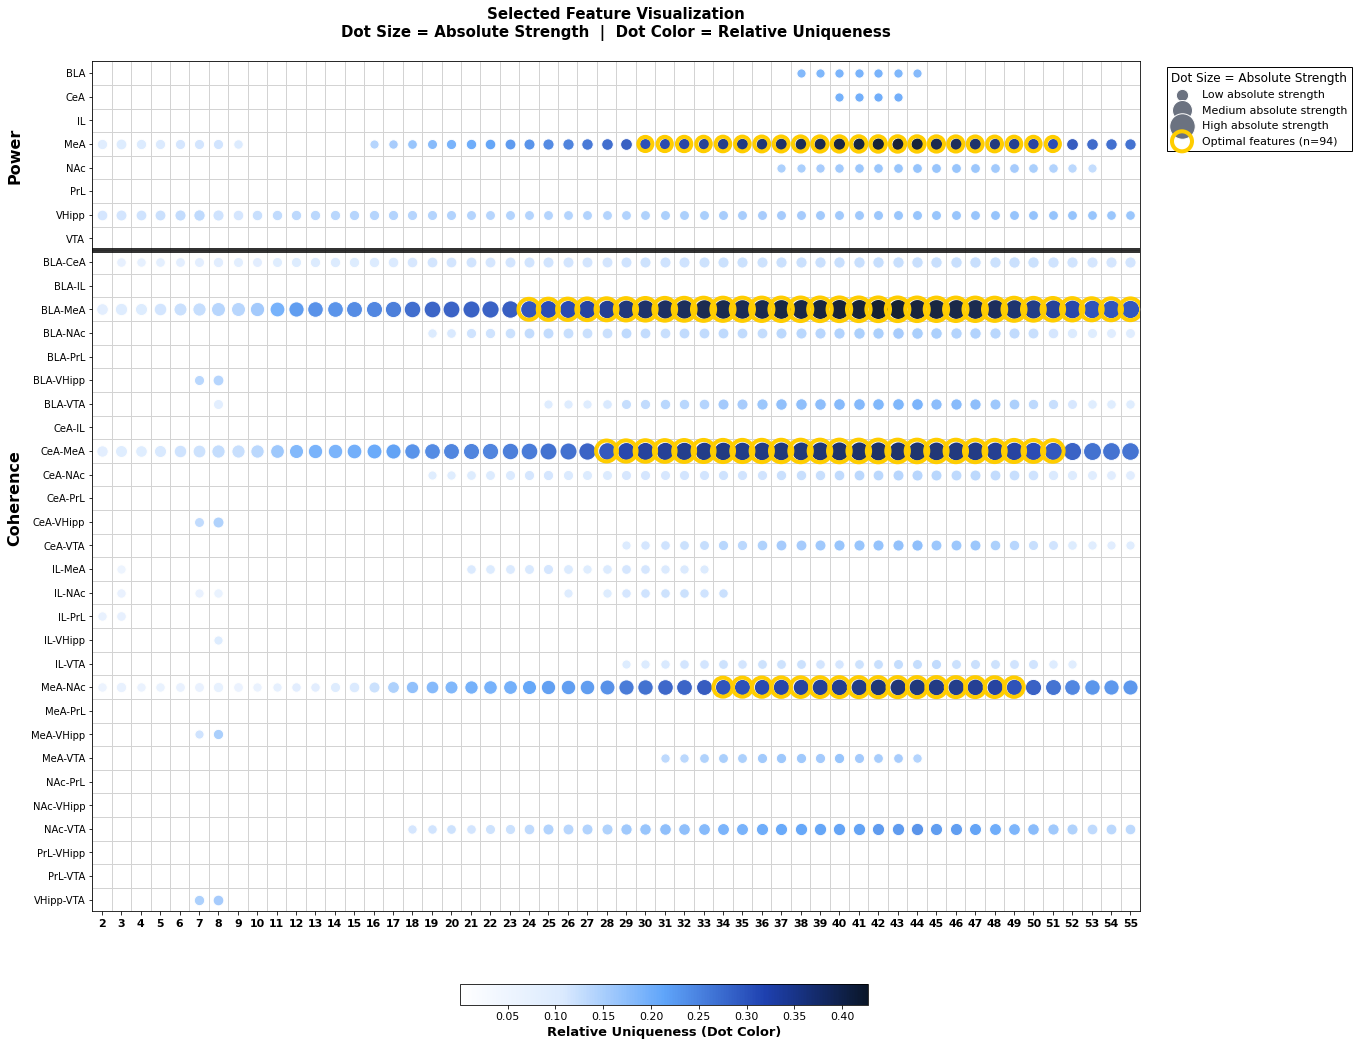

In [6]:
# =====  =====
abs_df_cut, rel_df_cut, both_df_cut, abs_df, rel_df = process_W_nmf_all(
    W_nmf_data, 
    train_dict, 
    abs_cum_ratio=0.8, 
    rel_val=0.3
)

fig = create_dot_heatmap(abs_df, abs_df_cut, rel_df, rel_df_cut, both_df_cut)

plt.savefig('Selected_stage1hz_80.png', dpi=300, bbox_inches='tight')
plt.savefig('Selected_stage1hz_80.pdf', bbox_inches='tight')

plt.show()


Step 1: Check Row L2 Norms
Factor 0: 44.0908126831
Factor 1: 44.0907745361
Factor 2: 44.0908164978
Factor 3: 44.0908279419
Factor 4: 44.0908203125
Factor 5: 44.0908203125
Factor 6: 44.0907974243
Factor 7: 44.0908126831
Factor 8: 44.0907974243
Factor 9: 44.0908012390
✓ All row L2 norms are equal: 44.090813

Step 2: Absolute Strength Analysis (Based on L2 Norm Cumulation)
Cumulative ratio threshold: 0.7
Selected features: 346/1944

--- Absolute Strength (After Cutoff) ---
           (2, 3)  (3, 4)  (4, 5)  (5, 6)  (6, 7)  (7, 8)  (8, 9)  (9, 10)  \
BLA           NaN     NaN     NaN     NaN     NaN     NaN     NaN      NaN   
CeA           NaN     NaN     NaN     NaN     NaN     NaN     NaN      NaN   
IL            NaN     NaN     NaN     NaN     NaN     NaN     NaN      NaN   
MeA           NaN  1.0853     NaN     NaN     NaN     NaN     NaN      NaN   
NAc           NaN     NaN     NaN     NaN     NaN     NaN     NaN      NaN   
PrL           NaN     NaN     NaN     NaN     NaN     NaN

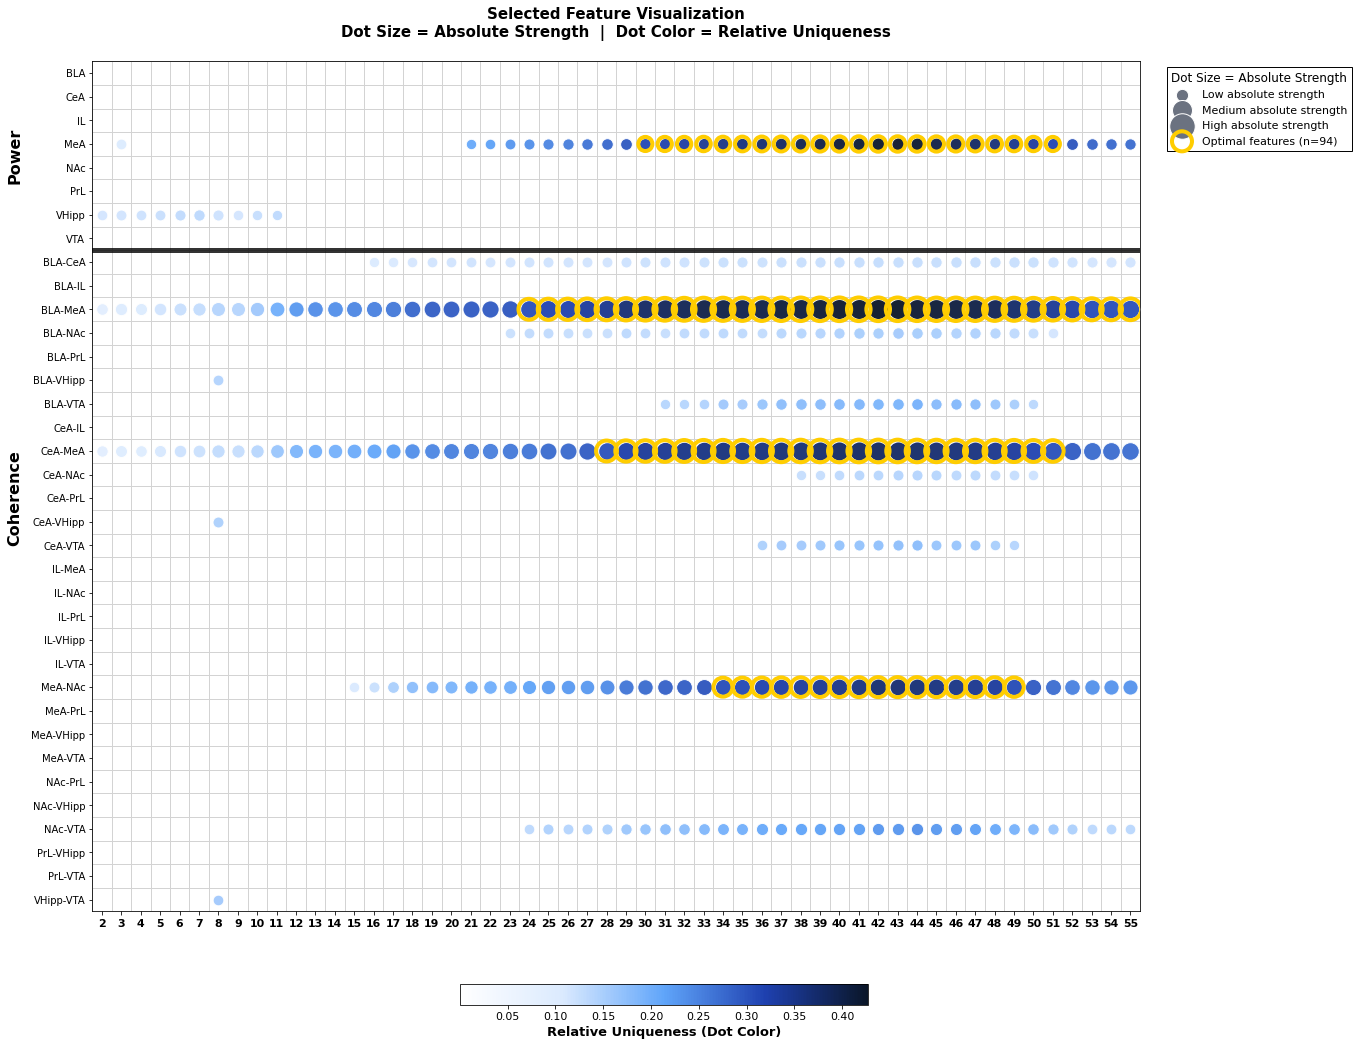

In [7]:
# =====  =====
abs_df_cut, rel_df_cut, both_df_cut, abs_df, rel_df = process_W_nmf_all(
    W_nmf_data, 
    train_dict, 
    abs_cum_ratio=0.7, 
    rel_val=0.3
)

fig = create_dot_heatmap(abs_df, abs_df_cut, rel_df, rel_df_cut, both_df_cut)

plt.savefig('Selected_stage1hz_70.png', dpi=300, bbox_inches='tight')
plt.savefig('Selected_stage1hz_70.pdf', bbox_inches='tight')

plt.show()


Step 1: Check Row L2 Norms
Factor 0: 44.0908126831
Factor 1: 44.0907745361
Factor 2: 44.0908164978
Factor 3: 44.0908279419
Factor 4: 44.0908203125
Factor 5: 44.0908203125
Factor 6: 44.0907974243
Factor 7: 44.0908126831
Factor 8: 44.0907974243
Factor 9: 44.0908012390
✓ All row L2 norms are equal: 44.090813

Step 2: Absolute Strength Analysis (Based on L2 Norm Cumulation)
Cumulative ratio threshold: 0.6
Selected features: 193/1944

--- Absolute Strength (After Cutoff) ---
           (2, 3)  (3, 4)  (4, 5)  (5, 6)  (6, 7)  (7, 8)  (8, 9)  (9, 10)  \
BLA           NaN     NaN     NaN     NaN     NaN     NaN     NaN      NaN   
CeA           NaN     NaN     NaN     NaN     NaN     NaN     NaN      NaN   
IL            NaN     NaN     NaN     NaN     NaN     NaN     NaN      NaN   
MeA           NaN     NaN     NaN     NaN     NaN     NaN     NaN      NaN   
NAc           NaN     NaN     NaN     NaN     NaN     NaN     NaN      NaN   
PrL           NaN     NaN     NaN     NaN     NaN     NaN

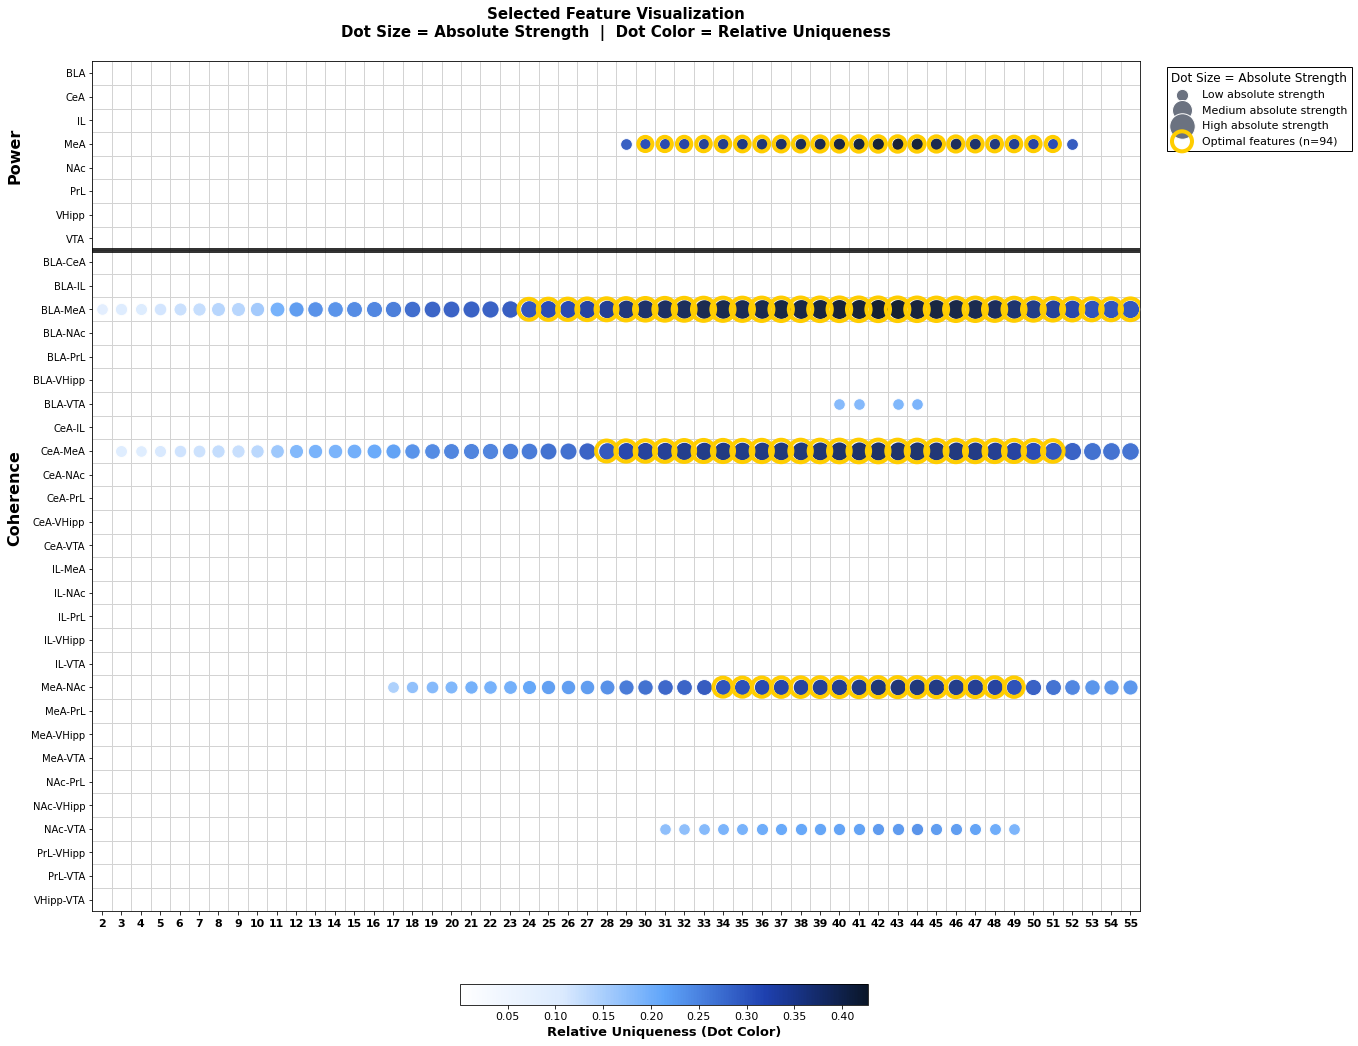

In [8]:
# =====  =====
abs_df_cut, rel_df_cut, both_df_cut, abs_df, rel_df = process_W_nmf_all(
    W_nmf_data, 
    train_dict, 
    abs_cum_ratio=0.6, 
    rel_val=0.3
)

fig = create_dot_heatmap(abs_df, abs_df_cut, rel_df, rel_df_cut, both_df_cut)

plt.savefig('Selected_stage1hz_60.png', dpi=300, bbox_inches='tight')
plt.savefig('Selected_stage1hz_60.pdf', bbox_inches='tight')

plt.show()


Step 1: Check Row L2 Norms
Factor 0: 44.0908126831
Factor 1: 44.0907745361
Factor 2: 44.0908164978
Factor 3: 44.0908279419
Factor 4: 44.0908203125
Factor 5: 44.0908203125
Factor 6: 44.0907974243
Factor 7: 44.0908126831
Factor 8: 44.0907974243
Factor 9: 44.0908012390
✓ All row L2 norms are equal: 44.090813

Step 2: Absolute Strength Analysis (Based on L2 Norm Cumulation)
Cumulative ratio threshold: 0.5
Selected features: 110/1944

--- Absolute Strength (After Cutoff) ---
           (2, 3)  (3, 4)  (4, 5)  (5, 6)  (6, 7)  (7, 8)  (8, 9)  (9, 10)  \
BLA           NaN     NaN     NaN     NaN     NaN     NaN     NaN      NaN   
CeA           NaN     NaN     NaN     NaN     NaN     NaN     NaN      NaN   
IL            NaN     NaN     NaN     NaN     NaN     NaN     NaN      NaN   
MeA           NaN     NaN     NaN     NaN     NaN     NaN     NaN      NaN   
NAc           NaN     NaN     NaN     NaN     NaN     NaN     NaN      NaN   
PrL           NaN     NaN     NaN     NaN     NaN     NaN

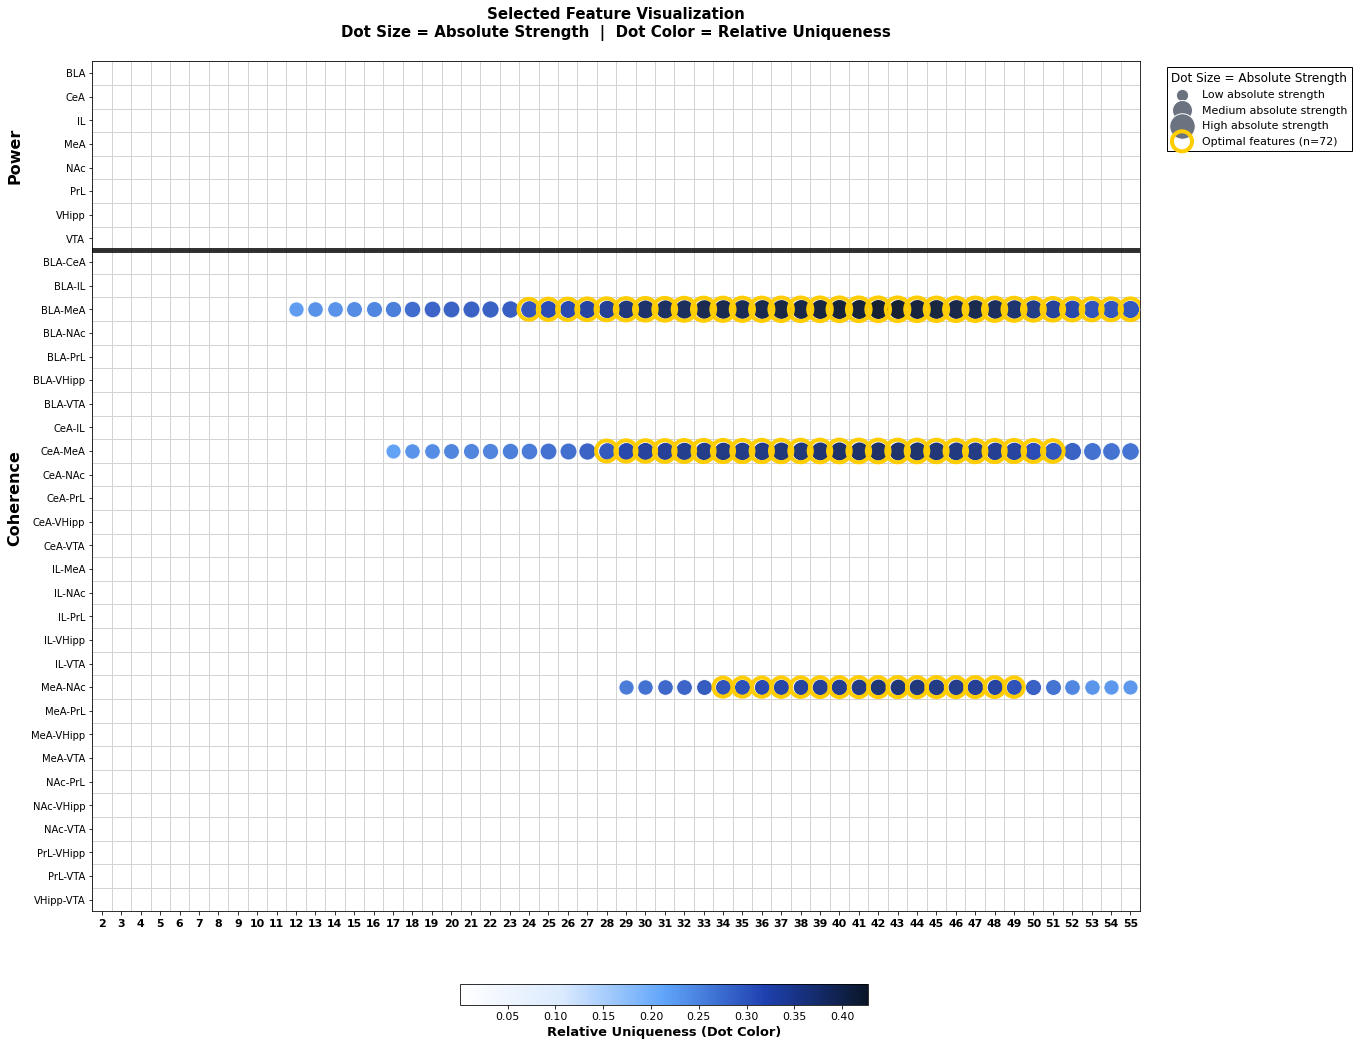

In [9]:
# =====  =====
abs_df_cut, rel_df_cut, both_df_cut, abs_df, rel_df = process_W_nmf_all(
    W_nmf_data, 
    train_dict, 
    abs_cum_ratio=0.5, 
    rel_val=0.3
)

fig = create_dot_heatmap(abs_df, abs_df_cut, rel_df, rel_df_cut, both_df_cut)

plt.savefig('Selected_stage1hz_50.png', dpi=300, bbox_inches='tight')
plt.savefig('Selected_stage1hz_50.pdf', bbox_inches='tight')

plt.show()


# Test on other data / validation

In [14]:
MODEL_SAVE_FILE = "Maternal_model_TrainC_Pre_P134_1Hz_ver2.pt"
model = torch.load(MODEL_SAVE_FILE, map_location='cpu')
model.device = 'cpu'

model.eval()

dCSFA_NMF(
  (recon_loss_f): MSELoss()
  (Encoder): Sequential(
    (0): Linear(in_features=1944, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.01)
    (3): Linear(in_features=128, out_features=10, bias=True)
    (4): Softplus(beta=1, threshold=20)
  )
  (phi_list): ParameterList(  (0): Parameter containing: [torch.FloatTensor of size 1])
  (beta_list): ParameterList(  (0): Parameter containing: [torch.FloatTensor of size 1x1])
)

Creating Test E Dataset
Initial test E filtered samples: 44000
Test E unique periods: ['P1' 'P3' 'P4 home' 'Pre home']
Test E unique mouse IDs: ['E1ELS33' 'E2ELS3' 'E3ELS37' 'E4ELS39' 'E5ELS41' 'E6ELS44']

P4 HOME DATA FILTERING: FIRST 20 MINUTES ONLY

P4 Home Data Filtering Summary:
Mouse_ID  Original_Windows  Kept_Windows  Removed_Windows  Total_Minutes  Kept_Minutes
 E1ELS33               400           400                0         20.000        20.000
 E3ELS37               400           400                0         20.000        20.000
 E4ELS39               400           400                0         20.000        20.000
 E5ELS41               400           400                0         20.000        20.000
 E6ELS44               400           400                0         20.000        20.000

Total windows removed from P4 home: 0

Verifying P4 home data after filtering:
  E1ELS33: 400 P4 home windows (20.0 minutes)
  E3ELS37: 400 P4 home windows (20.0 minutes)
  E4ELS39: 400 P4 hom

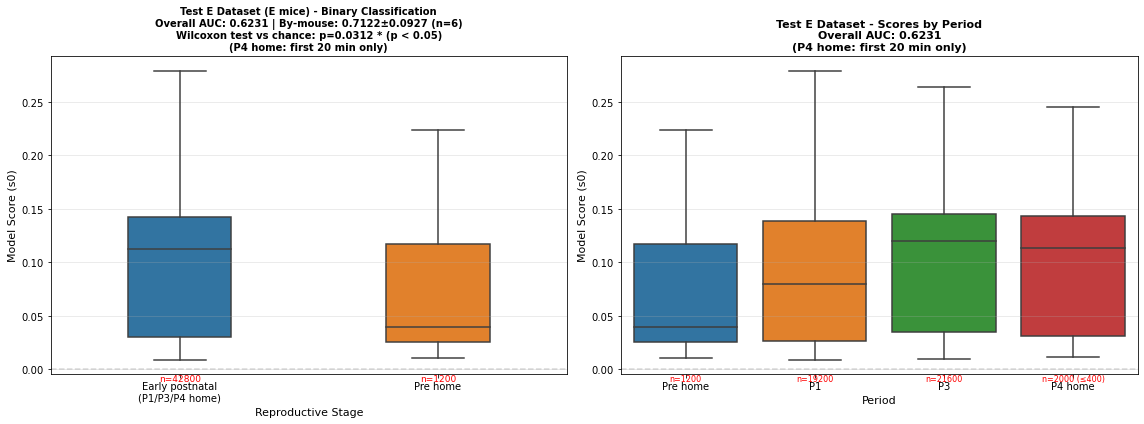


Saved: test_e_evaluation_with_stats.png

Score Distribution Analysis
Test E score range: [0.0090, 0.2792]
Test E mean score: 0.0932 ± 0.0582 (SD)

Score statistics by label:
Test E Pre home: 0.0671 ± 0.0518
Test E Early postnatal: 0.0940 ± 0.0582

Test E Per-Mouse Performance Details
Mouse ID        AUC        n_samples    Pre home     Postnatal    P4 home      Diff from 0.5
-----------------------------------------------------------------------------------------------
E1ELS33         0.6355     9000         200          8800         400          +0.1355
E2ELS3          0.5610     3800         200          3600         0            +0.0610
E3ELS37         0.4911     4200         200          4000         400          -0.0089
E4ELS39         0.9984     9000         200          8800         400          +0.4984
E5ELS41         1.0000     9000         200          8800         400          +0.5000
E6ELS44         0.5871     9000         200          8800         400          +0.0871

Su

In [15]:
import numpy as np
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.metrics import roc_auc_score
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
from scipy.stats import wilcoxon

# ========== PART 1: Create Test E Dataset ==========
print("="*60)
print("Creating Test E Dataset")
print("="*60)

# Define periods and E mouse IDs to keep
periods_to_keep = ['Pre home', 'P1', 'P3', 'P4 home']
test_e_mouse_ids = ['E2ELS3', 'E1ELS33', 'E3ELS37', 'E4ELS39', 'E5ELS41', 'E6ELS44']

# Clean mouse_id function
def clean_mouse_id(mouse_id):
    cleaned = mouse_id.replace('Mouse', '')
    cleaned = re.sub(r'F\d+', '', cleaned)
    return cleaned

# Clean all mouse_ids
cleaned_mouse_ids = np.array([clean_mouse_id(mid) for mid in train_dict['mouse_id']])

# Create filter masks for test_E dataset
period_mask = np.isin(train_dict[Y_FEATURE], periods_to_keep)
mouse_mask = np.isin(cleaned_mouse_ids, test_e_mouse_ids)
combined_mask = period_mask & mouse_mask

print(f"Initial test E filtered samples: {np.sum(combined_mask)}")

# Filter all related arrays for test_E
test_e_data = {}
for key in train_dict:
    if isinstance(train_dict[key], np.ndarray) and len(train_dict[key]) == len(train_dict[Y_FEATURE]):
        test_e_data[key] = train_dict[key][combined_mask]

# Update cleaned mouse_ids for test_E
test_e_mouse_ids_filtered = cleaned_mouse_ids[combined_mask]

print(f"Test E unique periods: {np.unique(test_e_data[Y_FEATURE])}")
print(f"Test E unique mouse IDs: {np.unique(test_e_mouse_ids_filtered)}")

# ================================================================
# P4 HOME DATA FILTERING: FIRST 20 MINUTES ONLY
# ================================================================
print("\n" + "="*80)
print("P4 HOME DATA FILTERING: FIRST 20 MINUTES ONLY")
print("="*80)

# Create DataFrame for easier manipulation
temp_df = pd.DataFrame({
    'mouse_id': test_e_mouse_ids_filtered,
    'period': test_e_data[Y_FEATURE]
})

# Add original index
temp_df['original_idx'] = np.arange(len(test_e_mouse_ids_filtered))

p4_filtering_stats = []
indices_to_drop = []

for mouse_id in test_e_mouse_ids:
    # Get P4 home data for this mouse
    p4_mask = (temp_df['mouse_id'] == mouse_id) & (temp_df['period'] == 'P4 home')
    p4_indices = temp_df[p4_mask]['original_idx'].values
    
    if len(p4_indices) > 0:
        original_count = len(p4_indices)
        
        # Keep only first 400 windows (20 minutes * 60 seconds / 3 seconds per window)
        max_windows = 400
        
        if original_count > max_windows:
            # Mark indices to drop (everything after first 400 windows)
            drop_indices = p4_indices[max_windows:]
            indices_to_drop.extend(drop_indices.tolist())
            kept_count = max_windows
        else:
            kept_count = original_count
        
        removed_count = original_count - kept_count
        
        p4_filtering_stats.append({
            'Mouse_ID': mouse_id,
            'Original_Windows': original_count,
            'Kept_Windows': kept_count,
            'Removed_Windows': removed_count,
            'Total_Minutes': original_count * 3 / 60,
            'Kept_Minutes': kept_count * 3 / 60
        })

# Execute deletion
if indices_to_drop:
    print(f"\nRemoving {len(indices_to_drop)} time windows from P4 home data...")
    
    # Create keep mask
    keep_mask = np.ones(len(test_e_mouse_ids_filtered), dtype=bool)
    keep_mask[indices_to_drop] = False
    
    # Update all filtered data
    for key in test_e_data:
        if isinstance(test_e_data[key], np.ndarray):
            test_e_data[key] = test_e_data[key][keep_mask]
    
    test_e_mouse_ids_filtered = test_e_mouse_ids_filtered[keep_mask]
    
    print(f"Filtered data shape after P4 removal: {len(test_e_mouse_ids_filtered)}")

# Display P4 filtering statistics
if p4_filtering_stats:
    p4_stats_df = pd.DataFrame(p4_filtering_stats)
    print("\nP4 Home Data Filtering Summary:")
    print(p4_stats_df.to_string(index=False))
    print(f"\nTotal windows removed from P4 home: {p4_stats_df['Removed_Windows'].sum()}")
else:
    print("\nNo P4 home data found for test E mice.")

# Verify P4 filtering results
print("\nVerifying P4 home data after filtering:")
for mouse_id in test_e_mouse_ids:
    p4_count = np.sum((test_e_mouse_ids_filtered == mouse_id) & (test_e_data[Y_FEATURE] == 'P4 home'))
    if p4_count > 0:
        print(f"  {mouse_id}: {p4_count} P4 home windows ({p4_count * 3 / 60:.1f} minutes)")

print("="*80)

# Check data distribution for each E mouse (after P4 filtering)
print("\nData distribution for each E mouse (P4 home limited to ≤400 windows):")
for mouse_id in np.unique(test_e_mouse_ids_filtered):
    mouse_data = test_e_data[Y_FEATURE][test_e_mouse_ids_filtered == mouse_id]
    pre_home_count = np.sum(mouse_data == 'Pre home')
    P1_count = np.sum(mouse_data == 'P1')
    P3_count = np.sum(mouse_data == 'P3')
    P4_home_count = np.sum(mouse_data == 'P4 home')
    total_positive = P1_count + P3_count + P4_home_count
    print(f"{mouse_id}: Pre home={pre_home_count}, P1={P1_count}, P3={P3_count}, "
          f"P4 home={P4_home_count} (≤400), Total positive={total_positive}, Total={len(mouse_data)}")

# Create test_E dataset
def create_test_e_dataset():
    # Prepare X features
    X_test_e = np.hstack([test_e_data[feature]*weight for feature, weight in zip(X_FEATURE_LIST, X_FEATURE_WEIGHTS)])
    
    # Prepare binary labels: Pre home = 0, P1/P3/P4 home = 1
    y_binary = np.zeros(len(test_e_data[Y_FEATURE]), dtype=int)
    positive_periods = ['P1', 'P3', 'P4 home']
    positive_mask = np.isin(test_e_data[Y_FEATURE], positive_periods)
    y_binary[positive_mask] = 1
    
    y_test_e = y_binary.reshape(-1, 1)
    
    # Prepare intercept features (using cleaned mouse_id)
    y_intercept_test_e = test_e_mouse_ids_filtered
    
    # Create encoder for test_E
    test_e_ordinal_encoder = OrdinalEncoder()
    y_sampling_test_e = test_e_ordinal_encoder.fit_transform(y_intercept_test_e.reshape(-1, 1))
    
    test_e_onehot_encoder = OneHotEncoder()
    y_intercept_mask_test_e = test_e_onehot_encoder.fit_transform(y_intercept_test_e.reshape(-1, 1)).todense()
    
    test_e_dataset = {
        'X_test_e': X_test_e,
        'y_test_e': y_test_e,
        'y_intercept_test_e': y_intercept_test_e,
        'y_sampling_test_e': y_sampling_test_e,
        'y_intercept_mask_test_e': y_intercept_mask_test_e,
        'test_e_periods': test_e_data[Y_FEATURE],
        'test_e_intercept_dim': y_intercept_mask_test_e.shape[1],
        'test_e_mouse_list': np.unique(test_e_mouse_ids_filtered)
    }
    
    return test_e_dataset

# Create test_E dataset
test_e_dataset = create_test_e_dataset()

print(f"\n" + "="*60)
print("Successfully created Test E dataset!")
print("="*60)
print(f"Test E shape: X={test_e_dataset['X_test_e'].shape}, y={test_e_dataset['y_test_e'].shape}")
print(f"Test E intercept dimension: {test_e_dataset['test_e_intercept_dim']}")
print(f"Test E mice: {test_e_dataset['test_e_mouse_list']}")
print("Note: P4 home data limited to first 20 minutes (≤400 windows) per mouse")

# Label distribution
print(f"\nLabel distribution (P4 home limited):")
print(f"Pre home samples (label=0): {np.sum(test_e_dataset['y_test_e'] == 0)}")
print(f"Early postnatal samples (P1/P3/P4 home, label=1): {np.sum(test_e_dataset['y_test_e'] == 1)}")

# Detailed period distribution statistics
print(f"\nSample distribution by period (P4 home limited):")
for period in periods_to_keep:
    if period in np.unique(test_e_data[Y_FEATURE]):
        period_mask = test_e_data[Y_FEATURE] == period
        count = np.sum(period_mask)
        if period == 'Pre home':
            label_desc = "label=0"
        else:
            label_desc = "label=1"
        period_note = " (≤400 windows per mouse)" if period == 'P4 home' else ""
        print(f"{period}: {count} samples ({label_desc}){period_note}")
    else:
        print(f"{period}: 0 samples (no data)")

# Validate binary labels
print(f"\nLabel validation:")
print(f"Total samples: {len(test_e_dataset['y_test_e'])}")
print(f"Label=0 samples: {np.sum(test_e_dataset['y_test_e'] == 0)}")
print(f"Label=1 samples: {np.sum(test_e_dataset['y_test_e'] == 1)}")
if len(test_e_dataset['y_test_e']) > 0:
    print(f"Label distribution: {np.sum(test_e_dataset['y_test_e'] == 0) / len(test_e_dataset['y_test_e']):.2%} vs "
          f"{np.sum(test_e_dataset['y_test_e'] == 1) / len(test_e_dataset['y_test_e']):.2%}")

# Check period coverage for each E mouse
print(f"\nPeriod coverage for each E mouse:")
for mouse_id in np.unique(test_e_mouse_ids_filtered):
    mouse_periods = test_e_data[Y_FEATURE][test_e_mouse_ids_filtered == mouse_id]
    periods_present = list(np.unique(mouse_periods))
    coverage = len(periods_present)
    print(f"{mouse_id}: {coverage} periods {periods_present}")


# ========== PART 2: Test E Dataset Evaluation ==========
print("\n" + "="*60)
print("Test E Dataset Evaluation (using Train C Model)")
print("Note: P4 home data limited to first 20 minutes per mouse")
print("="*60)

# Extract test_E data
X_test_e = test_e_dataset['X_test_e']
y_test_e = test_e_dataset['y_test_e']
y_intercept_test_e = test_e_dataset['y_intercept_test_e']
test_e_periods = test_e_dataset['test_e_periods']

print(f"Test E mice: {test_e_dataset['test_e_mouse_list']}")
print(f"Test E dataset: X={X_test_e.shape}, y={y_test_e.shape}")

# ========== Evaluate Test E ==========
overall_auc_test_e, per_mouse_aucs_test_e, mean_auc_test_e, std_auc_test_e, sem_auc_test_e = \
    calculate_per_mouse_auc(model, X_test_e, y_test_e.squeeze(), y_intercept_test_e, "Test E")

# ========== STATISTICAL TEST: Wilcoxon Signed-Rank Test ==========
print(f"\n" + "="*60)
print("STATISTICAL TEST - Wilcoxon Signed-Rank Test")
print("="*60)

if per_mouse_aucs_test_e and len(per_mouse_aucs_test_e) > 0:
    # Convert to numpy array
    test_e_aucs_array = np.array(per_mouse_aucs_test_e)
    n_mice_test_e = len(test_e_aucs_array)
    
    print(f"\nTest E Summary Statistics (n={n_mice_test_e} mice):")
    print(f"Mean AUC: {mean_auc_test_e:.4f}")
    print(f"SD: {std_auc_test_e:.4f}")
    print(f"SEM: {sem_auc_test_e:.4f}")
    print(f"Median AUC: {np.median(test_e_aucs_array):.4f}")
    print(f"Range: [{test_e_aucs_array.min():.4f}, {test_e_aucs_array.max():.4f}]")
    
    # Compute differences from 0.5
    differences = test_e_aucs_array - 0.5
    
    print(f"\nPer-mouse AUCs and differences from chance (0.5):")
    for i, (mouse_id, auc, diff) in enumerate(zip(test_e_dataset['test_e_mouse_list'], 
                                                   test_e_aucs_array, differences), 1):
        print(f"  {mouse_id}: AUC={auc:.4f}, diff={diff:+.4f}")
    
    # Perform one-sided Wilcoxon signed-rank test
    statistic, p_value = wilcoxon(differences, alternative='greater')
    
    print(f"\nWilcoxon Signed-Rank Test (one-sided)")
    print(f"H0: Population true AUC = 0.5 (chance level)")
    print(f"H1: Population true AUC > 0.5")
    print(f"\nTest Statistic: {statistic}")
    print(f"P-value: {p_value:.6f}")
    
    if p_value < 0.001:
        significance = "*** (p < 0.001)"
    elif p_value < 0.01:
        significance = "** (p < 0.01)"
    elif p_value < 0.05:
        significance = "* (p < 0.05)"
    else:
        significance = "ns (not significant)"
    
    print(f"Significance: {significance}")
    
    # Additional info
    n_above_chance = np.sum(test_e_aucs_array > 0.5)
    n_at_or_below_chance = np.sum(test_e_aucs_array <= 0.5)
    print(f"\nNumber of mice with AUC > 0.5: {n_above_chance}/{n_mice_test_e}")
    print(f"Number of mice with AUC ≤ 0.5: {n_at_or_below_chance}/{n_mice_test_e}")
    
    # Effect size
    median_difference = np.median(differences)
    mean_difference = np.mean(differences)
    print(f"\nEffect Size:")
    print(f"Median difference from chance: {median_difference:.4f}")
    print(f"Mean difference from chance: {mean_difference:.4f}")
else:
    print("\nWARNING: No per-mouse AUCs available for Test E dataset!")
    print("Statistical test cannot be performed.")
    p_value = None
    significance = "N/A"

# ========== Get predictions for visualization ==========
model.eval()
y_pred_proba_test_e, s_test_e = model.predict_proba(X_test_e, include_scores=True)

# ========== Create visualization data ==========
data_test_e = pd.DataFrame({
    's0': s_test_e[:, 0],
    'y_test': y_test_e.flatten(),
    'period': test_e_periods
})

data_test_e['label_category'] = data_test_e['y_test'].map({
    0: 'Pre home',
    1: 'Early postnatal\n(P1/P3/P4 home)'
})

# ========== Create Test E visualizations ==========
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Binary classification visualization
sns.boxplot(x='label_category', y='s0', data=data_test_e, width=0.4, ax=axes[0])
if mean_auc_test_e is not None and per_mouse_aucs_test_e and p_value is not None:
    title_text = f"Test E Dataset (E mice) - Binary Classification\n"
    title_text += f"Overall AUC: {overall_auc_test_e:.4f} | By-mouse: {mean_auc_test_e:.4f}±{sem_auc_test_e:.4f} (n={len(per_mouse_aucs_test_e)})\n"
    title_text += f"Wilcoxon test vs chance: p={p_value:.4f} {significance}\n"
    title_text += f"(P4 home: first 20 min only)"
    axes[0].set_title(title_text, fontsize=10, fontweight='bold')
else:
    title_text = f"Test E Dataset (E mice) - Binary Classification\n"
    title_text += f"Overall AUC: {overall_auc_test_e:.4f}\n"
    title_text += f"(P4 home: first 20 min only)"
    axes[0].set_title(title_text, fontsize=11, fontweight='bold')
axes[0].set_xlabel("Reproductive Stage", fontsize=11)
axes[0].set_ylabel("Model Score (s0)", fontsize=11)
axes[0].axhline(y=0, color='gray', linestyle='--', alpha=0.3)
axes[0].grid(alpha=0.3, axis='y')

# Add sample counts
for i, label in enumerate(sorted(data_test_e['label_category'].unique())):
    count = np.sum(data_test_e['label_category'] == label)
    axes[0].text(i, axes[0].get_ylim()[0], f'n={count}', 
                ha='center', va='top', fontsize=9, color='red')

# Plot 2: Detailed period visualization
period_order = ['Pre home', 'P1', 'P3', 'P4 home']
existing_periods = [p for p in period_order if p in data_test_e['period'].values]
sns.boxplot(x='period', y='s0', data=data_test_e, order=existing_periods, ax=axes[1])
title_text = f"Test E Dataset - Scores by Period\n"
title_text += f"Overall AUC: {overall_auc_test_e:.4f}\n"
title_text += f"(P4 home: first 20 min only)"
axes[1].set_title(title_text, fontsize=11, fontweight='bold')
axes[1].set_xlabel("Period", fontsize=11)
axes[1].set_ylabel("Model Score (s0)", fontsize=11)
axes[1].axhline(y=0, color='gray', linestyle='--', alpha=0.3)
axes[1].grid(alpha=0.3, axis='y')

# Add sample counts
for i, period in enumerate(existing_periods):
    count = np.sum(data_test_e['period'] == period)
    period_note = " (≤400)" if period == 'P4 home' else ""
    axes[1].text(i, axes[1].get_ylim()[0], f'n={count}{period_note}', 
                ha='center', va='top', fontsize=8, color='red')

plt.tight_layout()
plt.savefig('test_e_evaluation_with_stats.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"\nSaved: test_e_evaluation_with_stats.png")

# ========== Score distribution analysis ==========
print(f"\n" + "="*60)
print("Score Distribution Analysis")
print("="*60)
print(f"Test E score range: [{data_test_e['s0'].min():.4f}, {data_test_e['s0'].max():.4f}]")
print(f"Test E mean score: {data_test_e['s0'].mean():.4f} ± {data_test_e['s0'].std():.4f} (SD)")

print(f"\nScore statistics by label:")
print(f"Test E Pre home: {data_test_e[data_test_e['y_test']==0]['s0'].mean():.4f} ± {data_test_e[data_test_e['y_test']==0]['s0'].std():.4f}")
print(f"Test E Early postnatal: {data_test_e[data_test_e['y_test']==1]['s0'].mean():.4f} ± {data_test_e[data_test_e['y_test']==1]['s0'].std():.4f}")

# ========== Per-mouse performance breakdown ==========
print(f"\n" + "="*60)
print("Test E Per-Mouse Performance Details")
print("="*60)
if per_mouse_aucs_test_e:
    unique_mice = np.unique(y_intercept_test_e)
    print(f"{'Mouse ID':<15} {'AUC':<10} {'n_samples':<12} {'Pre home':<12} {'Postnatal':<12} {'P4 home':<12} {'Diff from 0.5'}")
    print("-" * 95)
    for i, (mouse_id, auc) in enumerate(zip(unique_mice, per_mouse_aucs_test_e)):
        mouse_mask = y_intercept_test_e == mouse_id
        n_total = np.sum(mouse_mask)
        n_pre = np.sum((y_intercept_test_e == mouse_id) & (y_test_e.squeeze() == 0))
        n_post = np.sum((y_intercept_test_e == mouse_id) & (y_test_e.squeeze() == 1))
        n_p4 = np.sum((y_intercept_test_e == mouse_id) & (test_e_periods == 'P4 home'))
        diff = auc - 0.5
        print(f"{mouse_id:<15} {auc:<10.4f} {n_total:<12} {n_pre:<12} {n_post:<12} {n_p4:<12} {diff:+.4f}")
    
    print(f"\n{'='*95}")
    print(f"Summary: Mean±SEM = {mean_auc_test_e:.4f}±{sem_auc_test_e:.4f} (n={n_mice_test_e} mice)")
    if p_value is not None:
        print(f"         Wilcoxon test: p={p_value:.6f} {significance}")
    print(f"         Note: P4 home limited to first 20 minutes (≤400 windows) per mouse")
    print(f"{'='*95}")

print(f"\n" + "="*60)
print("Test E Evaluation Completed!")
print("="*60)

# Backproject on the FULL Stages - Untrimmed data

In [16]:
TRAINING_DATA_FILE = "/Volumes/rdss_rhultman/datashare/ELS and Maternal Behavior/Spec_Features_1Hz_8roi/combined/full_spec_features_Trim_All.pkl"

X_FEATURE_LIST = ["power", "coh_sq_coherence"]
X_FEATURE_WEIGHTS = [1, 1]


with open(TRAINING_DATA_FILE, "rb") as f:
    train_dict = pickle.load(f)

X_data = np.hstack([train_dict[feature]*weight for feature, weight in zip(X_FEATURE_LIST, X_FEATURE_WEIGHTS)])
mouse_id = train_dict['mouse_id']

def clean_mouse_id(mouse_id):
    import re
    cleaned = mouse_id.replace('Mouse', '')
    cleaned = re.sub(r'F\d+', '', cleaned)
    return cleaned

cleaned_mouse_ids = np.array([clean_mouse_id(mid) for mid in mouse_id])
print(f"Original mouse IDs sample: {mouse_id[:5]}")
print(f"Cleaned mouse IDs sample: {cleaned_mouse_ids[:5]}")
print(f"Unique cleaned mouse IDs: {np.unique(cleaned_mouse_ids)}")


# Define mouse ID classification
c_mice_ids = ['C6ELS9', 'C7ELS11', 'C2ELS18', 'C5ELS20', 'C7ELS22', 
              'C1ELS32', 'C5ELS40', 'C6ELS42', 'C7ELS45']
e_mice_ids = ['E2ELS3', 'E1ELS33', 'E3ELS37', 'E4ELS39', 'E5ELS41', 'E6ELS44']

Original mouse IDs sample: ['MouseC1F3ELS32' 'MouseC1F3ELS32' 'MouseC1F3ELS32' 'MouseC1F3ELS32'
 'MouseC1F3ELS32']
Cleaned mouse IDs sample: ['C1ELS32' 'C1ELS32' 'C1ELS32' 'C1ELS32' 'C1ELS32']
Unique cleaned mouse IDs: ['C1ELS32' 'C2ELS18' 'C5ELS20' 'C5ELS40' 'C6ELS42' 'C6ELS9' 'C7ELS11'
 'C7ELS22' 'C7ELS45' 'E1ELS33' 'E2ELS3' 'E3ELS37' 'E4ELS39' 'E5ELS41'
 'E6ELS44']


In [17]:
MODEL_SAVE_FILE = "Maternal_model_TrainC_Pre_P134_1Hz_ver2.pt"

model = torch.load(MODEL_SAVE_FILE, map_location='cpu')
model.device = 'cpu'
model.eval()

dCSFA_NMF(
  (recon_loss_f): MSELoss()
  (Encoder): Sequential(
    (0): Linear(in_features=1944, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.01)
    (3): Linear(in_features=128, out_features=10, bias=True)
    (4): Softplus(beta=1, threshold=20)
  )
  (phi_list): ParameterList(  (0): Parameter containing: [torch.FloatTensor of size 1])
  (beta_list): ParameterList(  (0): Parameter containing: [torch.FloatTensor of size 1x1])
)

In [18]:
_, scores = model.predict_proba(X_data, include_scores=True)

In [19]:
def assign_mouse_type(mouse_id):
    if mouse_id in c_mice_ids:
        return 'C mice'
    elif mouse_id in e_mice_ids:
        return 'E mice'
    else:
        return 'Other'

def categorize_period_six_groups(period):
    if period in ['Pre home', 'Pre pup']:
        return 'Pre'
    elif period == 'Ges':
        return 'Ges'
    elif period == 'P1':
        return 'P1'
    elif period == 'P3':
        return 'P3'
    elif period in ['P4 home', 'P4 open']:
        return 'P4'
    elif period == 'P8':
        return 'P8'
    elif period == 'P14':
        return 'P14'
    elif period == 'P20':
        return 'P20'
    else:
        return 'Other'

# Filter to only target mice with at least 3 stages
def filter_target_mice_with_3plus_stages(df, target_c_ids, target_e_ids, min_stages=3):
    """Filter to only target mice with at least min_stages stages"""
    # Filter to only target mice
    target_mice = df[df['mouse_id'].isin(target_c_ids + target_e_ids)].copy()
    
    # Count stages per mouse
    mouse_stage_counts = target_mice.groupby('mouse_id')['stage'].nunique()
    
    # Get mice with at least min_stages stages
    mice_with_enough_stages = mouse_stage_counts[mouse_stage_counts >= min_stages].index.tolist()
    
    # Filter dataframe
    filtered_df = target_mice[target_mice['mouse_id'].isin(mice_with_enough_stages)].copy()
    
    return filtered_df, mice_with_enough_stages

### Individual tables and Wilcoxon rank-sum test, plot mean+-se

### Save all data while plotting

In [20]:
from scipy import stats
def create_four_visualizations_with_tables(filtered_df, selected_mice, order):
    """Create all four requested visualizations with detailed tables
    
    Note: For P4 stage, only the first 20 minutes (400 time windows) are used per mouse
    """
    
    # ================================================================
    # DATA FILTERING: Keep only first 20 minutes of P4 recordings
    # ================================================================
    print("\n" + "="*80)
    print("DATA FILTERING: P4 STAGE - FIRST 20 MINUTES ONLY")
    print("="*80)
    
    filtered_df = filtered_df.copy()
    
    # Process P4 data for each mouse
    p4_filtering_stats = []
    rows_to_drop = []
    
    for mouse_id in selected_mice:
        # Get P4 data for this mouse
        p4_mask = (filtered_df['mouse_id'] == mouse_id) & (filtered_df['stage'] == 'P4')
        p4_indices = filtered_df[p4_mask].index
        
        if len(p4_indices) > 0:
            original_count = len(p4_indices)
            
            # Keep only first 400 windows (20 minutes * 60 seconds / 3 seconds per window)
            max_windows = 400
            
            if original_count > max_windows:
                # Mark indices to drop (everything after first 400 windows)
                indices_to_drop = p4_indices[max_windows:]
                rows_to_drop.extend(indices_to_drop.tolist())
                kept_count = max_windows
            else:
                kept_count = original_count
            
            removed_count = original_count - kept_count
            
            p4_filtering_stats.append({
                'Mouse_ID': mouse_id,
                'Original_Windows': original_count,
                'Kept_Windows': kept_count,
                'Removed_Windows': removed_count,
                'Total_Minutes': original_count * 3 / 60,
                'Kept_Minutes': kept_count * 3 / 60
            })
    
    # Drop the rows
    if rows_to_drop:
        print(f"\nRemoving {len(rows_to_drop)} time windows from P4 data...")
        filtered_df = filtered_df.drop(rows_to_drop)
        print(f"Filtered dataframe shape: {filtered_df.shape}")
    
    if p4_filtering_stats:
        p4_stats_df = pd.DataFrame(p4_filtering_stats)
        print("\nP4 Data Filtering Summary:")
        print(p4_stats_df.to_string(index=False))
        print(f"\nTotal windows removed from P4: {p4_stats_df['Removed_Windows'].sum()}")
    else:
        print("\nNo P4 data found for selected mice.")
    
    print("\n" + "="*80)
    print("PROCEEDING WITH FILTERED DATA")
    print("="*80)
    
    # Calculate global y-axis limits for consistent scaling
    global_min = filtered_df['s0'].min()
    global_max = filtered_df['s0'].max()
    y_padding = (global_max - global_min) * 0.1
    global_ylim = [global_min - y_padding, global_max + y_padding]
    
    # Split mice by type
    c_mice_selected = [m for m in selected_mice if m in c_mice_ids]
    e_mice_selected = [m for m in selected_mice if m in e_mice_ids]
    
    print(f"\nSelected mice for analysis:")
    print(f"C mice ({len(c_mice_selected)}): {c_mice_selected}")
    print(f"E mice ({len(e_mice_selected)}): {e_mice_selected}")
    
    # Verify P4 filtering worked
    print("\nVerifying P4 data after filtering:")
    for mouse_id in selected_mice:
        p4_count = len(filtered_df[(filtered_df['mouse_id'] == mouse_id) & 
                                   (filtered_df['stage'] == 'P4')])
        if p4_count > 0:
            print(f"  {mouse_id}: {p4_count} P4 windows ({p4_count * 3 / 60:.1f} minutes)")
    
    # ================================================================
    # TABLE 1: Individual Mouse Scores by Stage
    # ================================================================
    print("\n" + "="*80)
    print("TABLE 1: INDIVIDUAL MOUSE MEDIAN SCORES BY STAGE")
    print("="*80)
    
    individual_scores_data = []
    
    for mouse_id in selected_mice:
        mouse_data = filtered_df[filtered_df['mouse_id'] == mouse_id]
        mouse_type = mouse_data['mouse_type'].iloc[0]
        
        row = {'Mouse_ID': mouse_id, 'Type': mouse_type}
        
        for stage in order:
            stage_scores = mouse_data[mouse_data['stage'] == stage]['s0']
            if len(stage_scores) > 0:
                row[f'{stage}_median'] = stage_scores.median()
                row[f'{stage}_mean'] = stage_scores.mean()
                row[f'{stage}_std'] = stage_scores.std()
                row[f'{stage}_n'] = len(stage_scores)
            else:
                row[f'{stage}_median'] = np.nan
                row[f'{stage}_mean'] = np.nan
                row[f'{stage}_std'] = np.nan
                row[f'{stage}_n'] = 0
        
        individual_scores_data.append(row)
    
    individual_scores_df = pd.DataFrame(individual_scores_data)
    
    # Display median scores table
    median_cols = ['Mouse_ID', 'Type'] + [f'{stage}_median' for stage in order]
    print("\nMedian Scores:")
    print(individual_scores_df[median_cols].to_string(index=False))
    
    # Display sample counts
    n_cols = ['Mouse_ID', 'Type'] + [f'{stage}_n' for stage in order]
    print("\nSample Counts (note: P4 limited to first 20 minutes = 400 windows max):")
    print(individual_scores_df[n_cols].to_string(index=False))
    
    # ================================================================
    # TABLE 2: Individual Mouse Percentage Changes from Pre Baseline
    # ================================================================
    print("\n" + "="*80)
    print("TABLE 2: INDIVIDUAL MOUSE PERCENTAGE CHANGES FROM PRE BASELINE")
    print("="*80)
    
    mouse_pct_changes = {}
    mouse_median_scores = {}  # NEW: Store median scores for each mouse/stage
    pct_change_data = []
    
    for mouse_id in selected_mice:
        mouse_data = filtered_df[filtered_df['mouse_id'] == mouse_id]
        mouse_type = mouse_data['mouse_type'].iloc[0]
        
        # Get Pre baseline
        pre_data = mouse_data[mouse_data['stage'] == 'Pre']['s0']
        if len(pre_data) == 0:
            continue
        
        pre_baseline = pre_data.median()
        
        row = {
            'Mouse_ID': mouse_id, 
            'Type': mouse_type,
            'Pre_baseline': pre_baseline
        }
        
        # Calculate percentage changes and store median scores
        pct_changes = {}
        median_scores = {}
        
        for stage in order:
            stage_data = mouse_data[mouse_data['stage'] == stage]['s0']
            
            if len(stage_data) > 0:
                stage_median = stage_data.median()
                median_scores[stage] = stage_median  # Store median score
                
                if stage == 'Pre':
                    pct_changes[stage] = 0
                    row[stage] = 0.0
                else:
                    pct_change = ((stage_median - pre_baseline) / abs(pre_baseline)) * 100
                    pct_changes[stage] = pct_change
                    row[stage] = pct_change
            else:
                median_scores[stage] = np.nan
                pct_changes[stage] = np.nan
                row[stage] = np.nan
        
        mouse_pct_changes[mouse_id] = pct_changes
        mouse_median_scores[mouse_id] = median_scores  # NEW: Store median scores
        pct_change_data.append(row)
    
    pct_change_df = pd.DataFrame(pct_change_data)
    print(pct_change_df.to_string(index=False, float_format='%.2f'))
    
    # ================================================================
    # TABLE 3: Group Average Scores (C vs E)
    # ================================================================
    print("\n" + "="*80)
    print("TABLE 3: GROUP AVERAGE SCORES BY STAGE")
    print("="*80)
    
    group_scores_data = []
    
    for mouse_type in ['C mice', 'E mice']:
        row = {'Group': mouse_type}
        
        for stage in order:
            stage_type_data = filtered_df[
                (filtered_df['stage'] == stage) & 
                (filtered_df['mouse_type'] == mouse_type)
            ]['s0']
            
            if len(stage_type_data) > 0:
                row[f'{stage}_mean'] = stage_type_data.mean()
                row[f'{stage}_median'] = stage_type_data.median()
                row[f'{stage}_std'] = stage_type_data.std()
                row[f'{stage}_sem'] = stage_type_data.sem()
                row[f'{stage}_n'] = len(stage_type_data)
            else:
                row[f'{stage}_mean'] = np.nan
                row[f'{stage}_median'] = np.nan
                row[f'{stage}_std'] = np.nan
                row[f'{stage}_sem'] = np.nan
                row[f'{stage}_n'] = 0
        
        group_scores_data.append(row)
    
    group_scores_df = pd.DataFrame(group_scores_data)
    
    # Display mean ± SEM
    print("\nMean ± SEM:")
    for _, row in group_scores_df.iterrows():
        print(f"\n{row['Group']}:")
        for stage in order:
            mean_val = row[f'{stage}_mean']
            sem_val = row[f'{stage}_sem']
            n_val = row[f'{stage}_n']
            if not np.isnan(mean_val):
                print(f"  {stage:12s}: {mean_val:7.4f} ± {sem_val:7.4f} (n={int(n_val)})")
            else:
                print(f"  {stage:12s}: No data")
    
    # ================================================================
    # TABLE 4: Group Average Percentage Changes from Pre
    # ================================================================
    print("\n" + "="*80)
    print("TABLE 4: GROUP AVERAGE PERCENTAGE CHANGES FROM PRE BASELINE")
    print("="*80)
    
    group_pct_data = []
    
    for mouse_type_name in ['C mice', 'E mice']:
        row = {'Group': mouse_type_name}
        
        mice_list = c_mice_selected if mouse_type_name == 'C mice' else e_mice_selected
        
        for stage in order:
            if stage == 'Pre':
                row[f'{stage}_mean'] = 0.0
                row[f'{stage}_std'] = 0.0
                row[f'{stage}_sem'] = 0.0
                row[f'{stage}_n'] = len(mice_list)
            else:
                stage_changes = []
                for mouse_id in mice_list:
                    if mouse_id in mouse_pct_changes and stage in mouse_pct_changes[mouse_id]:
                        if not np.isnan(mouse_pct_changes[mouse_id][stage]):
                            stage_changes.append(mouse_pct_changes[mouse_id][stage])
                
                if stage_changes:
                    row[f'{stage}_mean'] = np.mean(stage_changes)
                    row[f'{stage}_std'] = np.std(stage_changes, ddof=1)
                    row[f'{stage}_sem'] = np.std(stage_changes, ddof=1) / np.sqrt(len(stage_changes))
                    row[f'{stage}_n'] = len(stage_changes)
                else:
                    row[f'{stage}_mean'] = np.nan
                    row[f'{stage}_std'] = np.nan
                    row[f'{stage}_sem'] = np.nan
                    row[f'{stage}_n'] = 0
        
        group_pct_data.append(row)
    
    group_pct_df = pd.DataFrame(group_pct_data)
    
    # Display
    print("\nMean ± SEM (%):")
    for _, row in group_pct_df.iterrows():
        print(f"\n{row['Group']}:")
        for stage in order:
            mean_val = row[f'{stage}_mean']
            sem_val = row[f'{stage}_sem']
            n_val = row[f'{stage}_n']
            if not np.isnan(mean_val):
                print(f"  {stage:12s}: {mean_val:7.2f}% ± {sem_val:7.2f}% (n={int(n_val)})")
            else:
                print(f"  {stage:12s}: No data")
    
    # ================================================================
    # TABLE 5: Statistical Tests (Wilcoxon Rank-Sum on Percentage Changes)
    # ================================================================
    print("\n" + "="*80)
    print("TABLE 5: WILCOXON RANK-SUM TEST ON PERCENTAGE CHANGES (C mice vs E mice)")
    print("="*80)
    
    statistical_tests_data = []
    
    for stage in order:
        if stage == 'Pre':
            statistical_tests_data.append({
                'Stage': stage,
                'C_n_mice': len(c_mice_selected),
                'C_mean_pct': 0.0,
                'C_median_pct': 0.0,
                'C_std_pct': 0.0,
                'E_n_mice': len(e_mice_selected),
                'E_mean_pct': 0.0,
                'E_median_pct': 0.0,
                'E_std_pct': 0.0,
                'U_statistic': np.nan,
                'p_value': np.nan,
                'rank_biserial': np.nan,
                'significance': 'N/A (baseline)'
            })
            continue
        
        # Collect C group percentage changes
        c_pct_changes = []
        for mouse_id in c_mice_selected:
            if mouse_id in mouse_pct_changes and stage in mouse_pct_changes[mouse_id]:
                if not np.isnan(mouse_pct_changes[mouse_id][stage]):
                    c_pct_changes.append(mouse_pct_changes[mouse_id][stage])
        
        # Collect E group percentage changes
        e_pct_changes = []
        for mouse_id in e_mice_selected:
            if mouse_id in mouse_pct_changes and stage in mouse_pct_changes[mouse_id]:
                if not np.isnan(mouse_pct_changes[mouse_id][stage]):
                    e_pct_changes.append(mouse_pct_changes[mouse_id][stage])
        
        # Perform statistical test
        if len(c_pct_changes) > 0 and len(e_pct_changes) > 0:
            statistic, p_value = stats.mannwhitneyu(c_pct_changes, e_pct_changes, alternative='two-sided')
            
            n1, n2 = len(c_pct_changes), len(e_pct_changes)
            u_statistic = statistic
            rank_biserial = 1 - (2*u_statistic) / (n1 * n2)
            
            if p_value < 0.001:
                significance = '***'
            elif p_value < 0.01:
                significance = '**'
            elif p_value < 0.05:
                significance = '*'
            else:
                significance = 'ns'
            
            statistical_tests_data.append({
                'Stage': stage,
                'C_n_mice': n1,
                'C_mean_pct': np.mean(c_pct_changes),
                'C_median_pct': np.median(c_pct_changes),
                'C_std_pct': np.std(c_pct_changes, ddof=1),
                'E_n_mice': n2,
                'E_mean_pct': np.mean(e_pct_changes),
                'E_median_pct': np.median(e_pct_changes),
                'E_std_pct': np.std(e_pct_changes, ddof=1), 
                'U_statistic': u_statistic,
                'p_value': p_value,
                'rank_biserial': rank_biserial,
                'significance': significance
            })
        else:
            statistical_tests_data.append({
                'Stage': stage,
                'C_n_mice': len(c_pct_changes),
                'C_mean_pct': np.nan,
                'C_median_pct': np.nan,
                'C_std_pct': np.nan,
                'E_n_mice': len(e_pct_changes),
                'E_mean_pct': np.nan,
                'E_median_pct': np.nan,
                'E_std_pct': np.nan,
                'U_statistic': np.nan,
                'p_value': np.nan,
                'rank_biserial': np.nan,
                'significance': 'N/A'
            })
    
    statistical_tests_df = pd.DataFrame(statistical_tests_data)
    
    # Display results
    print("\nWilcoxon Rank-Sum Test Results (% change from Pre baseline):")
    print("-" * 80)
    for _, row in statistical_tests_df.iterrows():
        if row['Stage'] == 'Pre':
            print(f"{row['Stage']:12s}: Baseline (no comparison)")
        elif not np.isnan(row['p_value']):
            print(f"{row['Stage']:12s}: "
                  f"C(n={int(row['C_n_mice'])}, mean={row['C_mean_pct']:6.2f}%, std={row['C_std_pct']:5.2f}) vs "
                  f"E(n={int(row['E_n_mice'])}, mean={row['E_mean_pct']:6.2f}%, std={row['E_std_pct']:5.2f}) | "
                  f"U={row['U_statistic']:.1f}, p={row['p_value']:.4f} {row['significance']}")
        else:
            print(f"{row['Stage']:12s}: Insufficient data")
    
    print("\nSignificance levels: *** p<0.001, ** p<0.01, * p<0.05, ns = not significant")
    print("Note: Test compares percentage changes from Pre baseline between C and E groups")
    print("      Each mouse's percentage change is calculated relative to its own Pre baseline")
    print("      P4 data limited to first 20 minutes per mouse")
    
    # ================================================================
    # Save all tables to CSV
    # ================================================================
    individual_scores_df.to_csv('individual_scores_by_stage.csv', index=False)
    pct_change_df.to_csv('individual_percentage_changes.csv', index=False)
    group_scores_df.to_csv('group_scores_by_stage.csv', index=False)
    group_pct_df.to_csv('group_percentage_changes.csv', index=False)
    statistical_tests_df.to_csv('statistical_tests_c_vs_e.csv', index=False)
    
    if p4_filtering_stats:
        p4_stats_df.to_csv('p4_filtering_summary.csv', index=False)
    
    # ================================================================
    # Continue with original visualizations
    # ================================================================
    n_mice = len(selected_mice)
    n_cols = 4
    n_rows = (n_mice + n_cols - 1) // n_cols
    
    # FIGURE 1: Individual mouse boxplots
    fig1, axes1 = plt.subplots(n_rows, n_cols, figsize=(20, 5*n_rows))
    fig1.suptitle('Individual Mouse Score Distributions by Stage\n(P4: First 20 minutes only)', 
                  fontsize=16, y=0.95)
    
    if n_rows == 1:
        axes1 = axes1.reshape(1, -1)
    
    for i, mouse_id in enumerate(selected_mice):
        row, col = i // n_cols, i % n_cols
        ax = axes1[row, col]
        
        mouse_data = filtered_df[filtered_df['mouse_id'] == mouse_id]
        mouse_type = mouse_data['mouse_type'].iloc[0]
        
        stage_data = []
        stage_labels = []
        for stage in order:
            stage_scores = mouse_data[mouse_data['stage'] == stage]['s0']
            if len(stage_scores) > 0:
                stage_data.append(stage_scores.values)
                stage_labels.append(stage)
        
        if stage_data:
            bp = ax.boxplot(stage_data, labels=stage_labels, patch_artist=True)
            color = 'lightblue' if mouse_type == 'C mice' else 'lightcoral'
            for patch in bp['boxes']:
                patch.set_facecolor(color)
        
        ax.set_title(f'{mouse_id} ({mouse_type})', fontsize=12)
        ax.set_ylabel('Score (s0)' if col == 0 else '')
        ax.set_ylim(global_ylim)
        ax.tick_params(axis='x', rotation=45)
        ax.grid(axis='y', alpha=0.3)
    
    for i in range(n_mice, n_rows * n_cols):
        row, col = i // n_cols, i % n_cols
        axes1[row, col].set_visible(False)
    
    plt.tight_layout()
    
    # FIGURE 2: Individual percentage changes
    fig2, axes2 = plt.subplots(n_rows, n_cols, figsize=(20, 5*n_rows))
    fig2.suptitle('Individual Mouse Percentage Changes from Pre Baseline\n(P4: First 20 minutes only)', 
                  fontsize=16, y=0.95)
    
    if n_rows == 1:
        axes2 = axes2.reshape(1, -1)
    
    for i, mouse_id in enumerate(selected_mice):
        if mouse_id not in mouse_pct_changes:
            continue
            
        row, col = i // n_cols, i % n_cols
        ax = axes2[row, col]
        
        mouse_type = filtered_df[filtered_df['mouse_id'] == mouse_id]['mouse_type'].iloc[0]
        pct_data = mouse_pct_changes[mouse_id]
        
        stages = list(pct_data.keys())
        values = list(pct_data.values())
        
        color = 'blue' if mouse_type == 'C mice' else 'red'
        ax.plot(stages, values, 'o-', color=color, linewidth=2, markersize=6)
        ax.axhline(y=0, color='gray', linestyle='--', alpha=0.7)
        
        ax.set_title(f'{mouse_id} ({mouse_type})', fontsize=12)
        ax.set_ylabel('% Change from Pre' if col == 0 else '')
        ax.tick_params(axis='x', rotation=45)
        ax.grid(axis='y', alpha=0.3)
        
        for stage, value in pct_data.items():
            if not np.isnan(value):
                ax.text(stage, value + 2, f'{value:.1f}%', ha='center', va='bottom', fontsize=9)
    
    for i in range(len(selected_mice), n_rows * n_cols):
        row, col = i // n_cols, i % n_cols
        axes2[row, col].set_visible(False)
    
    plt.tight_layout()
    
    # FIGURE 3: Group comparison
    fig3, ax3 = plt.subplots(figsize=(12, 8))
    
    plot_data = []
    for stage in order:
        for mouse_type in ['C mice', 'E mice']:
            stage_type_data = filtered_df[
                (filtered_df['stage'] == stage) & 
                (filtered_df['mouse_type'] == mouse_type)
            ]['s0']
            
            for value in stage_type_data:
                plot_data.append({
                    'Stage': stage,
                    'Mouse_Type': mouse_type,
                    'Score': value
                })
    
    plot_df = pd.DataFrame(plot_data)
    
    if not plot_df.empty:
        sns.boxplot(data=plot_df, x='Stage', y='Score', hue='Mouse_Type', 
                   palette={'C mice': 'lightblue', 'E mice': 'lightcoral'}, ax=ax3)
        
        ax3.set_title('Score Distributions by Stage and Mouse Type\n(P4: First 20 minutes only)', 
                     fontsize=14)
        ax3.set_ylabel('Score (s0)', fontsize=12)
        ax3.set_xlabel('Developmental Stage', fontsize=12)
        ax3.tick_params(axis='x', rotation=45)
        ax3.grid(axis='y', alpha=0.3)
        ax3.legend(title='Mouse Type')
    
    plt.tight_layout()
    
    # FIGURE 4: Group average percentage changes
    fig4, ax4 = plt.subplots(figsize=(12, 8))
    
    c_mice_changes = []
    e_mice_changes = []
    c_mice_sem = []
    e_mice_sem = []
    
    for stage in order:
        if stage == 'Pre':
            c_mice_changes.append(0)
            e_mice_changes.append(0)
            c_mice_sem.append(0)
            e_mice_sem.append(0)
            continue
        
        c_stage_changes = []
        for mouse_id in c_mice_selected:
            if mouse_id in mouse_pct_changes and stage in mouse_pct_changes[mouse_id]:
                if not np.isnan(mouse_pct_changes[mouse_id][stage]):
                    c_stage_changes.append(mouse_pct_changes[mouse_id][stage])
        
        e_stage_changes = []
        for mouse_id in e_mice_selected:
            if mouse_id in mouse_pct_changes and stage in mouse_pct_changes[mouse_id]:
                if not np.isnan(mouse_pct_changes[mouse_id][stage]):
                    e_stage_changes.append(mouse_pct_changes[mouse_id][stage])
        
        c_mice_changes.append(np.mean(c_stage_changes) if c_stage_changes else np.nan)
        e_mice_changes.append(np.mean(e_stage_changes) if e_stage_changes else np.nan)
        c_mice_sem.append(np.std(c_stage_changes, ddof=1) / np.sqrt(len(c_stage_changes)) if len(c_stage_changes) > 1 else 0)
        e_mice_sem.append(np.std(e_stage_changes, ddof=1) / np.sqrt(len(e_stage_changes)) if len(e_stage_changes) > 1 else 0)
    
    x = np.arange(len(order))
    offset = 0.1
    
    # Plot with error bars
    ax4.errorbar(x - offset, c_mice_changes, yerr=c_mice_sem, fmt='o-', color='blue', 
                 linewidth=3, markersize=10, capsize=5, label='C mice')
    ax4.errorbar(x + offset, e_mice_changes, yerr=e_mice_sem, fmt='o-', color='red', 
                 linewidth=3, markersize=10, capsize=5, label='E mice')
    
    ax4.axhline(y=0, color='gray', linestyle='--', alpha=0.7)
    ax4.set_ylabel('Average % Change from Pre Baseline', fontsize=12)
    ax4.set_xlabel('Developmental Stage', fontsize=12)
    ax4.set_title('Group Average Percentage Growth from Pre Baseline\n(Mean ± SEM, P4: First 20 minutes only)', 
                 fontsize=14)
    ax4.set_xticks(x)
    ax4.set_xticklabels(order)
    ax4.grid(axis='y', alpha=0.3)
    ax4.legend()
    
    for i, (c_val, e_val) in enumerate(zip(c_mice_changes, e_mice_changes)):
        if not np.isnan(c_val):
            ax4.text(i - offset, c_val - c_mice_sem[i] - 2, f'{c_val:.1f}%', ha='center', va='top', 
                    fontsize=10, color='blue', weight='bold')
        if not np.isnan(e_val):
            ax4.text(i + offset, e_val + e_mice_sem[i] + 1, f'{e_val:.1f}%', ha='center', va='bottom', 
                    fontsize=10, color='red', weight='bold')
    
    plt.tight_layout()
    
    # ================================================================
    # Export Data to Excel (Enhanced Version with All Details)
    # ================================================================
    print("\n" + "="*80)
    print("EXPORTING DATA TO EXCEL (ENHANCED VERSION)")
    print("="*80)
    
    # ================================================================
    # Sheet 1: Summary_Mean_SEM
    # ================================================================
    mean_sem_export_data = []
    for i, stage in enumerate(order):
        row = {
            'Stage': stage,
            'C_mice_mean': c_mice_changes[i],
            'C_mice_SEM': c_mice_sem[i],
            'E_mice_mean': e_mice_changes[i],
            'E_mice_SEM': e_mice_sem[i]
        }
        mean_sem_export_data.append(row)
    
    mean_sem_df = pd.DataFrame(mean_sem_export_data)
    
    # ================================================================
    # Sheet 2: Summary_Median_IQR
    # ================================================================
    print("\nCalculating group-level median and IQR...")
    
    def get_group_stage_pct_changes(group_mice, stage):
        """Get percentage changes for a group at a specific stage"""
        changes = []
        for mouse_id in group_mice:
            if mouse_id in mouse_pct_changes and stage in mouse_pct_changes[mouse_id]:
                val = mouse_pct_changes[mouse_id][stage]
                if not np.isnan(val):
                    changes.append(val)
        return np.array(changes)
    
    # Calculate median and IQR for each group and stage
    median_iqr_export_data = []
    for i, stage in enumerate(order):
        row = {'Stage': stage}
        
        # C mice
        c_changes = get_group_stage_pct_changes(c_mice_selected, stage)
        if len(c_changes) > 0:
            row['C_mice_median'] = np.median(c_changes)
            row['C_mice_Q1'] = np.percentile(c_changes, 25)
            row['C_mice_Q3'] = np.percentile(c_changes, 75)
            row['C_mice_IQR'] = row['C_mice_Q3'] - row['C_mice_Q1']
            row['C_mice_n'] = len(c_changes)
        else:
            row['C_mice_median'] = np.nan
            row['C_mice_Q1'] = np.nan
            row['C_mice_Q3'] = np.nan
            row['C_mice_IQR'] = np.nan
            row['C_mice_n'] = 0
        
        # E mice
        e_changes = get_group_stage_pct_changes(e_mice_selected, stage)
        if len(e_changes) > 0:
            row['E_mice_median'] = np.median(e_changes)
            row['E_mice_Q1'] = np.percentile(e_changes, 25)
            row['E_mice_Q3'] = np.percentile(e_changes, 75)
            row['E_mice_IQR'] = row['E_mice_Q3'] - row['E_mice_Q1']
            row['E_mice_n'] = len(e_changes)
        else:
            row['E_mice_median'] = np.nan
            row['E_mice_Q1'] = np.nan
            row['E_mice_Q3'] = np.nan
            row['E_mice_IQR'] = np.nan
            row['E_mice_n'] = 0
        
        median_iqr_export_data.append(row)
    
    median_iqr_df = pd.DataFrame(median_iqr_export_data)
    
    print("\nGroup Median ± IQR Summary:")
    print(median_iqr_df.to_string(index=False, float_format='%.2f'))
    
    # ================================================================
    # Sheet 3: C_mice_stage_detail (with Median_Score added)
    # ================================================================
    print("\nPreparing C_mice_stage_detail with median scores...")
    c_mice_stage_detail = []
    for stage in order:
        for mouse_id in c_mice_selected:
            if mouse_id in mouse_pct_changes and stage in mouse_pct_changes[mouse_id]:
                row = {
                    'Stage': stage,
                    'Mouse_ID': mouse_id,
                    'Median_Score': mouse_median_scores[mouse_id][stage],
                    'Percentage_Change': mouse_pct_changes[mouse_id][stage]
                }
                c_mice_stage_detail.append(row)
    c_mice_stage_detail_df = pd.DataFrame(c_mice_stage_detail)
    
    # ================================================================
    # Sheet 4: E_mice_stage_detail (with Median_Score added)
    # ================================================================
    print("Preparing E_mice_stage_detail with median scores...")
    e_mice_stage_detail = []
    for stage in order:
        for mouse_id in e_mice_selected:
            if mouse_id in mouse_pct_changes and stage in mouse_pct_changes[mouse_id]:
                row = {
                    'Stage': stage,
                    'Mouse_ID': mouse_id,
                    'Median_Score': mouse_median_scores[mouse_id][stage],
                    'Percentage_Change': mouse_pct_changes[mouse_id][stage]
                }
                e_mice_stage_detail.append(row)
    e_mice_stage_detail_df = pd.DataFrame(e_mice_stage_detail)
    
    # ================================================================
    # Sheet 5: C_All_TimeWindow (ALL raw time window scores)
    # ================================================================
    print("\nPreparing C_All_TimeWindow (this may take a while for large datasets)...")
    c_all_timewindow = []
    for mouse_id in c_mice_selected:
        mouse_data = filtered_df[filtered_df['mouse_id'] == mouse_id]
        for stage in order:
            stage_data = mouse_data[mouse_data['stage'] == stage]
            if len(stage_data) > 0:
                # Reset time window numbering for each mouse-stage combination
                for idx, (_, row) in enumerate(stage_data.iterrows(), start=1):
                    c_all_timewindow.append({
                        'Stage': stage,
                        'Mouse_ID': mouse_id,
                        'TimeWindow': idx,
                        'LoadingScore': row['s0']
                    })
    c_all_timewindow_df = pd.DataFrame(c_all_timewindow)
    print(f"  Total rows for C mice: {len(c_all_timewindow_df)}")
    
    # ================================================================
    # Sheet 6: E_All_TimeWindow (ALL raw time window scores)
    # ================================================================
    print("Preparing E_All_TimeWindow (this may take a while for large datasets)...")
    e_all_timewindow = []
    for mouse_id in e_mice_selected:
        mouse_data = filtered_df[filtered_df['mouse_id'] == mouse_id]
        for stage in order:
            stage_data = mouse_data[mouse_data['stage'] == stage]
            if len(stage_data) > 0:
                # Reset time window numbering for each mouse-stage combination
                for idx, (_, row) in enumerate(stage_data.iterrows(), start=1):
                    e_all_timewindow.append({
                        'Stage': stage,
                        'Mouse_ID': mouse_id,
                        'TimeWindow': idx,
                        'LoadingScore': row['s0']
                    })
    e_all_timewindow_df = pd.DataFrame(e_all_timewindow)
    print(f"  Total rows for E mice: {len(e_all_timewindow_df)}")
    
    # ================================================================
    # Sheet 7: C_mice_stage_detail_wide (pivot by Mouse_ID)
    # ================================================================
    print("\nPreparing C_mice_stage_detail_wide (pivot by Mouse_ID)...")
    if len(c_mice_stage_detail_df) > 0:
        # Create pivot table with Mouse_ID as columns
        c_mice_wide = c_mice_stage_detail_df.pivot(
            index='Stage',
            columns='Mouse_ID',
            values=['Median_Score', 'Percentage_Change']
        )
        # Flatten column names: (Median_Score, C1) -> C1_Median_Score
        c_mice_wide.columns = [f'{col[1]}_{col[0]}' for col in c_mice_wide.columns]
        c_mice_wide = c_mice_wide.reset_index()
        # Reorder columns: Stage, then for each mouse: Median_Score, Percentage_Change
        stage_col = ['Stage']
        mouse_cols = []
        for mouse_id in c_mice_selected:
            if f'{mouse_id}_Median_Score' in c_mice_wide.columns:
                mouse_cols.extend([f'{mouse_id}_Median_Score', f'{mouse_id}_Percentage_Change'])
        c_mice_stage_detail_wide_df = c_mice_wide[stage_col + mouse_cols]
    else:
        c_mice_stage_detail_wide_df = pd.DataFrame()
    
    print(f"  Shape: {c_mice_stage_detail_wide_df.shape}")
    
    # ================================================================
    # Sheet 8: E_mice_stage_detail_wide (pivot by Mouse_ID)
    # ================================================================
    print("Preparing E_mice_stage_detail_wide (pivot by Mouse_ID)...")
    if len(e_mice_stage_detail_df) > 0:
        # Create pivot table with Mouse_ID as columns
        e_mice_wide = e_mice_stage_detail_df.pivot(
            index='Stage',
            columns='Mouse_ID',
            values=['Median_Score', 'Percentage_Change']
        )
        # Flatten column names
        e_mice_wide.columns = [f'{col[1]}_{col[0]}' for col in e_mice_wide.columns]
        e_mice_wide = e_mice_wide.reset_index()
        # Reorder columns
        stage_col = ['Stage']
        mouse_cols = []
        for mouse_id in e_mice_selected:
            if f'{mouse_id}_Median_Score' in e_mice_wide.columns:
                mouse_cols.extend([f'{mouse_id}_Median_Score', f'{mouse_id}_Percentage_Change'])
        e_mice_stage_detail_wide_df = e_mice_wide[stage_col + mouse_cols]
    else:
        e_mice_stage_detail_wide_df = pd.DataFrame()
    
    print(f"  Shape: {e_mice_stage_detail_wide_df.shape}")
    
    # ================================================================
    # Sheet 9: C_All_TimeWindow_wide (pivot by Mouse_ID)
    # ================================================================
    print("Preparing C_All_TimeWindow_wide (pivot by Mouse_ID)...")
    if len(c_all_timewindow_df) > 0:
        # Pivot: Stage & TimeWindow as index, Mouse_ID as columns, LoadingScore as values
        c_timewindow_wide = c_all_timewindow_df.pivot(
            index=['Stage', 'TimeWindow'],
            columns='Mouse_ID',
            values='LoadingScore'
        )
        c_timewindow_wide = c_timewindow_wide.reset_index()
        c_all_timewindow_wide_df = c_timewindow_wide
    else:
        c_all_timewindow_wide_df = pd.DataFrame()
    
    print(f"  Shape: {c_all_timewindow_wide_df.shape}")
    
    # ================================================================
    # Sheet 10: E_All_TimeWindow_wide (pivot by Mouse_ID)
    # ================================================================
    print("Preparing E_All_TimeWindow_wide (pivot by Mouse_ID)...")
    if len(e_all_timewindow_df) > 0:
        # Pivot: Stage & TimeWindow as index, Mouse_ID as columns, LoadingScore as values
        e_timewindow_wide = e_all_timewindow_df.pivot(
            index=['Stage', 'TimeWindow'],
            columns='Mouse_ID',
            values='LoadingScore'
        )
        e_timewindow_wide = e_timewindow_wide.reset_index()
        e_all_timewindow_wide_df = e_timewindow_wide
    else:
        e_all_timewindow_wide_df = pd.DataFrame()
    
    print(f"  Shape: {e_all_timewindow_wide_df.shape}")
    
    # ================================================================
    # Save to Excel with multiple sheets (now with 10 sheets!)
    # ================================================================
    print("\nWriting to Excel file (this may take a moment)...")
    with pd.ExcelWriter('StageEF.xlsx', engine='openpyxl') as writer:
        mean_sem_df.to_excel(writer, sheet_name='Summary_Mean_SEM', index=False)
        median_iqr_df.to_excel(writer, sheet_name='Summary_Median_IQR', index=False)
        c_mice_stage_detail_df.to_excel(writer, sheet_name='C_mice_stage_detail', index=False)
        e_mice_stage_detail_df.to_excel(writer, sheet_name='E_mice_stage_detail', index=False)
        c_all_timewindow_df.to_excel(writer, sheet_name='C_All_TimeWindow', index=False)
        e_all_timewindow_df.to_excel(writer, sheet_name='E_All_TimeWindow', index=False)
        # New wide format sheets
        c_mice_stage_detail_wide_df.to_excel(writer, sheet_name='C_mice_stage_detail_wide', index=False)
        e_mice_stage_detail_wide_df.to_excel(writer, sheet_name='E_mice_stage_detail_wide', index=False)
        c_all_timewindow_wide_df.to_excel(writer, sheet_name='C_All_TimeWindow_wide', index=False)
        e_all_timewindow_wide_df.to_excel(writer, sheet_name='E_All_TimeWindow_wide', index=False)
    
    print("\n" + "="*80)
    print("Excel file created: StageEF.xlsx")
    print("="*80)
    print("\nSheet 1 - Summary_Mean_SEM: Mean ± SEM for each group and stage")
    print(mean_sem_df.to_string(index=False, float_format='%.4f'))
    print("\nSheet 2 - Summary_Median_IQR: Median ± IQR for each group and stage")
    print(median_iqr_df.to_string(index=False, float_format='%.2f'))
    print(f"\nSheet 3 - C_mice_stage_detail: {len(c_mice_stage_detail_df)} rows (LONG format)")
    print("  (Stage, Mouse_ID, Median_Score, Percentage_Change)")
    print(f"\nSheet 4 - E_mice_stage_detail: {len(e_mice_stage_detail_df)} rows (LONG format)")
    print("  (Stage, Mouse_ID, Median_Score, Percentage_Change)")
    print(f"\nSheet 5 - C_All_TimeWindow: {len(c_all_timewindow_df)} rows (LONG format)")
    print("  (Stage, Mouse_ID, TimeWindow, LoadingScore)")
    print(f"\nSheet 6 - E_All_TimeWindow: {len(e_all_timewindow_df)} rows (LONG format)")
    print("  (Stage, Mouse_ID, TimeWindow, LoadingScore)")
    print(f"\nSheet 7 - C_mice_stage_detail_wide: {c_mice_stage_detail_wide_df.shape} (WIDE format)")
    print("  (Stage, C1_Median_Score, C1_Percentage_Change, C2_Median_Score, ...)")
    print(f"\nSheet 8 - E_mice_stage_detail_wide: {e_mice_stage_detail_wide_df.shape} (WIDE format)")
    print("  (Stage, E1_Median_Score, E1_Percentage_Change, E2_Median_Score, ...)")
    print(f"\nSheet 9 - C_All_TimeWindow_wide: {c_all_timewindow_wide_df.shape} (WIDE format)")
    print("  (Stage, TimeWindow, C1, C2, C3, ... - each mouse as column)")
    print(f"\nSheet 10 - E_All_TimeWindow_wide: {e_all_timewindow_wide_df.shape} (WIDE format)")
    print("  (Stage, TimeWindow, E1, E2, E3, ... - each mouse as column)")
    print("="*80)
    
    print("\n" + "="*80)
    print("Files saved:")
    print("  CSV files:")
    print("    - individual_scores_by_stage.csv")
    print("    - individual_percentage_changes.csv")
    print("    - group_scores_by_stage.csv")
    print("    - group_percentage_changes.csv")
    print("    - statistical_tests_c_vs_e.csv")
    if p4_filtering_stats:
        print("    - p4_filtering_summary.csv")
    print("  Excel file:")
    print("    - StageEF.xlsx (10 sheets)")
    print("      * Summary_Mean_SEM")
    print("      * Summary_Median_IQR")
    print("      * C_mice_stage_detail (LONG format)")
    print("      * E_mice_stage_detail (LONG format)")
    print("      * C_All_TimeWindow (LONG format)")
    print("      * E_All_TimeWindow (LONG format)")
    print("      * C_mice_stage_detail_wide (WIDE format - pivoted by Mouse_ID)")
    print("      * E_mice_stage_detail_wide (WIDE format - pivoted by Mouse_ID)")
    print("      * C_All_TimeWindow_wide (WIDE format - pivoted by Mouse_ID)")
    print("      * E_All_TimeWindow_wide (WIDE format - pivoted by Mouse_ID)")
    print("="*80)
    
    plt.show()
    
    return fig1, fig2, fig3, fig4, individual_scores_df, pct_change_df, group_scores_df, group_pct_df, statistical_tests_df


DATA FILTERING: P4 STAGE - FIRST 20 MINUTES ONLY

P4 Data Filtering Summary:
Mouse_ID  Original_Windows  Kept_Windows  Removed_Windows  Total_Minutes  Kept_Minutes
 C1ELS32               400           400                0         20.000        20.000
 C5ELS40               400           400                0         20.000        20.000
 C6ELS42               400           400                0         20.000        20.000
 C7ELS45               400           400                0         20.000        20.000
 E1ELS33               400           400                0         20.000        20.000
 E3ELS37               400           400                0         20.000        20.000
 E4ELS39               400           400                0         20.000        20.000
 E5ELS41               400           400                0         20.000        20.000
 E6ELS44               400           400                0         20.000        20.000

Total windows removed from P4: 0

PROCEEDING WITH F


EXPORTING DATA TO EXCEL (ENHANCED VERSION)

Calculating group-level median and IQR...

Group Median ± IQR Summary:
Stage  C_mice_median  C_mice_Q1  C_mice_Q3  C_mice_IQR  C_mice_n  E_mice_median  E_mice_Q1  E_mice_Q3  E_mice_IQR  E_mice_n
  Pre           0.00       0.00       0.00        0.00         9           0.00       0.00       0.00        0.00         6
  Ges          10.15      -0.36      47.30       47.65         9          19.09       6.61     112.04      105.44         6
   P1          46.24       5.13      62.10       56.98         7         100.90      12.66     238.96      226.30         4
   P3          11.88       7.01      38.97       31.96         8          17.58       6.04     143.79      137.76         6
   P4          44.85      35.54     130.47       94.93         4          15.18      12.51     172.00      159.49         5
   P8          35.11       8.87      65.62       56.75         8          17.05       6.97     120.69      113.72         6
  P14          3

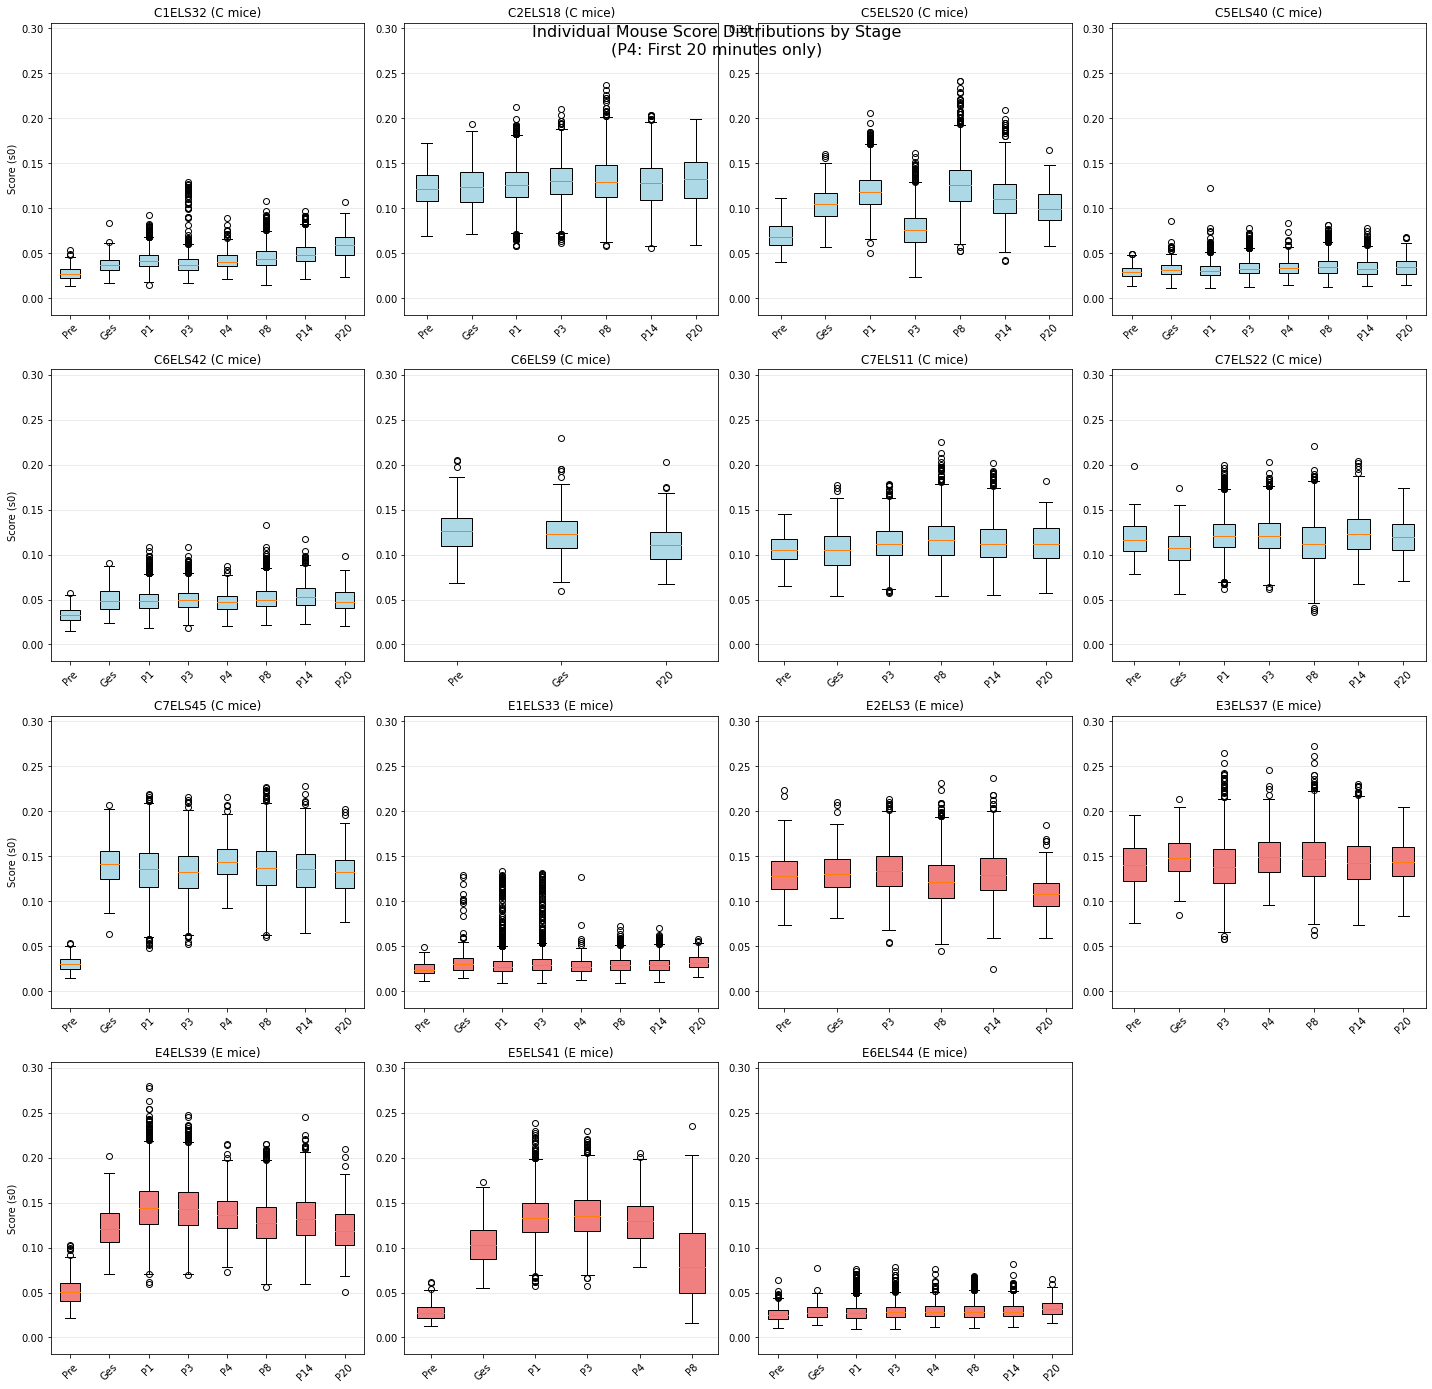

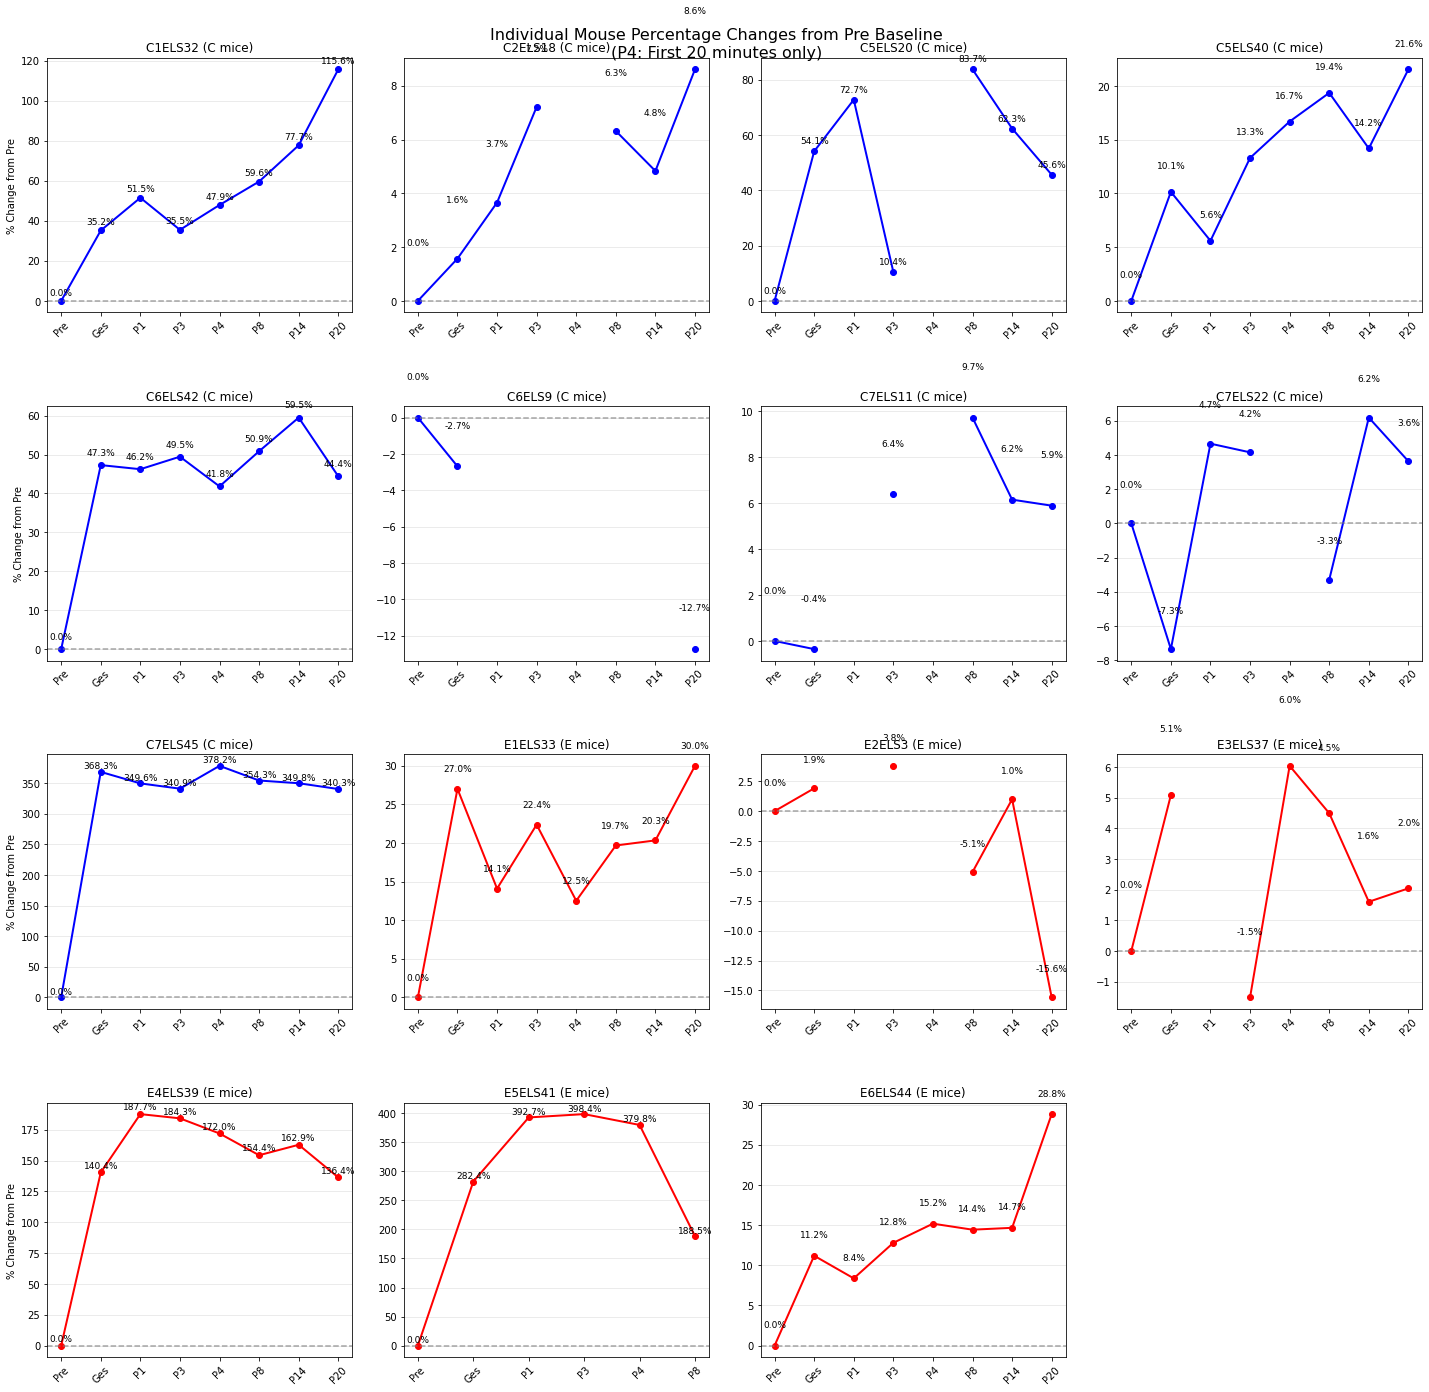

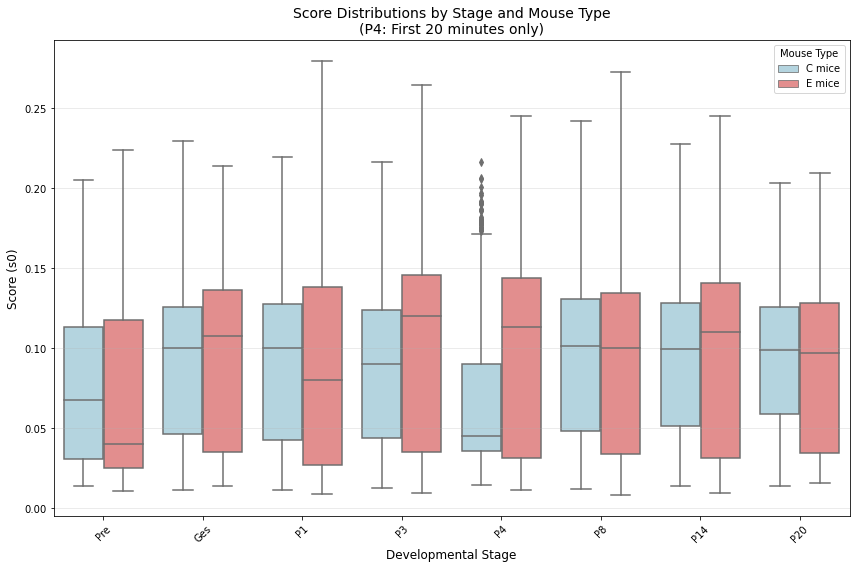

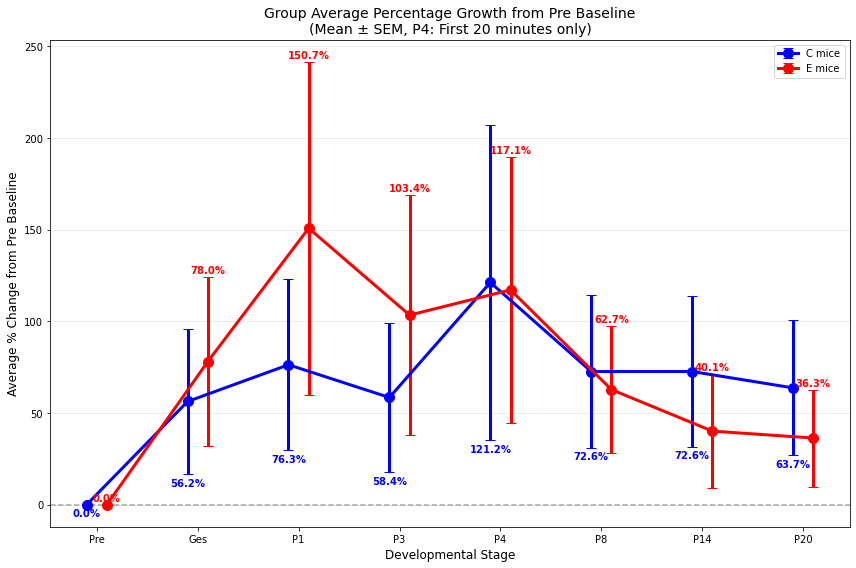

(<Figure size 1440x1440 with 16 Axes>,
 <Figure size 1440x1440 with 16 Axes>,
 <Figure size 864x576 with 1 Axes>,
 <Figure size 864x576 with 1 Axes>,
    Mouse_ID    Type  Pre_median  Pre_mean  Pre_std  Pre_n  Ges_median  \
 0   C1ELS32  C mice       0.027     0.028    0.007    200       0.037   
 1   C2ELS18  C mice       0.122     0.121    0.020    200       0.124   
 2   C5ELS20  C mice       0.068     0.070    0.015    200       0.105   
 3   C5ELS40  C mice       0.028     0.029    0.007    200       0.031   
 4   C6ELS42  C mice       0.033     0.034    0.008    200       0.048   
 5    C6ELS9  C mice       0.126     0.126    0.025    200       0.123   
 6   C7ELS11  C mice       0.106     0.106    0.017    200       0.105   
 7   C7ELS22  C mice       0.116     0.117    0.019    200       0.107   
 8   C7ELS45  C mice       0.030     0.031    0.008    200       0.141   
 9   E1ELS33  E mice       0.024     0.025    0.007    200       0.030   
 10   E2ELS3  E mice       0.128    

In [21]:
combined_df = pd.DataFrame({
    'mouse_id': cleaned_mouse_ids,
    'period': train_dict['period'],
    's0': scores[:, 0],
    'mouse_type': [assign_mouse_type(mid) for mid in cleaned_mouse_ids]
})

# Apply stage categorization
combined_df['stage'] = combined_df['period'].apply(categorize_period_six_groups)

# Step 1: Filter your data
filtered_df, selected_mice = filter_target_mice_with_3plus_stages(combined_df, c_mice_ids, e_mice_ids, 3)
# Step 2: Create visualizations
order = ['Pre', 'Ges', 'P1', 'P3', 'P4', 'P8', 'P14', 'P20']
create_four_visualizations_with_tables(filtered_df, selected_mice, order)

### Hosmer–Lemeshow statistic, Wilcoxon rank-sum test, Permutation Test on HL statistic and group (C/E) median difference, plot median and IQR, add overall Fisher Test on ALL stages

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from itertools import combinations
from math import comb

def exact_permutation_test_hl(c_vec, e_vec, observed_hl, n_max=100000):
    """
    Exact permutation test for Hodges-Lehmann statistic.
    
    Parameters:
    -----------
    c_vec : array-like
        C group values
    e_vec : array-like
        E group values
    observed_hl : float
        Observed HL statistic (median of all pairwise differences C - E)
    n_max : int
        Maximum number of permutations to compute (for safety)
    
    Returns:
    --------
    p_value : float
        Two-sided p-value
    n_perms : int
        Total number of permutations computed
    """
    c_vec = np.array(c_vec, dtype=float)
    e_vec = np.array(e_vec, dtype=float)
    
    n_c = len(c_vec)
    n_e = len(e_vec)
    n_total = n_c + n_e
    
    # Combined data
    combined = np.concatenate([c_vec, e_vec])
    
    # Total number of ways to choose n_c items from n_total
    total_perms = comb(n_total, n_c)
    
    print(f"    Total possible permutations: {total_perms}")
    
    if total_perms > n_max:
        print(f"    Warning: {total_perms} permutations exceed limit {n_max}")
        print(f"    Consider using approximate permutation test instead")
        return np.nan, total_perms
    
    # Generate all combinations
    count_extreme = 0
    abs_observed = abs(observed_hl)
    
    # Enumerate all ways to split into groups of size n_c and n_e
    for c_indices in combinations(range(n_total), n_c):
        # Indices for permuted C group
        c_indices_set = set(c_indices)
        e_indices = [i for i in range(n_total) if i not in c_indices_set]
        
        perm_c = combined[list(c_indices)]
        perm_e = combined[e_indices]
        
        # Calculate HL for this permutation
        perm_hl = np.median(perm_c[:, None] - perm_e[None, :])
        
        # Two-sided test: count if |perm_hl| >= |observed_hl|
        if abs(perm_hl) >= abs_observed:
            count_extreme += 1
    
    p_value = count_extreme / total_perms
    
    return p_value, total_perms


def exact_permutation_test_median_diff(c_vec, e_vec, observed_diff, n_max=100000):
    """
    Exact permutation test for difference of medians (C_median - E_median).
    
    Parameters:
    -----------
    c_vec : array-like
        C group values
    e_vec : array-like
        E group values
    observed_diff : float
        Observed difference (median_C - median_E)
    n_max : int
        Maximum number of permutations to compute
    
    Returns:
    --------
    p_value : float
        Two-sided p-value
    n_perms : int
        Total number of permutations computed
    """
    c_vec = np.array(c_vec, dtype=float)
    e_vec = np.array(e_vec, dtype=float)
    
    n_c = len(c_vec)
    n_e = len(e_vec)
    n_total = n_c + n_e
    
    # Combined data
    combined = np.concatenate([c_vec, e_vec])
    
    # Total number of permutations
    total_perms = comb(n_total, n_c)
    
    print(f"    Total possible permutations: {total_perms}")
    
    if total_perms > n_max:
        print(f"    Warning: {total_perms} permutations exceed limit {n_max}")
        print(f"    Consider using approximate permutation test instead")
        return np.nan, total_perms
    
    # Generate all combinations
    count_extreme = 0
    abs_observed = abs(observed_diff)
    
    for c_indices in combinations(range(n_total), n_c):
        c_indices_set = set(c_indices)
        e_indices = [i for i in range(n_total) if i not in c_indices_set]
        
        perm_c = combined[list(c_indices)]
        perm_e = combined[e_indices]
        
        # Calculate median difference for this permutation
        perm_diff = np.median(perm_c) - np.median(perm_e)
        
        # Two-sided test
        if abs(perm_diff) >= abs_observed:
            count_extreme += 1
    
    p_value = count_extreme / total_perms
    
    return p_value, total_perms


def fisher_combine_pvalues(p_values, method_name=""):
    """
    Fisher's method for combining p-values.
    
    Parameters:
    -----------
    p_values : array-like
        List of p-values to combine (must be independent tests)
    method_name : str
        Name of the statistical method (for display)
    
    Returns:
    --------
    combined_p : float
        Combined p-value
    chi2_stat : float
        Fisher's chi-square statistic
    df : int
        Degrees of freedom (2k)
    k : int
        Number of valid p-values used
    """
    # Filter out NaN and invalid p-values
    p_values = np.array(p_values)
    valid_mask = ~np.isnan(p_values) & (p_values > 0) & (p_values <= 1)
    valid_p = p_values[valid_mask]
    
    k = len(valid_p)
    
    if k == 0:
        print(f"  [{method_name}] No valid p-values to combine")
        return np.nan, np.nan, 0, 0
    
    # Fisher's chi-square statistic: -2 * sum(ln(p_i))
    chi2_stat = -2 * np.sum(np.log(valid_p))
    
    # Degrees of freedom = 2k
    df = 2 * k
    
    # Combined p-value from chi-square distribution
    combined_p = 1 - stats.chi2.cdf(chi2_stat, df)
    
    print(f"  [{method_name}] Fisher's method:")
    print(f"    - Number of stages combined: {k}")
    print(f"    - Individual p-values: {valid_p}")
    print(f"    - Chi-square statistic: {chi2_stat:.4f}")
    print(f"    - Degrees of freedom: {df}")
    print(f"    - Combined p-value: {combined_p:.6f}")
    
    return combined_p, chi2_stat, df, k


def create_four_visualizations_with_tables(filtered_df, selected_mice, order, c_mice_ids, e_mice_ids):
    """
    Revised: no individual plots. Make a single group plot using median + IQR (Q1–Q3)
    on percentage changes from Pre, and compute per-stage HL median difference and
    Wilcoxon rank-sum test (C vs E). 
    
    NEW: Added exact permutation tests for HL statistic and median difference.
    NEW: Added Fisher's method to combine p-values across all stages (except Pre).
    NEW: Filter P4 data to first 20 minutes (400 windows) per mouse.
    Save tidy tables as CSV.
    """
    
    # ================================================================
    # DATA FILTERING: Keep only first 20 minutes of P4 recordings
    # ================================================================
    print("\n" + "="*80)
    print("DATA FILTERING: P4 STAGE - FIRST 20 MINUTES ONLY")
    print("="*80)
    
    filtered_df = filtered_df.copy()
    
    # Process P4 data for each mouse
    p4_filtering_stats = []
    rows_to_drop = []
    
    for mouse_id in selected_mice:
        # Get P4 data for this mouse
        p4_mask = (filtered_df['mouse_id'] == mouse_id) & (filtered_df['stage'] == 'P4')
        p4_indices = filtered_df[p4_mask].index
        
        if len(p4_indices) > 0:
            original_count = len(p4_indices)
            
            # Keep only first 400 windows (20 minutes * 60 seconds / 3 seconds per window)
            max_windows = 400
            
            if original_count > max_windows:
                # Mark indices to drop (everything after first 400 windows)
                indices_to_drop = p4_indices[max_windows:]
                rows_to_drop.extend(indices_to_drop.tolist())
                kept_count = max_windows
            else:
                kept_count = original_count
            
            removed_count = original_count - kept_count
            
            p4_filtering_stats.append({
                'Mouse_ID': mouse_id,
                'Original_Windows': original_count,
                'Kept_Windows': kept_count,
                'Removed_Windows': removed_count,
                'Total_Minutes': original_count * 3 / 60,
                'Kept_Minutes': kept_count * 3 / 60
            })
    
    # Drop the rows
    if rows_to_drop:
        print(f"\nRemoving {len(rows_to_drop)} time windows from P4 data...")
        filtered_df = filtered_df.drop(rows_to_drop)
        print(f"Filtered dataframe shape: {filtered_df.shape}")
    
    if p4_filtering_stats:
        p4_stats_df = pd.DataFrame(p4_filtering_stats)
        print("\nP4 Data Filtering Summary:")
        print(p4_stats_df.to_string(index=False))
        print(f"\nTotal windows removed from P4: {p4_stats_df['Removed_Windows'].sum()}")
    else:
        print("\nNo P4 data found for selected mice.")
    
    # Verify P4 filtering worked
    print("\nVerifying P4 data after filtering:")
    for mouse_id in selected_mice:
        p4_count = len(filtered_df[(filtered_df['mouse_id'] == mouse_id) & 
                                   (filtered_df['stage'] == 'P4')])
        if p4_count > 0:
            print(f"  {mouse_id}: {p4_count} P4 windows ({p4_count * 3 / 60:.1f} minutes)")
    
    print("\n" + "="*80)
    print("PROCEEDING WITH FILTERED DATA")
    print("="*80)
    
    # --- split mice by type
    c_mice_selected = [m for m in selected_mice if m in c_mice_ids]
    e_mice_selected = [m for m in selected_mice if m in e_mice_ids]

    print(f"\nSelected mice for analysis:")
    print(f"C mice ({len(c_mice_selected)}): {c_mice_selected}")
    print(f"E mice ({len(e_mice_selected)}): {e_mice_selected}")

    # ================================================================
    # TABLE 1: Individual Mouse Median Scores by Stage (computed but not printed)
    # ================================================================
    print("\n" + "="*80)
    print("TABLE 1: INDIVIDUAL MOUSE MEDIAN SCORES BY STAGE")
    print("="*80)
    print("(Computed and saved to CSV, not displayed here)")
    print("Note: P4 data limited to first 20 minutes per mouse")

    individual_scores_data = []
    for mouse_id in selected_mice:
        mouse_data = filtered_df[filtered_df['mouse_id'] == mouse_id]
        if mouse_data.empty:
            continue
        mouse_type = mouse_data['mouse_type'].iloc[0]
        row = {'Mouse_ID': mouse_id, 'Type': mouse_type}
        for stage in order:
            vals = mouse_data.loc[mouse_data['stage'] == stage, 's0']
            row[f'{stage}_median'] = vals.median() if len(vals) else np.nan
            row[f'{stage}_mean']   = vals.mean()   if len(vals) else np.nan
            row[f'{stage}_std']    = vals.std()    if len(vals) else np.nan
            row[f'{stage}_n']      = len(vals)
        individual_scores_data.append(row)
    individual_scores_df = pd.DataFrame(individual_scores_data)

    # ================================================================
    # TABLE 2: INDIVIDUAL MOUSE % CHANGES FROM PRE
    # ================================================================
    print("\n" + "="*80)
    print("TABLE 2: INDIVIDUAL MOUSE % CHANGES FROM PRE BASELINE")
    print("="*80)
    print("(Computed and saved to CSV, not displayed here)")

    mouse_pct_changes = {}
    pct_change_rows = []
    for mouse_id in selected_mice:
        md = filtered_df[filtered_df['mouse_id'] == mouse_id]
        if md.empty:
            continue
        mtype = md['mouse_type'].iloc[0]
        pre_vals = md.loc[md['stage']=='Pre','s0']
        if len(pre_vals)==0 or np.isnan(pre_vals.median()):
            continue
        pre_med = pre_vals.median()
        row = {'Mouse_ID': mouse_id, 'Type': mtype, 'Pre_baseline': pre_med}
        per_mouse = {}
        for stage in order:
            if stage=='Pre':
                per_mouse[stage] = 0.0
                row[stage] = 0.0
                continue
            vals = md.loc[md['stage']==stage, 's0']
            if len(vals):
                st_med = vals.median()
                pct = ((st_med - pre_med) / abs(pre_med)) * 100.0
            else:
                pct = np.nan
            per_mouse[stage] = pct
            row[stage] = pct
        mouse_pct_changes[mouse_id] = per_mouse
        pct_change_rows.append(row)
    pct_change_df = pd.DataFrame(pct_change_rows)

    # ================================================================
    # TABLE 3: GROUP-LEVEL SUMMARY ON % CHANGES (median, IQR, MAD)
    # ================================================================
    print("\n" + "="*80)
    print("TABLE 3: GROUP-LEVEL % CHANGE SUMMARY (median, IQR, MAD)")
    print("="*80)

    def group_stage_vector(group_mice, stage):
        out = []
        for m in group_mice:
            if m in mouse_pct_changes and stage in mouse_pct_changes[m]:
                v = mouse_pct_changes[m][stage]
                if not np.isnan(v):
                    out.append(float(v))
        return np.array(out, dtype=float)

    group_summary_rows = []
    for gname, g_mice in [('C mice', c_mice_selected), ('E mice', e_mice_selected)]:
        row = {'Group': gname}
        for stage in order:
            if stage=='Pre':
                vec = np.zeros(len(g_mice), dtype=float)
            else:
                vec = group_stage_vector(g_mice, stage)
            if vec.size>0:
                med = np.median(vec)
                q1  = np.percentile(vec, 25)
                q3  = np.percentile(vec, 75)
                iqr = q3 - q1
                mad = 1.4826 * np.median(np.abs(vec - med))
                n   = vec.size
            else:
                med=q1=q3=iqr=mad=np.nan; n=0
            row[f'{stage}_median'] = med
            row[f'{stage}_q1']     = q1
            row[f'{stage}_q3']     = q3
            row[f'{stage}_iqr']    = iqr
            row[f'{stage}_mad']    = mad
            row[f'{stage}_n']      = n
        group_summary_rows.append(row)
    group_pct_summary_df = pd.DataFrame(group_summary_rows)
    
    # Pretty print some key columns
    for _, r in group_pct_summary_df.iterrows():
        print(f"\n{r['Group']}:")
        for stage in order:
            med = r[f'{stage}_median']; q1=r[f'{stage}_q1']; q3=r[f'{stage}_q3']; n=int(r[f'{stage}_n'])
            if np.isnan(med):
                print(f"  {stage:12s}: No data")
            else:
                stage_note = " (first 20 min)" if stage == 'P4' else ""
                print(f"  {stage:12s}: median={med:6.2f}%  IQR=[{q1:6.2f}%, {q3:6.2f}%] (n={n}){stage_note}")

    # ================================================================
    # TABLE 4: PER-STAGE WILCOXON + HL + PERMUTATION TESTS (C−E) ON % CHANGES
    # ================================================================
    print("\n" + "="*80)
    print("TABLE 4: PER-STAGE C vs E — Wilcoxon, HL, and Exact Permutation Tests (% scale)")
    print("="*80)

    stat_rows = []
    
    # Lists to collect p-values for Fisher's method (excluding Pre)
    wilcoxon_pvalues = []
    hl_perm_pvalues = []
    median_perm_pvalues = []
    
    for stage in order:
        if stage=='Pre':
            stat_rows.append({
                'Stage': stage,
                'C_n': len(c_mice_selected),
                'E_n': len(e_mice_selected),
                'C_median': 0.0,
                'C_q1': 0.0,
                'C_q3': 0.0,
                'E_median': 0.0,
                'E_q1': 0.0,
                'E_q3': 0.0,
                'U': np.nan, 
                'Wilcoxon_p_value': np.nan,
                'HL_diff_pct': 0.0,
                'perm_p_HL': np.nan,
                'median_diff_pct': 0.0,
                'perm_p_median': np.nan,
                'n_perms': np.nan
            })
            continue

        c_vec = group_stage_vector(c_mice_selected, stage)
        e_vec = group_stage_vector(e_mice_selected, stage)

        if c_vec.size>0 and e_vec.size>0:
            # Wilcoxon rank-sum (two-sided, exact method for small samples)
            U, p = stats.mannwhitneyu(c_vec, e_vec, alternative='two-sided', method='exact')
            
            # HL median difference: median over all pairwise (c - e)
            HL = np.median(c_vec[:, None] - e_vec[None, :])
            
            # Median difference (simple)
            median_diff = np.median(c_vec) - np.median(e_vec)
            
            # Exact permutation test for HL statistic
            stage_note = " (first 20 min)" if stage == 'P4' else ""
            print(f"\n  Computing exact permutation test for HL statistic at stage {stage}{stage_note}...")
            perm_p_hl, n_perms = exact_permutation_test_hl(c_vec, e_vec, HL)
            
            # Exact permutation test for median difference
            print(f"  Computing exact permutation test for median difference at stage {stage}{stage_note}...")
            perm_p_median, _ = exact_permutation_test_median_diff(c_vec, e_vec, median_diff)

            # Collect p-values for Fisher's method
            wilcoxon_pvalues.append(float(p))
            hl_perm_pvalues.append(float(perm_p_hl) if not np.isnan(perm_p_hl) else np.nan)
            median_perm_pvalues.append(float(perm_p_median) if not np.isnan(perm_p_median) else np.nan)

            stat_rows.append({
                'Stage': stage,
                'C_n': c_vec.size,
                'C_median': np.median(c_vec),
                'C_q1': np.percentile(c_vec,25),
                'C_q3': np.percentile(c_vec,75),
                'E_n': e_vec.size,
                'E_median': np.median(e_vec),
                'E_q1': np.percentile(e_vec,25),
                'E_q3': np.percentile(e_vec,75),
                'U': float(U),
                'Wilcoxon_p_value': float(p),
                'HL_diff_pct': float(HL),
                'perm_p_HL': float(perm_p_hl) if not np.isnan(perm_p_hl) else np.nan,
                'median_diff_pct': float(median_diff),
                'perm_p_median': float(perm_p_median) if not np.isnan(perm_p_median) else np.nan,
                'n_perms': n_perms
            })
        else:
            stat_rows.append({
                'Stage': stage,
                'C_n': c_vec.size if isinstance(c_vec, np.ndarray) else 0,
                'E_n': e_vec.size if isinstance(e_vec, np.ndarray) else 0,
                'C_median': np.nan,
                'C_q1': np.nan,
                'C_q3': np.nan,
                'E_median': np.nan,
                'E_q1': np.nan,
                'E_q3': np.nan,
                'U': np.nan, 
                'Wilcoxon_p_value': np.nan,
                'HL_diff_pct': np.nan,
                'perm_p_HL': np.nan,
                'median_diff_pct': np.nan,
                'perm_p_median': np.nan,
                'n_perms': 0
            })
            
            # Add NaN to p-value lists for stages with no data
            wilcoxon_pvalues.append(np.nan)
            hl_perm_pvalues.append(np.nan)
            median_perm_pvalues.append(np.nan)

    statistical_tests_df = pd.DataFrame(stat_rows)

    # Display concise per-stage line
    print("\n" + "="*80)
    print("Statistical Test Results (percent change from Pre):")
    print("="*80)
    for _, row in statistical_tests_df.iterrows():
        st = row['Stage']
        if st=='Pre':
            print(f"\n{st:12s}: Baseline (no comparison)")
            continue
        if not np.isnan(row['Wilcoxon_p_value']):
            stage_note = " (first 20 min)" if st == 'P4' else ""
            print(f"\n{st:12s}{stage_note}:")
            print(f"  C group: n={int(row['C_n'])}, median={row['C_median']:6.2f}%, IQR=[{row['C_q1']:6.2f}%, {row['C_q3']:6.2f}%]")
            print(f"  E group: n={int(row['E_n'])}, median={row['E_median']:6.2f}%, IQR=[{row['E_q1']:6.2f}%, {row['E_q3']:6.2f}%]")
            print(f"  ---")
            print(f"  Wilcoxon U={row['U']:.1f}, p={row['Wilcoxon_p_value']:.4f}")
            print(f"  HL difference (C-E) = {row['HL_diff_pct']:6.2f}%")
            if not np.isnan(row['perm_p_HL']):
                print(f"    → Exact perm test (HL): p={row['perm_p_HL']:.4f}")
            print(f"  Median difference (C-E) = {row['median_diff_pct']:6.2f}%")
            if not np.isnan(row['perm_p_median']):
                print(f"    → Exact perm test (median): p={row['perm_p_median']:.4f}")
            if not np.isnan(row['n_perms']):
                print(f"  Total permutations: {int(row['n_perms'])}")
        else:
            print(f"\n{st:12s}: Insufficient data")

    print("\n" + "="*80)

    # ================================================================
    # TABLE 5: FISHER'S COMBINED P-VALUES (ALL STAGES EXCEPT PRE)
    # ================================================================
    print("\n" + "="*80)
    print("TABLE 5: FISHER'S METHOD - COMBINED P-VALUES ACROSS ALL STAGES (EXCEPT PRE)")
    print("Note: P4 data limited to first 20 minutes per mouse")
    print("="*80)
    
    # Apply Fisher's method to each type of test
    print("\n1. Wilcoxon Rank-Sum Test:")
    wilcoxon_combined_p, wilcoxon_chi2, wilcoxon_df, wilcoxon_k = fisher_combine_pvalues(
        wilcoxon_pvalues, method_name="Wilcoxon"
    )
    
    print("\n2. Hodges-Lehmann Permutation Test:")
    hl_combined_p, hl_chi2, hl_df, hl_k = fisher_combine_pvalues(
        hl_perm_pvalues, method_name="HL Permutation"
    )
    
    print("\n3. Median Difference Permutation Test:")
    median_combined_p, median_chi2, median_df, median_k = fisher_combine_pvalues(
        median_perm_pvalues, method_name="Median Permutation"
    )
    
    # Create Fisher's combined table
    fisher_results = {
        'Test_Method': ['Wilcoxon Rank-Sum', 'HL Permutation', 'Median Permutation'],
        'N_Stages_Combined': [wilcoxon_k, hl_k, median_k],
        'Chi2_Statistic': [wilcoxon_chi2, hl_chi2, median_chi2],
        'Degrees_of_Freedom': [wilcoxon_df, hl_df, median_df],
        'Combined_P_Value': [wilcoxon_combined_p, hl_combined_p, median_combined_p]
    }
    fisher_combined_df = pd.DataFrame(fisher_results)
    
    print("\n" + "="*80)
    print("FISHER'S COMBINED P-VALUES SUMMARY:")
    print("="*80)
    print(fisher_combined_df.to_string(index=False, float_format='%.6f'))
    print("\n" + "="*80)
    
    # Interpretation
    print("\nINTERPRETATION:")
    print("-" * 80)
    for _, row in fisher_combined_df.iterrows():
        method = row['Test_Method']
        p = row['Combined_P_Value']
        if np.isnan(p):
            print(f"{method:25s}: No valid p-values to combine")
        elif p < 0.001:
            print(f"{method:25s}: p={p:.6f} (***) - HIGHLY SIGNIFICANT")
        elif p < 0.01:
            print(f"{method:25s}: p={p:.6f} (**) - VERY SIGNIFICANT")
        elif p < 0.05:
            print(f"{method:25s}: p={p:.6f} (*) - SIGNIFICANT")
        else:
            print(f"{method:25s}: p={p:.6f} (ns) - Not significant")
    print("-" * 80)

    # ================================================================
    # GROUP PLOT: median (point) + IQR (error bar) on % changes
    # ================================================================
    # Prepare series for plotting
    c_medians = []; c_q1 = []; c_q3 = []
    e_medians = []; e_q1 = []; e_q3 = []
    for stage in order:
        if stage=='Pre':
            c_medians.append(0.0); c_q1.append(0.0); c_q3.append(0.0)
            e_medians.append(0.0); e_q1.append(0.0); e_q3.append(0.0)
        else:
            c_medians.append(group_pct_summary_df.loc[group_pct_summary_df['Group']=='C mice', f'{stage}_median'].values[0])
            c_q1.append(    group_pct_summary_df.loc[group_pct_summary_df['Group']=='C mice', f'{stage}_q1'].values[0])
            c_q3.append(    group_pct_summary_df.loc[group_pct_summary_df['Group']=='C mice', f'{stage}_q3'].values[0])
            e_medians.append(group_pct_summary_df.loc[group_pct_summary_df['Group']=='E mice', f'{stage}_median'].values[0])
            e_q1.append(    group_pct_summary_df.loc[group_pct_summary_df['Group']=='E mice', f'{stage}_q1'].values[0])
            e_q3.append(    group_pct_summary_df.loc[group_pct_summary_df['Group']=='E mice', f'{stage}_q3'].values[0])

    x = np.arange(len(order))
    offset = 0.08
    fig, ax = plt.subplots(figsize=(12, 7))

    def plot_median_IQR(x_pos, med, q1, q3, label, color):
        med = np.array(med, dtype=float)
        q1  = np.array(q1, dtype=float)
        q3  = np.array(q3, dtype=float)
        yerr = np.vstack([np.maximum(0, med - q1), np.maximum(0, q3 - med)])
        ax.errorbar(x_pos, med, yerr=yerr, fmt='o-', linewidth=2.5, markersize=8, 
                   capsize=6, label=label, color=color)

    plot_median_IQR(x - offset, c_medians, c_q1, c_q3, 'C mice (median ± IQR)', 'blue')
    plot_median_IQR(x + offset, e_medians, e_q1, e_q3, 'E mice (median ± IQR)', 'red')

    ax.axhline(0, color='gray', linestyle='--', alpha=0.6)
    ax.set_xticks(x); ax.set_xticklabels(order, rotation=0)
    ax.set_ylabel('% Change from Pre (median ± IQR)')
    ax.set_title('Group % Change from Pre — Median with IQR (per mouse)\n(P4: First 20 minutes only)')
    ax.grid(axis='y', alpha=0.3)
    ax.legend()

    # annotate medians
    for i, (cm, em, cq3_val, eq1_val) in enumerate(zip(c_medians, e_medians, c_q3, e_q1)):
        if not np.isnan(cm):
            ax.text(i - offset, cq3_val + 2, f'{cm:.0f}%', va='bottom', ha='center', 
                   fontsize=9, color='blue', weight='bold')
        if not np.isnan(em):
            ax.text(i + offset, eq1_val - 2, f'{em:.0f}%', va='top', ha='center', 
                   fontsize=9, color='red', weight='bold')

    plt.tight_layout()
    plt.show()

    # ================================================================
    # SAVE TABLES
    # ================================================================
    print("\n" + "="*80)
    print("ANALYSIS COMPLETE - All tables generated")
    print("P4 data limited to first 20 minutes (400 time windows) per mouse")
    print("="*80)
    
    return (fig, individual_scores_df, pct_change_df,
            group_pct_summary_df, statistical_tests_df, fisher_combined_df)


DATA FILTERING: P4 STAGE - FIRST 20 MINUTES ONLY

P4 Data Filtering Summary:
Mouse_ID  Original_Windows  Kept_Windows  Removed_Windows  Total_Minutes  Kept_Minutes
 C1ELS32               400           400                0         20.000        20.000
 C5ELS40               400           400                0         20.000        20.000
 C6ELS42               400           400                0         20.000        20.000
 C7ELS45               400           400                0         20.000        20.000
 E1ELS33               400           400                0         20.000        20.000
 E3ELS37               400           400                0         20.000        20.000
 E4ELS39               400           400                0         20.000        20.000
 E5ELS41               400           400                0         20.000        20.000
 E6ELS44               400           400                0         20.000        20.000

Total windows removed from P4: 0

Verifying P4 data

  [Wilcoxon] Fisher's method:
    - Number of stages combined: 7
    - Individual p-values: [0.45594406 0.41212121 1.         0.55555556 0.85181485 0.52369852
 0.6993007 ]
    - Chi-square statistic: 6.8490
    - Degrees of freedom: 14
    - Combined p-value: 0.940375

2. Hodges-Lehmann Permutation Test:
  [HL Permutation] Fisher's method:
    - Number of stages combined: 7
    - Individual p-values: [0.55784216 0.65151515 0.94072594 0.58730159 0.89343989 0.67676768
 0.78471528]
    - Chi-square statistic: 4.7020
    - Degrees of freedom: 14
    - Combined p-value: 0.989543

3. Median Difference Permutation Test:
  [Median Permutation] Fisher's method:
    - Number of stages combined: 7
    - Individual p-values: [0.85514486 0.31818182 0.88344988 0.64285714 0.82350982 0.54545455
 1.        ]
    - Chi-square statistic: 5.3354
    - Degrees of freedom: 14
    - Combined p-value: 0.980576

FISHER'S COMBINED P-VALUES SUMMARY:
       Test_Method  N_Stages_Combined  Chi2_Statistic  Degrees_

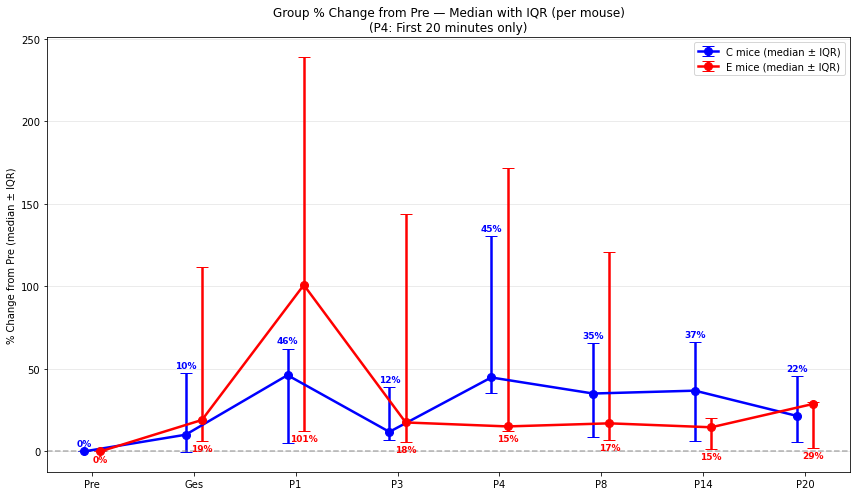


ANALYSIS COMPLETE - All tables generated
P4 data limited to first 20 minutes (400 time windows) per mouse


(<Figure size 864x504 with 1 Axes>,
    Mouse_ID    Type  Pre_median  Pre_mean  Pre_std  Pre_n  Ges_median  \
 0    C6ELS9  C mice       0.126     0.126    0.025    200       0.123   
 1   C7ELS11  C mice       0.106     0.106    0.017    200       0.105   
 2   C2ELS18  C mice       0.122     0.121    0.020    200       0.124   
 3   C5ELS20  C mice       0.068     0.070    0.015    200       0.105   
 4   C7ELS22  C mice       0.116     0.117    0.019    200       0.107   
 5   C1ELS32  C mice       0.027     0.028    0.007    200       0.037   
 6   C5ELS40  C mice       0.028     0.029    0.007    200       0.031   
 7   C6ELS42  C mice       0.033     0.034    0.008    200       0.048   
 8   C7ELS45  C mice       0.030     0.031    0.008    200       0.141   
 9    E2ELS3  E mice       0.128     0.129    0.024    200       0.130   
 10  E1ELS33  E mice       0.024     0.025    0.007    200       0.030   
 11  E3ELS37  E mice       0.140     0.141    0.024    200       0.147   
 1

In [23]:
create_four_visualizations_with_tables(
    filtered_df=filtered_df,
    selected_mice=c_mice_ids + e_mice_ids,
    order=order,
    c_mice_ids=c_mice_ids,
    e_mice_ids=e_mice_ids
)

# Backproject on On/Off-nest with Trimmed data

Loading and Processing Data
Unique labels (onnest_label): [0 1]
All mice in dataset: ['C1_ELS32' 'C2_ELS18' 'C5_ELS20' 'C5_ELS40' 'C6_ELS42' 'C7_ELS11'
 'C7_ELS22' 'C7_ELS45' 'E1_ELS33' 'E2_ELS3' 'E3_ELS37' 'E4_ELS39'
 'E5_ELS41' 'E6_ELS44']

Filtered samples: 136800

Data shape: X=(136800, 108), y=(136800, 1)
Unique mice: ['C1_ELS32' 'C2_ELS18' 'C5_ELS20' 'C5_ELS40' 'C6_ELS42' 'C7_ELS11'
 'C7_ELS22' 'C7_ELS45' 'E1_ELS33' 'E2_ELS3' 'E3_ELS37' 'E4_ELS39'
 'E5_ELS41' 'E6_ELS44']
Unique periods: ['P1' 'P3' 'P8']
Label distribution: 67996 (label=0) vs 68804 (label=1)

Data Distribution by Mouse and Period
Mouse ID        Period   label=0    label=1    Total   
------------------------------------------------------------
C1_ELS32        P1       2681       2119       4800    
C1_ELS32        P3       1882       1718       3600    
C1_ELS32        P8       588        1812       2400    
C2_ELS18        P1       3032       1768       4800    
C2_ELS18        P3       2539       1061       360

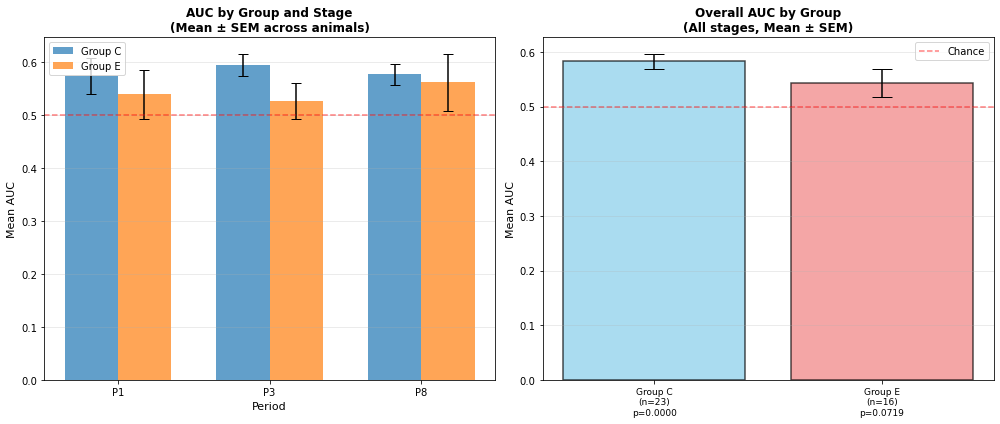

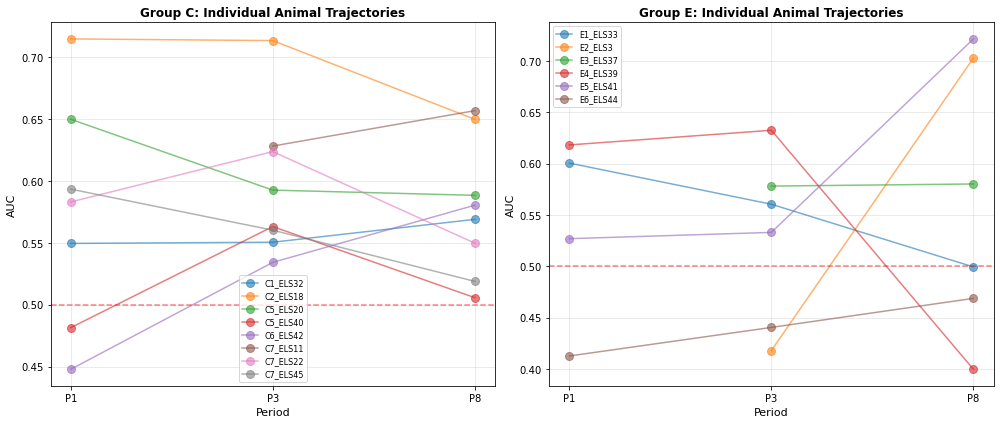


Saving Results
Saved: auc_results_by_animal_stage.csv
Saved: auc_statistics_by_group_stage.csv
Saved: auc_statistics_overall.csv
Saved: wilcoxon_test_results.csv

SUMMARY REPORT

1. By Group and Stage:
group period  mean_auc  std_auc  sem_auc  n_animals
    C     P1    0.5742   0.0923   0.0349          7
    C     P3    0.5957   0.0583   0.0206          8
    C     P8    0.5773   0.0548   0.0194          8
    E     P1    0.5395   0.0933   0.0467          4
    E     P3    0.5271   0.0827   0.0338          6
    E     P8    0.5620   0.1300   0.0531          6

2. Overall by Group (All Stages):
group  mean_auc  std_auc  sem_auc  n_animal_stage
    C    0.5827   0.0668   0.0139              23
    E    0.5433   0.0995   0.0249              16

3. Wilcoxon Signed-Rank Test Results (AUC > 0.5):
group  n_samples  mean_auc  sem_auc  statistic  p_value
    C         23  0.582749 0.013920  10.000000 0.000005
    E         16  0.543286 0.024880  39.000000 0.071930

4. Comparison:
   Group E - 

In [29]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from scipy.stats import wilcoxon

# ========== PART 1: Load and Process Data ==========
print("="*60)
print("Loading and Processing Data")
print("="*60)

TRAINING_DATA_FILE = "/Volumes/rdss_rhultman/datashare/ELS and Maternal Behavior/Spec_Features_8Yes/combined/full_onnest_spec_features_8roi_Jan212026_Trim.pkl"
X_FEATURE_LIST = ["power", "coh_sq_coherence"]
X_FEATURE_WEIGHTS = [1, 1]
Y_FEATURE = "onnest_label"

# Load data
with open(TRAINING_DATA_FILE, "rb") as f:
    train_dict = pickle.load(f)

print(f"Unique labels (onnest_label): {np.unique(train_dict[Y_FEATURE])}")
print(f"All mice in dataset: {np.unique(train_dict['mouse_id'])}")

# Define target mice and periods
periods_to_keep = ['P1', 'P3', 'P8']
c_mouse_ids = ['C7_ELS11', 'C2_ELS18', 'C5_ELS20', 'C7_ELS22', 
               'C1_ELS32', 'C5_ELS40', 'C6_ELS42', 'C7_ELS45']
e_mouse_ids = ['E1_ELS33', 'E2_ELS3', 'E3_ELS37', 'E4_ELS39', 
               'E5_ELS41', 'E6_ELS44']

# Filter data for target mice and periods
all_target_mice = c_mouse_ids + e_mouse_ids
period_mask = np.isin(train_dict['period'], periods_to_keep)
mouse_mask = np.isin(train_dict['mouse_id'], all_target_mice)
combined_mask = period_mask & mouse_mask

print(f"\nFiltered samples: {np.sum(combined_mask)}")

# Extract filtered data
filtered_data = {}
for key in train_dict:
    if isinstance(train_dict[key], np.ndarray) and len(train_dict[key]) == len(train_dict['mouse_id']):
        filtered_data[key] = train_dict[key][combined_mask]

# Prepare features and labels
X = np.hstack([filtered_data[feature]*weight for feature, weight in zip(X_FEATURE_LIST, X_FEATURE_WEIGHTS)])
y = filtered_data[Y_FEATURE].reshape(-1, 1)
mouse_ids = filtered_data['mouse_id']
periods = filtered_data['period']

print(f"\nData shape: X={X.shape}, y={y.shape}")
print(f"Unique mice: {np.unique(mouse_ids)}")
print(f"Unique periods: {np.unique(periods)}")
print(f"Label distribution: {np.sum(y == 0)} (label=0) vs {np.sum(y == 1)} (label=1)")

# Check data distribution by mouse and period
print(f"\n{'='*60}")
print("Data Distribution by Mouse and Period")
print(f"{'='*60}")
print(f"{'Mouse ID':<15} {'Period':<8} {'label=0':<10} {'label=1':<10} {'Total':<8}")
print("-" * 60)

for mouse_id in np.unique(mouse_ids):
    for period in periods_to_keep:
        mask = (mouse_ids == mouse_id) & (periods == period)
        if np.sum(mask) > 0:
            n_label_0 = np.sum((mouse_ids == mouse_id) & (periods == period) & (y.squeeze() == 0))
            n_label_1 = np.sum((mouse_ids == mouse_id) & (periods == period) & (y.squeeze() == 1))
            n_total = np.sum(mask)
            print(f"{mouse_id:<15} {period:<8} {n_label_0:<10} {n_label_1:<10} {n_total:<8}")


# ========== PART 2: Model Prediction ==========
print(f"\n{'='*60}")
print("Model Prediction")
print(f"{'='*60}")

# Ensure model is in eval mode
model.eval()

# Get model predictions
y_pred_proba, s = model.predict_proba(X, include_scores=True)

print(f"Predictions obtained: {len(y_pred_proba)} samples")
print(f"Score range: {s[:, 0].min():.4f} to {s[:, 0].max():.4f}")


# ========== PART 3: Calculate AUC for Each Animal * Stage ==========
print(f"\n{'='*60}")
print("Calculating AUC for Each Animal * Stage")
print(f"{'='*60}")

# Create results storage
auc_results = []

for mouse_id in np.unique(mouse_ids):
    for period in periods_to_keep:
        # Get data for this animal*stage combination
        mask = (mouse_ids == mouse_id) & (periods == period)
        
        if np.sum(mask) == 0:
            continue
            
        y_true_subset = y[mask].squeeze()
        y_pred_subset = y_pred_proba[mask]
        
        # Check if both classes are present
        if len(np.unique(y_true_subset)) < 2:
            print(f"Skipping {mouse_id} - {period}: only one class present (n={np.sum(mask)})")
            continue
        
        # Calculate AUC
        auc = roc_auc_score(y_true_subset, y_pred_subset)
        
        # Determine group (C or E)
        group = 'C' if mouse_id in c_mouse_ids else 'E'
        
        auc_results.append({
            'mouse_id': mouse_id,
            'period': period,
            'group': group,
            'auc': auc,
            'n_samples': np.sum(mask),
            'n_label_0': np.sum(y_true_subset == 0),
            'n_label_1': np.sum(y_true_subset == 1)
        })
        
        print(f"{mouse_id:<15} {period:<8} {group:<5} AUC: {auc:.4f} (n={np.sum(mask)}, 0:{np.sum(y_true_subset == 0)}, 1:{np.sum(y_true_subset == 1)})")

# Convert to DataFrame
auc_df = pd.DataFrame(auc_results)

print(f"\nTotal animal*stage combinations evaluated: {len(auc_df)}")


# ========== PART 4: Calculate Mean ± SEM by Group and Stage ==========
print(f"\n{'='*60}")
print("AUC Statistics by Group and Stage")
print(f"{'='*60}")

# Group by group and period
grouped_stats = []

for group in ['C', 'E']:
    for period in periods_to_keep:
        subset = auc_df[(auc_df['group'] == group) & (auc_df['period'] == period)]
        
        if len(subset) > 0:
            mean_auc = subset['auc'].mean()
            std_auc = subset['auc'].std(ddof=1) if len(subset) > 1 else 0
            sem_auc = std_auc / np.sqrt(len(subset)) if len(subset) > 1 else 0
            
            grouped_stats.append({
                'group': group,
                'period': period,
                'mean_auc': mean_auc,
                'std_auc': std_auc,
                'sem_auc': sem_auc,
                'n_animals': len(subset)
            })
            
            print(f"Group {group} - {period}: Mean AUC = {mean_auc:.4f} ± {sem_auc:.4f} (n={len(subset)} animals)")
        else:
            print(f"Group {group} - {period}: No data")

grouped_stats_df = pd.DataFrame(grouped_stats)


# ========== PART 5: Calculate Overall Mean ± SEM by Group (All Stages) ==========
print(f"\n{'='*60}")
print("Overall AUC Statistics by Group (All Stages)")
print(f"{'='*60}")

overall_stats = []

for group in ['C', 'E']:
    subset = auc_df[auc_df['group'] == group]
    
    if len(subset) > 0:
        mean_auc = subset['auc'].mean()
        std_auc = subset['auc'].std(ddof=1) if len(subset) > 1 else 0
        sem_auc = std_auc / np.sqrt(len(subset)) if len(subset) > 1 else 0
        
        overall_stats.append({
            'group': group,
            'mean_auc': mean_auc,
            'std_auc': std_auc,
            'sem_auc': sem_auc,
            'n_animal_stage': len(subset)
        })
        
        print(f"Group {group} (All stages): Mean AUC = {mean_auc:.4f} ± {sem_auc:.4f} (n={len(subset)} animal*stage combinations)")
    else:
        print(f"Group {group}: No data")

overall_stats_df = pd.DataFrame(overall_stats)


# ========== PART 6: Wilcoxon Signed-Rank Tests by Group ==========
print(f"\n{'='*60}")
print("Wilcoxon Signed-Rank Tests (AUC > 0.5)")
print(f"{'='*60}")

wilcoxon_results = []

for group in ['C', 'E']:
    subset = auc_df[auc_df['group'] == group]
    
    if len(subset) > 0:
        aucs = subset['auc'].values
        differences = aucs - 0.5
        
        print(f"\nGroup {group}:")
        print(f"  N animal*stage combinations: {len(aucs)}")
        print(f"  Mean AUC: {np.mean(aucs):.4f}")
        print(f"  SEM: {np.std(aucs, ddof=1) / np.sqrt(len(aucs)):.4f}")
        print(f"  AUC values: {aucs}")
        
        # Check if all differences are zero
        if np.all(differences == 0):
            print(f"  ⚠️  All AUCs equal to 0.5, cannot perform test")
            wilcoxon_results.append({
                'group': group,
                'n_samples': len(aucs),
                'mean_auc': np.mean(aucs),
                'sem_auc': np.std(aucs, ddof=1) / np.sqrt(len(aucs)),
                'statistic': np.nan,
                'p_value': np.nan
            })
        else:
            # Perform Wilcoxon signed-rank test
            try:
                statistic, p_value_two_sided = wilcoxon(differences, alternative='two-sided')
                
                # Convert to one-sided test (greater)
                if np.median(differences) > 0:
                    p_value_one_sided = p_value_two_sided / 2
                else:
                    p_value_one_sided = 1 - p_value_two_sided / 2
                
                print(f"  Wilcoxon test results:")
                print(f"    Statistic: {statistic:.4f}")
                print(f"    One-sided p-value (AUC > 0.5): {p_value_one_sided:.6f}")
                
                if p_value_one_sided < 0.001:
                    print(f"    Significance: *** (p < 0.001)")
                elif p_value_one_sided < 0.01:
                    print(f"    Significance: ** (p < 0.01)")
                elif p_value_one_sided < 0.05:
                    print(f"    Significance: * (p < 0.05)")
                else:
                    print(f"    Significance: n.s. (p >= 0.05)")
                
                wilcoxon_results.append({
                    'group': group,
                    'n_samples': len(aucs),
                    'mean_auc': np.mean(aucs),
                    'sem_auc': np.std(aucs, ddof=1) / np.sqrt(len(aucs)),
                    'statistic': statistic,
                    'p_value': p_value_one_sided
                })
                
            except Exception as e:
                print(f"  ⚠️  Error performing Wilcoxon test: {e}")
                wilcoxon_results.append({
                    'group': group,
                    'n_samples': len(aucs),
                    'mean_auc': np.mean(aucs),
                    'sem_auc': np.std(aucs, ddof=1) / np.sqrt(len(aucs)),
                    'statistic': np.nan,
                    'p_value': np.nan
                })
    else:
        print(f"\nGroup {group}: No data for testing")

wilcoxon_df = pd.DataFrame(wilcoxon_results)

if len(wilcoxon_df) > 0:
    print(f"\n{'='*60}")
    print("Wilcoxon Test Summary")
    print(f"{'='*60}")
    print(wilcoxon_df.to_string(index=False, float_format='%.6f'))


# ========== PART 7: Visualization ==========
print(f"\n{'='*60}")
print("Creating Visualizations")
print(f"{'='*60}")

# Figure 1: AUC by Group and Stage
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Bar plot with error bars by group and stage
x_positions = {'P1': 0, 'P3': 1, 'P8': 2}
width = 0.35

for i, group in enumerate(['C', 'E']):
    group_data = grouped_stats_df[grouped_stats_df['group'] == group]
    
    x = [x_positions[period] + i*width for period in group_data['period']]
    y = group_data['mean_auc'].values
    yerr = group_data['sem_auc'].values
    
    axes[0].bar(x, y, width, yerr=yerr, label=f'Group {group}', 
                capsize=5, alpha=0.7)

axes[0].set_xlabel('Period', fontsize=11)
axes[0].set_ylabel('Mean AUC', fontsize=11)
axes[0].set_title('AUC by Group and Stage\n(Mean ± SEM across animals)', fontsize=12, fontweight='bold')
axes[0].set_xticks([r + width/2 for r in range(3)])
axes[0].set_xticklabels(periods_to_keep)
axes[0].legend()
axes[0].grid(alpha=0.3, axis='y')
axes[0].axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='Chance')

# Plot 2: Overall comparison with p-values
overall_x = [0, 1]
overall_y = overall_stats_df['mean_auc'].values
overall_yerr = overall_stats_df['sem_auc'].values

# Add p-value annotations if available
if len(wilcoxon_df) > 0:
    p_values = wilcoxon_df['p_value'].values
    overall_labels = [f"Group {g}\n(n={n})\np={p:.4f}" if not np.isnan(p) else f"Group {g}\n(n={n})" 
                     for g, n, p in zip(overall_stats_df['group'], overall_stats_df['n_animal_stage'], p_values)]
else:
    overall_labels = [f"Group {g}\n(n={n})" for g, n in zip(overall_stats_df['group'], overall_stats_df['n_animal_stage'])]

axes[1].bar(overall_x, overall_y, yerr=overall_yerr, capsize=10, 
            color=['skyblue', 'lightcoral'], alpha=0.7, edgecolor='black', linewidth=1.5)
axes[1].set_ylabel('Mean AUC', fontsize=11)
axes[1].set_title('Overall AUC by Group\n(All stages, Mean ± SEM)', fontsize=12, fontweight='bold')
axes[1].set_xticks(overall_x)
axes[1].set_xticklabels(overall_labels, fontsize=9)
axes[1].grid(alpha=0.3, axis='y')
axes[1].axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='Chance')
axes[1].legend()

plt.tight_layout()
plt.show()

# Figure 2: Individual animal*stage AUC values
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Scatter plot with lines for each animal
for group, ax in zip(['C', 'E'], axes):
    group_data = auc_df[auc_df['group'] == group]
    
    for mouse_id in group_data['mouse_id'].unique():
        mouse_data = group_data[group_data['mouse_id'] == mouse_id].sort_values('period', 
                                                                                 key=lambda x: x.map({'P1': 0, 'P3': 1, 'P8': 2}))
        
        x = [x_positions[p] for p in mouse_data['period']]
        y = mouse_data['auc'].values
        
        ax.plot(x, y, 'o-', alpha=0.6, label=mouse_id, markersize=8)
    
    ax.set_xlabel('Period', fontsize=11)
    ax.set_ylabel('AUC', fontsize=11)
    ax.set_title(f'Group {group}: Individual Animal Trajectories', fontsize=12, fontweight='bold')
    ax.set_xticks(list(x_positions.values()))
    ax.set_xticklabels(list(x_positions.keys()))
    ax.grid(alpha=0.3)
    ax.axhline(y=0.5, color='red', linestyle='--', alpha=0.5)
    ax.legend(fontsize=8, loc='best')

plt.tight_layout()
plt.show()


# ========== PART 8: Save Results ==========
print(f"\n{'='*60}")
print("Saving Results")
print(f"{'='*60}")

# Save detailed AUC results
auc_df.to_csv('auc_results_by_animal_stage.csv', index=False)
print("Saved: auc_results_by_animal_stage.csv")

# Save grouped statistics
grouped_stats_df.to_csv('auc_statistics_by_group_stage.csv', index=False)
print("Saved: auc_statistics_by_group_stage.csv")

# Save overall statistics
overall_stats_df.to_csv('auc_statistics_overall.csv', index=False)
print("Saved: auc_statistics_overall.csv")

# Save Wilcoxon test results
if len(wilcoxon_df) > 0:
    wilcoxon_df.to_csv('wilcoxon_test_results.csv', index=False)
    print("Saved: wilcoxon_test_results.csv")

# Create summary report
print(f"\n{'='*60}")
print("SUMMARY REPORT")
print(f"{'='*60}")

print("\n1. By Group and Stage:")
print(grouped_stats_df.to_string(index=False))

print("\n2. Overall by Group (All Stages):")
print(overall_stats_df.to_string(index=False))

print("\n3. Wilcoxon Signed-Rank Test Results (AUC > 0.5):")
if len(wilcoxon_df) > 0:
    print(wilcoxon_df.to_string(index=False, float_format='%.6f'))
else:
    print("No Wilcoxon test results available")

print(f"\n4. Comparison:")
if len(overall_stats_df) == 2:
    c_auc = overall_stats_df[overall_stats_df['group'] == 'C']['mean_auc'].values[0]
    e_auc = overall_stats_df[overall_stats_df['group'] == 'E']['mean_auc'].values[0]
    print(f"   Group E - Group C difference: {e_auc - c_auc:.4f}")

print(f"\n{'='*60}")
print("Analysis Complete!")
print(f"{'='*60}")

# Backproject on Onnest Licking vs Onnest NonLicking with Trimmed data

Loading and Processing Data - Licking Analysis

Creating Licking dataset...
Condition: onnest_raw=1
Label: licking=1 (Licking) vs licking=0 (Non-licking during onnest)

Data shape: X=(23159, 108), y=(23159, 1)
Unique mice: ['C1ELS32' 'C2ELS18' 'C5ELS20' 'C5ELS40' 'C6ELS42' 'C7ELS11' 'C7ELS22'
 'C7ELS45' 'E1ELS33' 'E2ELS3' 'E3ELS37' 'E4ELS39' 'E5ELS41' 'E6ELS44']
Label distribution: 22464 (y=0, Non-licking) vs 695 (y=1, Licking)

Data Distribution by Mouse
Mouse ID        Group    y=0 (Non-lick)   y=1 (Licking)    Total   
---------------------------------------------------------------------------
C1ELS32         C        1633             85               1718    
C2ELS18         C        1018             43               1061    
C5ELS20         C        2140             45               2185    
C5ELS40         C        2032             137              2169    
C6ELS42         C        1390             75               1465    
C7ELS11         C        1308             28            

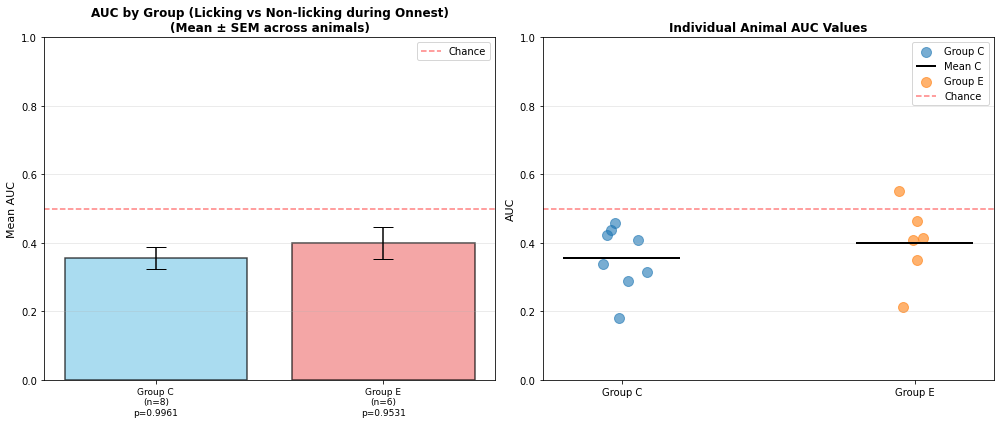


Saving Results
Saved: licking_auc_results_by_animal.csv
Saved: licking_auc_statistics_by_group.csv
Saved: licking_wilcoxon_test_results.csv

SUMMARY REPORT - Licking Analysis
Task: Licking (1) vs Non-licking (0) during Onnest

1. By Group:
group  mean_auc  std_auc  sem_auc  n_animals
    C    0.3564   0.0936   0.0331          8
    E    0.4000   0.1135   0.0463          6

2. Wilcoxon Signed-Rank Test Results (AUC > 0.5):
group  n_samples  mean_auc  sem_auc  statistic  p_value
    C          8  0.356421 0.033092   0.000000 0.996094
    E          6  0.400003 0.046343   2.000000 0.953125

3. Group Comparison:
   Group E - Group C difference: 0.0436

Analysis Complete!


In [30]:
import pickle
import numpy as np
import pandas as pd
import re
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import wilcoxon

# ========== PART 1: Load and Process Data ==========
print("="*60)
print("Loading and Processing Data - Licking Analysis")
print("="*60)

# Load data
FULL_DATA_FILE = "/Volumes/rdss_rhultman/datashare/ELS and Maternal Behavior/Spec_Features_All/Combined/P3_onnest_lick/full_onnest_lick_Trim.pkl"
with open(FULL_DATA_FILE, "rb") as f:
    full_dict = pickle.load(f)

def clean_mouse_id(mouse_id):
    cleaned = mouse_id.replace('Mouse', '')
    cleaned = re.sub(r'F\d+', '', cleaned)
    return cleaned

# Define target mouse_ids
target_mouse_ids = ['C7ELS11', 'C2ELS18', 'C5ELS20', 'C7ELS22', 
                    'C1ELS32', 'C5ELS40', 'C6ELS42', 'C7ELS45']
test_e_mouse_ids = ['E2ELS3', 'E1ELS33', 'E3ELS37', 'E4ELS39', 'E5ELS41', 'E6ELS44']
all_target_mouse_ids = target_mouse_ids + test_e_mouse_ids

def create_dataset(full_dict, condition, target_mouse_ids, y_feature):
    """Create filtered dataset and split into C/E groups"""
    # Filter by condition
    selected_indices = np.where(condition)[0]
    filtered_dict = {key: (value[selected_indices] if isinstance(value, np.ndarray) and 
                          value.shape[0] == len(full_dict['onnest_raw']) else value) 
                     for key, value in full_dict.items()}
    
    # Filter by mouse_id
    cleaned_mouse_ids = np.array([clean_mouse_id(mid) for mid in filtered_dict['mouse_id']])
    mouse_condition = np.isin(cleaned_mouse_ids, target_mouse_ids)
    mouse_indices = np.where(mouse_condition)[0]
    
    final_dict = {key: (value[mouse_indices] if isinstance(value, np.ndarray) and 
                       value.shape[0] == len(filtered_dict['onnest_raw']) else value) 
                  for key, value in filtered_dict.items()}
    
    # Build features and labels
    X = np.hstack([final_dict["power"], final_dict["coh_sq_coherence"]])
    y = final_dict[y_feature].reshape(-1, 1)
    y_sampling = OrdinalEncoder().fit_transform(final_dict["mouse_id"].reshape(-1, 1))
    y_intercept_mask = OneHotEncoder().fit_transform(final_dict["mouse_id"].reshape(-1, 1)).todense()
    mouse_ids = np.array([clean_mouse_id(mid) for mid in final_dict['mouse_id']])
    
    # Split by C/E
    c_mask = np.array([mid.startswith('C') for mid in mouse_ids])
    e_mask = np.array([mid.startswith('E') for mid in mouse_ids])
    
    return {
        'C': {'X': X[c_mask], 'y': y[c_mask], 'mouse_ids': mouse_ids[c_mask], 
              'y_sampling': y_sampling[c_mask], 'y_intercept_mask': y_intercept_mask[c_mask]},
        'E': {'X': X[e_mask], 'y': y[e_mask], 'mouse_ids': mouse_ids[e_mask],
              'y_sampling': y_sampling[e_mask], 'y_intercept_mask': y_intercept_mask[e_mask]}
    }

print("\nCreating Licking dataset...")
print("Condition: onnest_raw=1")
print("Label: licking=1 (Licking) vs licking=0 (Non-licking during onnest)")

# Create Licking dataset: onnest=1, label=licking
licking_data = create_dataset(full_dict, 
                             (full_dict['onnest_raw'] == 1), 
                             all_target_mouse_ids, 
                             'licking')

# Extract datasets
X_Licking_C = licking_data['C']['X']
y_Licking_C = licking_data['C']['y']
mouse_ids_Licking_C = licking_data['C']['mouse_ids']

X_Licking_E = licking_data['E']['X']
y_Licking_E = licking_data['E']['y']
mouse_ids_Licking_E = licking_data['E']['mouse_ids']

# Combine C and E for analysis
X = np.vstack([X_Licking_C, X_Licking_E])
y = np.vstack([y_Licking_C, y_Licking_E])
mouse_ids = np.concatenate([mouse_ids_Licking_C, mouse_ids_Licking_E])

c_mouse_ids = target_mouse_ids
e_mouse_ids = test_e_mouse_ids

print(f"\nData shape: X={X.shape}, y={y.shape}")
print(f"Unique mice: {np.unique(mouse_ids)}")
print(f"Label distribution: {np.sum(y == 0)} (y=0, Non-licking) vs {np.sum(y == 1)} (y=1, Licking)")

# Print dataset statistics
print(f"\n{'='*60}")
print("Data Distribution by Mouse")
print(f"{'='*60}")
print(f"{'Mouse ID':<15} {'Group':<8} {'y=0 (Non-lick)':<16} {'y=1 (Licking)':<16} {'Total':<8}")
print("-" * 75)

for mouse_id in np.unique(mouse_ids):
    group = 'C' if mouse_id in c_mouse_ids else 'E'
    n_label_0 = np.sum((mouse_ids == mouse_id) & (y.squeeze() == 0))
    n_label_1 = np.sum((mouse_ids == mouse_id) & (y.squeeze() == 1))
    n_total = np.sum(mouse_ids == mouse_id)
    print(f"{mouse_id:<15} {group:<8} {n_label_0:<16} {n_label_1:<16} {n_total:<8}")


# ========== PART 2: Model Prediction ==========
print(f"\n{'='*60}")
print("Model Prediction")
print(f"{'='*60}")

# Ensure model is in eval mode
model.eval()

# Get model predictions
y_pred_proba, s = model.predict_proba(X, include_scores=True)

print(f"Predictions obtained: {len(y_pred_proba)} samples")
print(f"Score range: {s[:, 0].min():.4f} to {s[:, 0].max():.4f}")


# ========== PART 3: Calculate AUC for Each Animal ==========
print(f"\n{'='*60}")
print("Calculating AUC for Each Animal")
print(f"{'='*60}")

# Create results storage
auc_results = []

for mouse_id in np.unique(mouse_ids):
    # Get data for this animal
    mask = (mouse_ids == mouse_id)
    
    if np.sum(mask) == 0:
        continue
        
    y_true_subset = y[mask].squeeze()
    y_pred_subset = y_pred_proba[mask]
    
    # Check if both classes are present
    if len(np.unique(y_true_subset)) < 2:
        print(f"Skipping {mouse_id}: only one class present (n={np.sum(mask)})")
        continue
    
    # Calculate AUC
    auc = roc_auc_score(y_true_subset, y_pred_subset)
    
    # Determine group (C or E)
    group = 'C' if mouse_id in c_mouse_ids else 'E'
    
    auc_results.append({
        'mouse_id': mouse_id,
        'group': group,
        'auc': auc,
        'n_samples': np.sum(mask),
        'n_label_0': np.sum(y_true_subset == 0),
        'n_label_1': np.sum(y_true_subset == 1)
    })
    
    print(f"{mouse_id:<15} {group:<5} AUC: {auc:.4f} (n={np.sum(mask)}, 0:{np.sum(y_true_subset == 0)}, 1:{np.sum(y_true_subset == 1)})")

# Convert to DataFrame
auc_df = pd.DataFrame(auc_results)

print(f"\nTotal animals evaluated: {len(auc_df)}")


# ========== PART 4: Calculate Mean ± SEM by Group ==========
print(f"\n{'='*60}")
print("AUC Statistics by Group")
print(f"{'='*60}")

# Group by group
grouped_stats = []

for group in ['C', 'E']:
    subset = auc_df[auc_df['group'] == group]
    
    if len(subset) > 0:
        mean_auc = subset['auc'].mean()
        std_auc = subset['auc'].std(ddof=1) if len(subset) > 1 else 0
        sem_auc = std_auc / np.sqrt(len(subset)) if len(subset) > 1 else 0
        
        grouped_stats.append({
            'group': group,
            'mean_auc': mean_auc,
            'std_auc': std_auc,
            'sem_auc': sem_auc,
            'n_animals': len(subset)
        })
        
        print(f"Group {group}: Mean AUC = {mean_auc:.4f} ± {sem_auc:.4f} (n={len(subset)} animals)")
    else:
        print(f"Group {group}: No data")

grouped_stats_df = pd.DataFrame(grouped_stats)


# ========== PART 5: Wilcoxon Signed-Rank Tests by Group ==========
print(f"\n{'='*60}")
print("Wilcoxon Signed-Rank Tests (AUC > 0.5)")
print(f"{'='*60}")

wilcoxon_results = []

for group in ['C', 'E']:
    subset = auc_df[auc_df['group'] == group]
    
    if len(subset) > 0:
        aucs = subset['auc'].values
        differences = aucs - 0.5
        
        print(f"\nGroup {group}:")
        print(f"  N animals: {len(aucs)}")
        print(f"  Mean AUC: {np.mean(aucs):.4f}")
        print(f"  SEM: {np.std(aucs, ddof=1) / np.sqrt(len(aucs)):.4f}")
        print(f"  AUC values: {aucs}")
        
        # Check if all differences are zero
        if np.all(differences == 0):
            print(f"  ⚠️  All AUCs equal to 0.5, cannot perform test")
            wilcoxon_results.append({
                'group': group,
                'n_samples': len(aucs),
                'mean_auc': np.mean(aucs),
                'sem_auc': np.std(aucs, ddof=1) / np.sqrt(len(aucs)),
                'statistic': np.nan,
                'p_value': np.nan
            })
        else:
            # Perform Wilcoxon signed-rank test
            try:
                statistic, p_value_two_sided = wilcoxon(differences, alternative='two-sided')
                
                # Convert to one-sided test (greater)
                if np.median(differences) > 0:
                    p_value_one_sided = p_value_two_sided / 2
                else:
                    p_value_one_sided = 1 - p_value_two_sided / 2
                
                print(f"  Wilcoxon test results:")
                print(f"    Statistic: {statistic:.4f}")
                print(f"    One-sided p-value (AUC > 0.5): {p_value_one_sided:.6f}")
                
                if p_value_one_sided < 0.001:
                    print(f"    Significance: *** (p < 0.001)")
                elif p_value_one_sided < 0.01:
                    print(f"    Significance: ** (p < 0.01)")
                elif p_value_one_sided < 0.05:
                    print(f"    Significance: * (p < 0.05)")
                else:
                    print(f"    Significance: n.s. (p >= 0.05)")
                
                wilcoxon_results.append({
                    'group': group,
                    'n_samples': len(aucs),
                    'mean_auc': np.mean(aucs),
                    'sem_auc': np.std(aucs, ddof=1) / np.sqrt(len(aucs)),
                    'statistic': statistic,
                    'p_value': p_value_one_sided
                })
                
            except Exception as e:
                print(f"  ⚠️  Error performing Wilcoxon test: {e}")
                wilcoxon_results.append({
                    'group': group,
                    'n_samples': len(aucs),
                    'mean_auc': np.mean(aucs),
                    'sem_auc': np.std(aucs, ddof=1) / np.sqrt(len(aucs)),
                    'statistic': np.nan,
                    'p_value': np.nan
                })
    else:
        print(f"\nGroup {group}: No data for testing")

wilcoxon_df = pd.DataFrame(wilcoxon_results)

if len(wilcoxon_df) > 0:
    print(f"\n{'='*60}")
    print("Wilcoxon Test Summary")
    print(f"{'='*60}")
    print(wilcoxon_df.to_string(index=False, float_format='%.6f'))


# ========== PART 6: Visualization ==========
print(f"\n{'='*60}")
print("Creating Visualizations")
print(f"{'='*60}")

# Figure 1: AUC by Group with p-values
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Bar plot with error bars by group
group_x = [0, 1]
group_y = grouped_stats_df['mean_auc'].values
group_yerr = grouped_stats_df['sem_auc'].values

# Add p-value annotations if available
if len(wilcoxon_df) > 0:
    p_values = wilcoxon_df['p_value'].values
    group_labels = [f"Group {g}\n(n={n})\np={p:.4f}" if not np.isnan(p) else f"Group {g}\n(n={n})" 
                   for g, n, p in zip(grouped_stats_df['group'], grouped_stats_df['n_animals'], p_values)]
else:
    group_labels = [f"Group {g}\n(n={n})" for g, n in zip(grouped_stats_df['group'], grouped_stats_df['n_animals'])]

axes[0].bar(group_x, group_y, yerr=group_yerr, capsize=10, 
            color=['skyblue', 'lightcoral'], alpha=0.7, edgecolor='black', linewidth=1.5)
axes[0].set_ylabel('Mean AUC', fontsize=11)
axes[0].set_title('AUC by Group (Licking vs Non-licking during Onnest)\n(Mean ± SEM across animals)', 
                  fontsize=12, fontweight='bold')
axes[0].set_xticks(group_x)
axes[0].set_xticklabels(group_labels, fontsize=9)
axes[0].grid(alpha=0.3, axis='y')
axes[0].axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='Chance')
axes[0].legend()
axes[0].set_ylim([0, 1])

# Plot 2: Individual animal AUC values
for i, group in enumerate(['C', 'E']):
    group_data = auc_df[auc_df['group'] == group]
    
    x = np.ones(len(group_data)) * i + np.random.normal(0, 0.05, len(group_data))
    y = group_data['auc'].values
    
    axes[1].scatter(x, y, alpha=0.6, s=100, label=f'Group {group}')
    
    # Add mean line
    axes[1].hlines(y=group_y[i], xmin=i-0.2, xmax=i+0.2, 
                   colors='black', linewidth=2, label=f'Mean {group}' if i == 0 else '')

axes[1].set_ylabel('AUC', fontsize=11)
axes[1].set_title('Individual Animal AUC Values', fontsize=12, fontweight='bold')
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['Group C', 'Group E'])
axes[1].grid(alpha=0.3, axis='y')
axes[1].axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='Chance')
axes[1].legend()
axes[1].set_ylim([0, 1])

plt.tight_layout()
plt.show()


# ========== PART 7: Save Results ==========
print(f"\n{'='*60}")
print("Saving Results")
print(f"{'='*60}")

# Save detailed AUC results
auc_df.to_csv('licking_auc_results_by_animal.csv', index=False)
print("Saved: licking_auc_results_by_animal.csv")

# Save grouped statistics
grouped_stats_df.to_csv('licking_auc_statistics_by_group.csv', index=False)
print("Saved: licking_auc_statistics_by_group.csv")

# Save Wilcoxon test results
if len(wilcoxon_df) > 0:
    wilcoxon_df.to_csv('licking_wilcoxon_test_results.csv', index=False)
    print("Saved: licking_wilcoxon_test_results.csv")

# Create summary report
print(f"\n{'='*60}")
print("SUMMARY REPORT - Licking Analysis")
print(f"{'='*60}")
print("Task: Licking (1) vs Non-licking (0) during Onnest")

print("\n1. By Group:")
print(grouped_stats_df.to_string(index=False))

print("\n2. Wilcoxon Signed-Rank Test Results (AUC > 0.5):")
if len(wilcoxon_df) > 0:
    print(wilcoxon_df.to_string(index=False, float_format='%.6f'))
else:
    print("No Wilcoxon test results available")

print(f"\n3. Group Comparison:")
if len(grouped_stats_df) == 2:
    c_auc = grouped_stats_df[grouped_stats_df['group'] == 'C']['mean_auc'].values[0]
    e_auc = grouped_stats_df[grouped_stats_df['group'] == 'E']['mean_auc'].values[0]
    print(f"   Group E - Group C difference: {e_auc - c_auc:.4f}")

print(f"\n{'='*60}")
print("Analysis Complete!")
print(f"{'='*60}")

# Backproject on Onnest Licking vs Grooming (doesn't matter trimmed or not since this is onnest licking vs onnest grooming)

Loading and Processing Data

=== PAIR 1: Onnest with Licking or Selfgroom ===
Condition: onnest_raw=1 AND (licking=1 OR selfgroom=1)
Label: licking=1 -> y=1, selfgroom=1 -> y=0

Data shape: X=(1751, 108), y=(1751, 1)
Unique mice: ['C1ELS32' 'C2ELS18' 'C5ELS20' 'C5ELS40' 'C6ELS42' 'C7ELS22' 'E1ELS33'
 'E3ELS37' 'E4ELS39' 'E5ELS41' 'E6ELS44']
Label distribution: 1134 (y=0, Selfgroom) vs 617 (y=1, Licking)

Data Distribution by Mouse
Mouse ID        y=0 (Selfgroom)    y=1 (Licking)    Total   
------------------------------------------------------------
C1ELS32         140                85               225     
C2ELS18         41                 43               84      
C5ELS20         54                 45               99      
C5ELS40         26                 137              163     
C6ELS42         25                 75               100     
C7ELS22         14                 23               37      
E1ELS33         315                142              457     
E3ELS37         

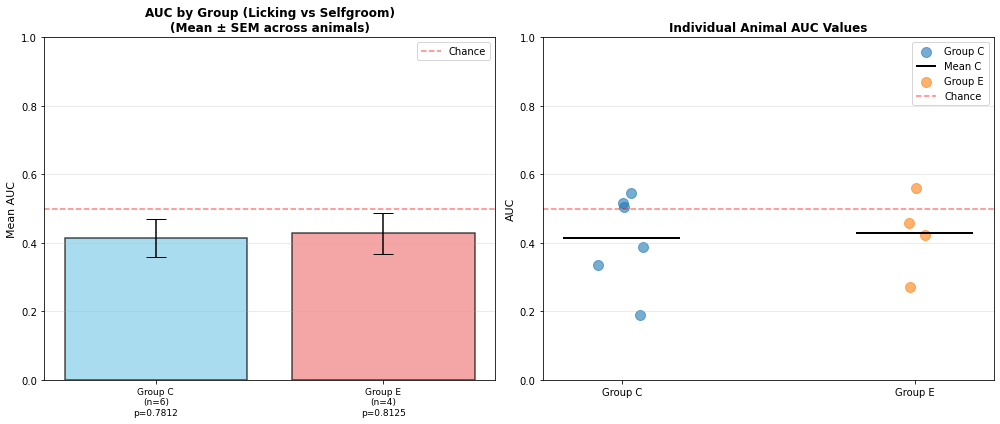


Saving Results
Saved: pair1_auc_results_by_animal.csv
Saved: pair1_auc_statistics_by_group.csv
Saved: pair1_wilcoxon_test_results.csv

SUMMARY REPORT - Pair 1 (Licking vs Selfgroom)

1. By Group:
group  mean_auc  std_auc  sem_auc  n_animals
    C    0.4137   0.1366   0.0557          6
    E    0.4286   0.1194   0.0597          4

2. Wilcoxon Signed-Rank Test Results (AUC > 0.5):
group  n_samples  mean_auc  sem_auc  statistic  p_value
    C          6  0.413713 0.055748   6.000000 0.781250
    E          4  0.428600 0.059711   2.000000 0.812500

3. Group Comparison:
   Group E - Group C difference: 0.0149

Analysis Complete!


In [31]:
import pickle
import numpy as np
import pandas as pd
import re
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import wilcoxon

# ========== PART 1: Load and Process Data ==========
print("="*60)
print("Loading and Processing Data")
print("="*60)

FULL_DATA_FILE = "/Volumes/rdss_rhultman/datashare/ELS and Maternal Behavior/Spec_Features_All/Combined/P3_onnest_lick_selfgroom_nurse/full_all_behaviors_no_nursing_field_Trim.pkl"

with open(FULL_DATA_FILE, "rb") as f:
    full_dict = pickle.load(f)

def clean_mouse_id(mouse_id):
    """Remove 'Mouse' prefix and 'F#' pattern from mouse_id"""
    cleaned = mouse_id.replace('Mouse', '')
    cleaned = re.sub(r'F\d+', '', cleaned)
    return cleaned

# Define target mouse_ids
target_mouse_ids = ['C2ELS18', 'C5ELS20', 'C7ELS22', 
                    'C1ELS32', 'C5ELS40', 'C6ELS42']
test_e_mouse_ids = ['E1ELS33', 'E3ELS37', 'E4ELS39', 'E5ELS41', 'E6ELS44']
all_target_mouse_ids = target_mouse_ids + test_e_mouse_ids

# ========== PAIR 1: Onnest with Licking or Selfgroom ==========
# Condition: onnest_raw=1 AND (licking=1 OR selfgroom=1)
pair1_condition = (full_dict['onnest_raw'] == 1) & \
                  ((full_dict['licking'] == 1) | (full_dict['selfgroom'] == 1))

# y label: licking=1 -> y=1, selfgroom=1 -> y=0
pair1_y = np.where(full_dict['licking'] == 1, 1, 0)

print("\n=== PAIR 1: Onnest with Licking or Selfgroom ===")
print("Condition: onnest_raw=1 AND (licking=1 OR selfgroom=1)")
print("Label: licking=1 -> y=1, selfgroom=1 -> y=0")

# Filter by condition
selected_indices = np.where(pair1_condition)[0]
filtered_dict = {key: (value[selected_indices] if isinstance(value, np.ndarray) and 
                      value.shape[0] == len(full_dict['onnest_raw']) else value) 
                 for key, value in full_dict.items()}
y_filtered = pair1_y[selected_indices]

# Filter by mouse_id
cleaned_mouse_ids = np.array([clean_mouse_id(mid) for mid in filtered_dict['mouse_id']])
mouse_condition = np.isin(cleaned_mouse_ids, all_target_mouse_ids)
mouse_indices = np.where(mouse_condition)[0]

final_dict = {key: (value[mouse_indices] if isinstance(value, np.ndarray) and 
                   value.shape[0] == len(filtered_dict['onnest_raw']) else value) 
              for key, value in filtered_dict.items()}
y_final = y_filtered[mouse_indices]

# Build features and labels
X = np.hstack([final_dict["power"], final_dict["coh_sq_coherence"]])
y = y_final.reshape(-1, 1)
mouse_ids = np.array([clean_mouse_id(mid) for mid in final_dict['mouse_id']])

# Note: Assuming period information is available in the data
# If not, you may need to modify this based on your data structure
periods = final_dict.get('period', np.array(['P3'] * len(mouse_ids)))  # Default to P3 if not available

print(f"\nData shape: X={X.shape}, y={y.shape}")
print(f"Unique mice: {np.unique(mouse_ids)}")
print(f"Label distribution: {np.sum(y == 0)} (y=0, Selfgroom) vs {np.sum(y == 1)} (y=1, Licking)")

# Check data distribution by mouse
print(f"\n{'='*60}")
print("Data Distribution by Mouse")
print(f"{'='*60}")
print(f"{'Mouse ID':<15} {'y=0 (Selfgroom)':<18} {'y=1 (Licking)':<16} {'Total':<8}")
print("-" * 60)

c_mouse_ids = [mid for mid in all_target_mouse_ids if mid.startswith('C')]
e_mouse_ids = [mid for mid in all_target_mouse_ids if mid.startswith('E')]

for mouse_id in np.unique(mouse_ids):
    n_label_0 = np.sum((mouse_ids == mouse_id) & (y.squeeze() == 0))
    n_label_1 = np.sum((mouse_ids == mouse_id) & (y.squeeze() == 1))
    n_total = np.sum(mouse_ids == mouse_id)
    print(f"{mouse_id:<15} {n_label_0:<18} {n_label_1:<16} {n_total:<8}")


# ========== PART 2: Model Prediction ==========
print(f"\n{'='*60}")
print("Model Prediction")
print(f"{'='*60}")

# Ensure model is in eval mode
model.eval()

# Get model predictions
y_pred_proba, s = model.predict_proba(X, include_scores=True)

print(f"Predictions obtained: {len(y_pred_proba)} samples")
print(f"Score range: {s[:, 0].min():.4f} to {s[:, 0].max():.4f}")


# ========== PART 3: Calculate AUC for Each Animal ==========
print(f"\n{'='*60}")
print("Calculating AUC for Each Animal")
print(f"{'='*60}")

# Create results storage
auc_results = []

for mouse_id in np.unique(mouse_ids):
    # Get data for this animal
    mask = (mouse_ids == mouse_id)
    
    if np.sum(mask) == 0:
        continue
        
    y_true_subset = y[mask].squeeze()
    y_pred_subset = y_pred_proba[mask]
    
    # Check if both classes are present
    if len(np.unique(y_true_subset)) < 2:
        print(f"Skipping {mouse_id}: only one class present (n={np.sum(mask)})")
        continue
    
    # Calculate AUC
    auc = roc_auc_score(y_true_subset, y_pred_subset)
    
    # Determine group (C or E)
    group = 'C' if mouse_id in c_mouse_ids else 'E'
    
    auc_results.append({
        'mouse_id': mouse_id,
        'group': group,
        'auc': auc,
        'n_samples': np.sum(mask),
        'n_label_0': np.sum(y_true_subset == 0),
        'n_label_1': np.sum(y_true_subset == 1)
    })
    
    print(f"{mouse_id:<15} {group:<5} AUC: {auc:.4f} (n={np.sum(mask)}, 0:{np.sum(y_true_subset == 0)}, 1:{np.sum(y_true_subset == 1)})")

# Convert to DataFrame
auc_df = pd.DataFrame(auc_results)

print(f"\nTotal animals evaluated: {len(auc_df)}")


# ========== PART 4: Calculate Mean ± SEM by Group ==========
print(f"\n{'='*60}")
print("AUC Statistics by Group")
print(f"{'='*60}")

# Group by group
grouped_stats = []

for group in ['C', 'E']:
    subset = auc_df[auc_df['group'] == group]
    
    if len(subset) > 0:
        mean_auc = subset['auc'].mean()
        std_auc = subset['auc'].std(ddof=1) if len(subset) > 1 else 0
        sem_auc = std_auc / np.sqrt(len(subset)) if len(subset) > 1 else 0
        
        grouped_stats.append({
            'group': group,
            'mean_auc': mean_auc,
            'std_auc': std_auc,
            'sem_auc': sem_auc,
            'n_animals': len(subset)
        })
        
        print(f"Group {group}: Mean AUC = {mean_auc:.4f} ± {sem_auc:.4f} (n={len(subset)} animals)")
    else:
        print(f"Group {group}: No data")

grouped_stats_df = pd.DataFrame(grouped_stats)


# ========== PART 5: Wilcoxon Signed-Rank Tests by Group ==========
print(f"\n{'='*60}")
print("Wilcoxon Signed-Rank Tests (AUC > 0.5)")
print(f"{'='*60}")

wilcoxon_results = []

for group in ['C', 'E']:
    subset = auc_df[auc_df['group'] == group]
    
    if len(subset) > 0:
        aucs = subset['auc'].values
        differences = aucs - 0.5
        
        print(f"\nGroup {group}:")
        print(f"  N animals: {len(aucs)}")
        print(f"  Mean AUC: {np.mean(aucs):.4f}")
        print(f"  SEM: {np.std(aucs, ddof=1) / np.sqrt(len(aucs)):.4f}")
        print(f"  AUC values: {aucs}")
        
        # Check if all differences are zero
        if np.all(differences == 0):
            print(f"  ⚠️  All AUCs equal to 0.5, cannot perform test")
            wilcoxon_results.append({
                'group': group,
                'n_samples': len(aucs),
                'mean_auc': np.mean(aucs),
                'sem_auc': np.std(aucs, ddof=1) / np.sqrt(len(aucs)),
                'statistic': np.nan,
                'p_value': np.nan
            })
        else:
            # Perform Wilcoxon signed-rank test
            try:
                statistic, p_value_two_sided = wilcoxon(differences, alternative='two-sided')
                
                # Convert to one-sided test (greater)
                if np.median(differences) > 0:
                    p_value_one_sided = p_value_two_sided / 2
                else:
                    p_value_one_sided = 1 - p_value_two_sided / 2
                
                print(f"  Wilcoxon test results:")
                print(f"    Statistic: {statistic:.4f}")
                print(f"    One-sided p-value (AUC > 0.5): {p_value_one_sided:.6f}")
                
                if p_value_one_sided < 0.001:
                    print(f"    Significance: *** (p < 0.001)")
                elif p_value_one_sided < 0.01:
                    print(f"    Significance: ** (p < 0.01)")
                elif p_value_one_sided < 0.05:
                    print(f"    Significance: * (p < 0.05)")
                else:
                    print(f"    Significance: n.s. (p >= 0.05)")
                
                wilcoxon_results.append({
                    'group': group,
                    'n_samples': len(aucs),
                    'mean_auc': np.mean(aucs),
                    'sem_auc': np.std(aucs, ddof=1) / np.sqrt(len(aucs)),
                    'statistic': statistic,
                    'p_value': p_value_one_sided
                })
                
            except Exception as e:
                print(f"  ⚠️  Error performing Wilcoxon test: {e}")
                wilcoxon_results.append({
                    'group': group,
                    'n_samples': len(aucs),
                    'mean_auc': np.mean(aucs),
                    'sem_auc': np.std(aucs, ddof=1) / np.sqrt(len(aucs)),
                    'statistic': np.nan,
                    'p_value': np.nan
                })
    else:
        print(f"\nGroup {group}: No data for testing")

wilcoxon_df = pd.DataFrame(wilcoxon_results)

if len(wilcoxon_df) > 0:
    print(f"\n{'='*60}")
    print("Wilcoxon Test Summary")
    print(f"{'='*60}")
    print(wilcoxon_df.to_string(index=False, float_format='%.6f'))


# ========== PART 6: Visualization ==========
print(f"\n{'='*60}")
print("Creating Visualizations")
print(f"{'='*60}")

# Figure 1: AUC by Group with p-values
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Bar plot with error bars by group
group_x = [0, 1]
group_y = grouped_stats_df['mean_auc'].values
group_yerr = grouped_stats_df['sem_auc'].values

# Add p-value annotations if available
if len(wilcoxon_df) > 0:
    p_values = wilcoxon_df['p_value'].values
    group_labels = [f"Group {g}\n(n={n})\np={p:.4f}" if not np.isnan(p) else f"Group {g}\n(n={n})" 
                   for g, n, p in zip(grouped_stats_df['group'], grouped_stats_df['n_animals'], p_values)]
else:
    group_labels = [f"Group {g}\n(n={n})" for g, n in zip(grouped_stats_df['group'], grouped_stats_df['n_animals'])]

axes[0].bar(group_x, group_y, yerr=group_yerr, capsize=10, 
            color=['skyblue', 'lightcoral'], alpha=0.7, edgecolor='black', linewidth=1.5)
axes[0].set_ylabel('Mean AUC', fontsize=11)
axes[0].set_title('AUC by Group (Licking vs Selfgroom)\n(Mean ± SEM across animals)', 
                  fontsize=12, fontweight='bold')
axes[0].set_xticks(group_x)
axes[0].set_xticklabels(group_labels, fontsize=9)
axes[0].grid(alpha=0.3, axis='y')
axes[0].axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='Chance')
axes[0].legend()
axes[0].set_ylim([0, 1])

# Plot 2: Individual animal AUC values
for i, group in enumerate(['C', 'E']):
    group_data = auc_df[auc_df['group'] == group]
    
    x = np.ones(len(group_data)) * i + np.random.normal(0, 0.05, len(group_data))
    y = group_data['auc'].values
    
    axes[1].scatter(x, y, alpha=0.6, s=100, label=f'Group {group}')
    
    # Add mean line
    axes[1].hlines(y=group_y[i], xmin=i-0.2, xmax=i+0.2, 
                   colors='black', linewidth=2, label=f'Mean {group}' if i == 0 else '')

axes[1].set_ylabel('AUC', fontsize=11)
axes[1].set_title('Individual Animal AUC Values', fontsize=12, fontweight='bold')
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['Group C', 'Group E'])
axes[1].grid(alpha=0.3, axis='y')
axes[1].axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='Chance')
axes[1].legend()
axes[1].set_ylim([0, 1])

plt.tight_layout()
plt.show()


# ========== PART 7: Save Results ==========
print(f"\n{'='*60}")
print("Saving Results")
print(f"{'='*60}")

# Save detailed AUC results
auc_df.to_csv('pair1_auc_results_by_animal.csv', index=False)
print("Saved: pair1_auc_results_by_animal.csv")

# Save grouped statistics
grouped_stats_df.to_csv('pair1_auc_statistics_by_group.csv', index=False)
print("Saved: pair1_auc_statistics_by_group.csv")

# Save Wilcoxon test results
if len(wilcoxon_df) > 0:
    wilcoxon_df.to_csv('pair1_wilcoxon_test_results.csv', index=False)
    print("Saved: pair1_wilcoxon_test_results.csv")

# Create summary report
print(f"\n{'='*60}")
print("SUMMARY REPORT - Pair 1 (Licking vs Selfgroom)")
print(f"{'='*60}")

print("\n1. By Group:")
print(grouped_stats_df.to_string(index=False))

print("\n2. Wilcoxon Signed-Rank Test Results (AUC > 0.5):")
if len(wilcoxon_df) > 0:
    print(wilcoxon_df.to_string(index=False, float_format='%.6f'))
else:
    print("No Wilcoxon test results available")

print(f"\n3. Group Comparison:")
if len(grouped_stats_df) == 2:
    c_auc = grouped_stats_df[grouped_stats_df['group'] == 'C']['mean_auc'].values[0]
    e_auc = grouped_stats_df[grouped_stats_df['group'] == 'E']['mean_auc'].values[0]
    print(f"   Group E - Group C difference: {e_auc - c_auc:.4f}")

print(f"\n{'='*60}")
print("Analysis Complete!")
print(f"{'='*60}")

# Backproject on Pup Retrieval

### New & Complete: add remove small number of 1, add plots

In [32]:
MODEL_SAVE_FILE = "Maternal_model_TrainC_Pre_P134_Dec19_ver3.pt"


All unique mice in data: ['C1ELS32' 'C3ELS36' 'C5ELS40' 'C6ELS42' 'C7ELS45' 'E1ELS33' 'E3ELS37'
 'E4ELS39' 'E5ELS41' 'E6ELS44']
Total number of mice in file: 10

TARGET ANIMALS (intersection with file)
C group target mice: ['C6ELS9', 'C7ELS11', 'C2ELS18', 'C5ELS20', 'C7ELS22', 'C1ELS32', 'C5ELS40', 'C6ELS42', 'C7ELS45']
C group in data: ['C1ELS32', 'C5ELS40', 'C6ELS42', 'C7ELS45'] (n=4)

E group target mice: ['E2ELS3', 'E1ELS33', 'E3ELS37', 'E4ELS39', 'E5ELS41', 'E6ELS44']
E group in data: ['E1ELS33', 'E3ELS37', 'E4ELS39', 'E5ELS41', 'E6ELS44'] (n=5)

Total target mice to analyze: 9

Unique periods in data: ['P4 home']
  P4 home: 8263 samples

Unique pup_retrieval_detail labels in data: [0 1 3 4]
  0 (no trial): 6211 samples
  1 (trial no retrieval): 1901 samples
  3 (partial retrieval): 19 samples
  4 (successful retrieval): 132 samples

CREATING DATASETS

C MICE - P4 home

⚠️  IMPORTANT: Assuming data is already time-ordered within each mouse!
   If not, the time series plots will b

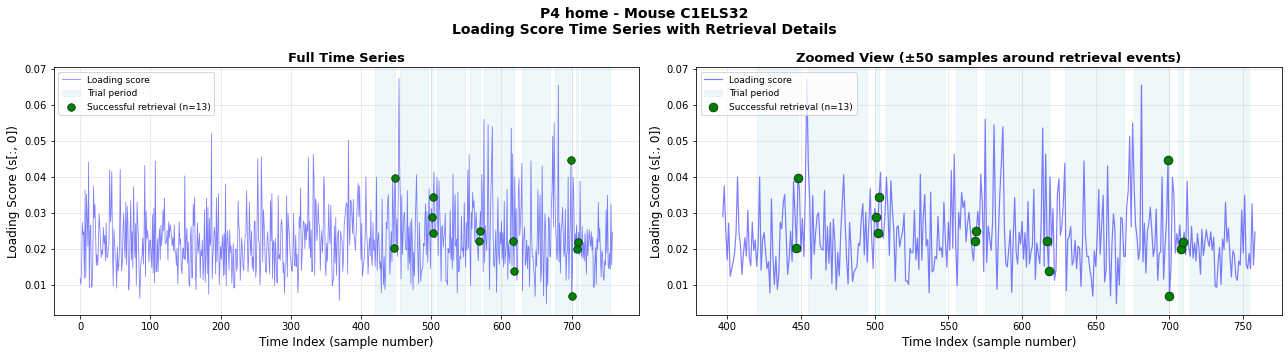

  ✓ Displayed plot for Mouse C1ELS32
  Mouse C5ELS40: 600 samples total
    - no trial (0): 519 samples
    - trial no retrieval (1): 61 samples
    - successful retrieval (4): 20 samples


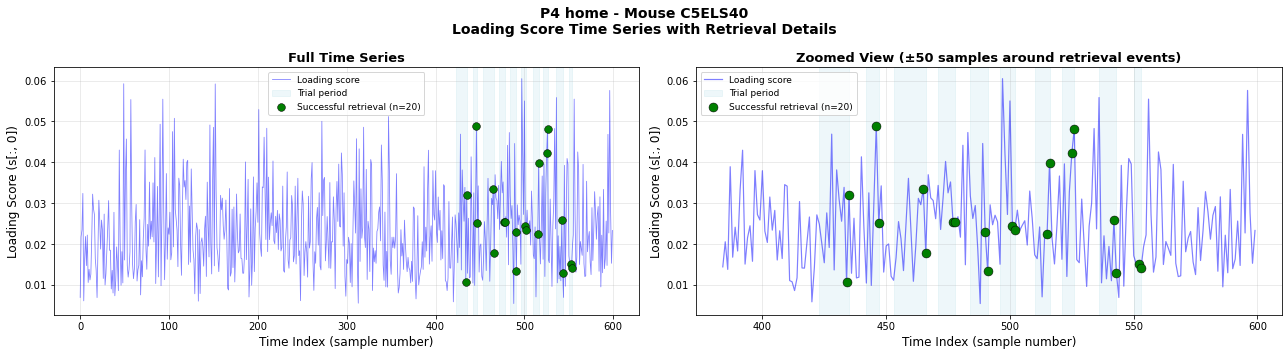

  ✓ Displayed plot for Mouse C5ELS40
  Mouse C6ELS42: 765 samples total
    - no trial (0): 557 samples
    - trial no retrieval (1): 192 samples
    - partial retrieval (3): 1 samples
    - successful retrieval (4): 15 samples


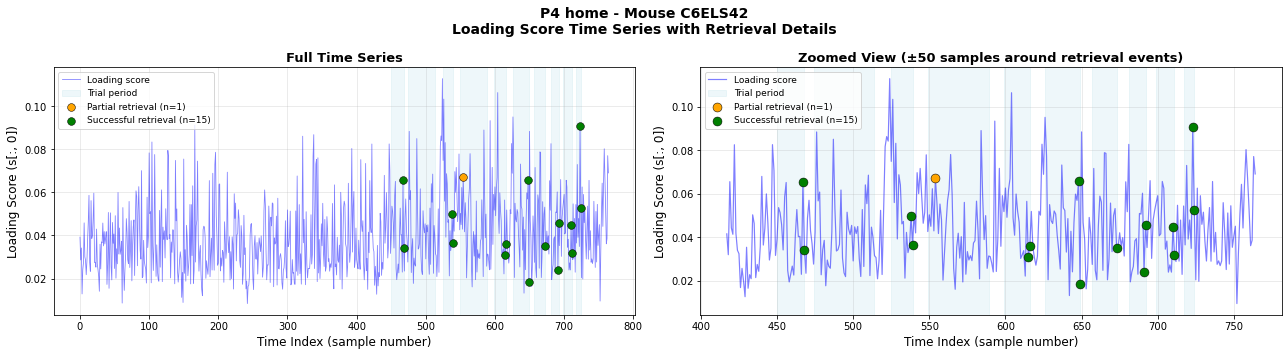

  ✓ Displayed plot for Mouse C6ELS42
  Mouse C7ELS45: 819 samples total
    - no trial (0): 750 samples
    - trial no retrieval (1): 45 samples
    - partial retrieval (3): 6 samples
    - successful retrieval (4): 18 samples


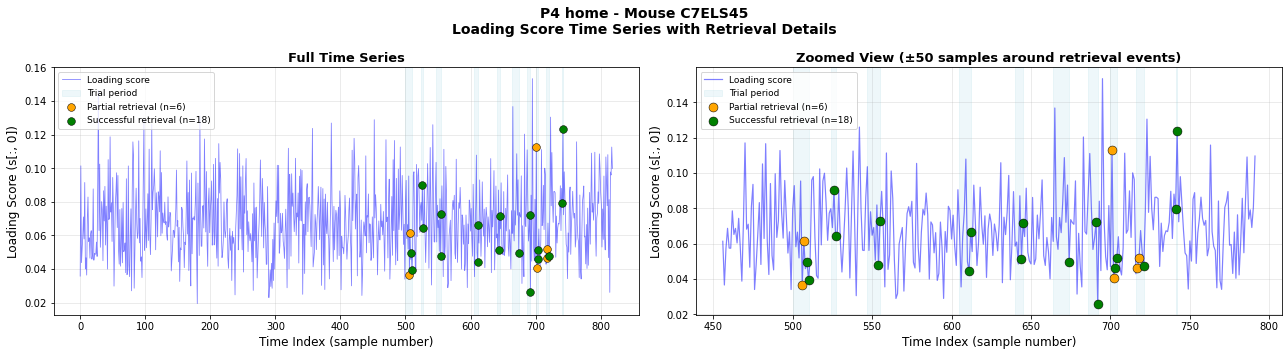

  ✓ Displayed plot for Mouse C7ELS45

Plotting: E - P4 home

PLOTTING: P4 home
s_scores shape: (4765, 10)
Using ONLY first loading dimension: s[:, 0]
⚠️  Assuming samples are in TIME ORDER within each mouse!
  Mouse E1ELS33: 756 samples total
    - no trial (0): 513 samples
    - trial no retrieval (1): 231 samples
    - successful retrieval (4): 12 samples


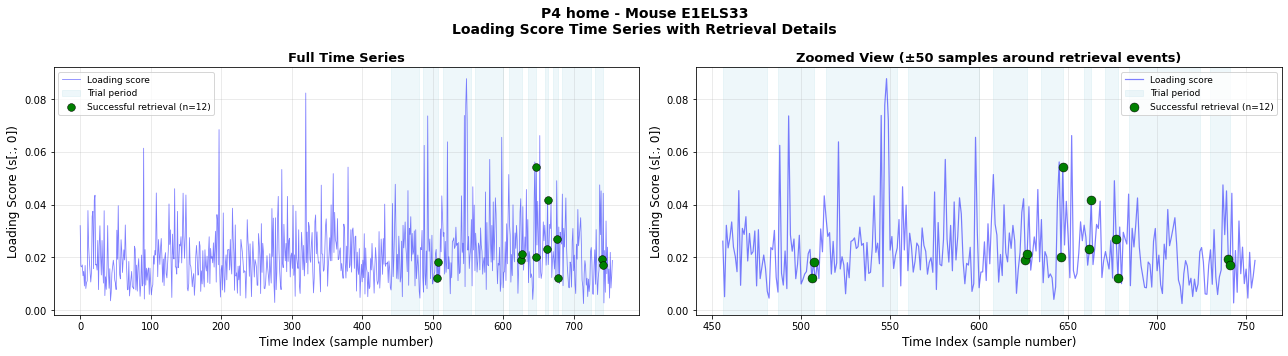

  ✓ Displayed plot for Mouse E1ELS33
  Skipping E3ELS37: no label=1 samples
  Mouse E4ELS39: 795 samples total
    - no trial (0): 556 samples
    - trial no retrieval (1): 222 samples
    - partial retrieval (3): 6 samples
    - successful retrieval (4): 11 samples


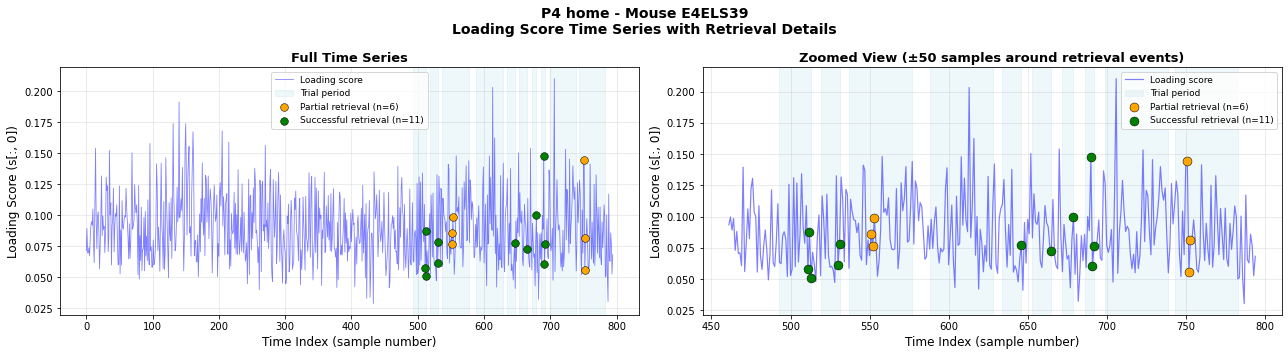

  ✓ Displayed plot for Mouse E4ELS39
  Mouse E5ELS41: 1652 samples total
    - no trial (0): 1301 samples
    - trial no retrieval (1): 343 samples
    - partial retrieval (3): 4 samples
    - successful retrieval (4): 4 samples


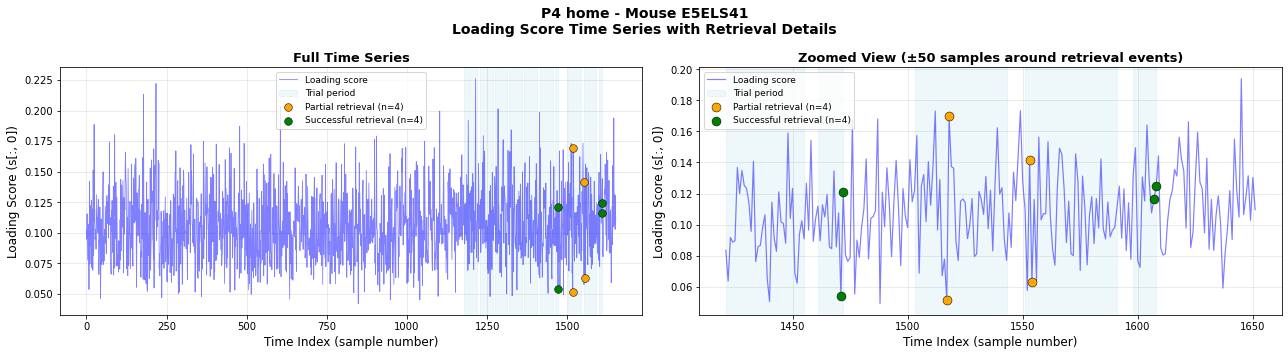

  ✓ Displayed plot for Mouse E5ELS41
  Mouse E6ELS44: 669 samples total
    - no trial (0): 560 samples
    - trial no retrieval (1): 88 samples
    - partial retrieval (3): 2 samples
    - successful retrieval (4): 19 samples


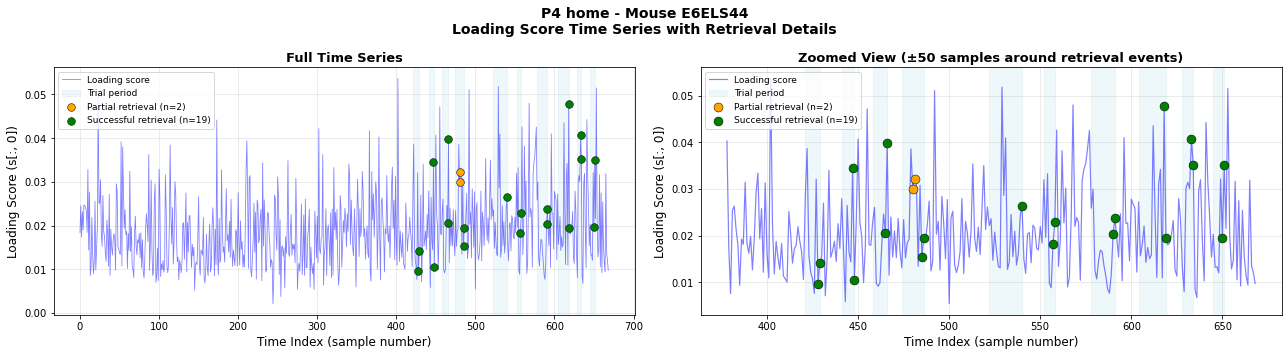

  ✓ Displayed plot for Mouse E6ELS44

ANALYSIS COMPLETE


In [33]:
import pickle
import numpy as np
import pandas as pd
import torch
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import wilcoxon

# ============================================================================
# CONFIGURATION
# ============================================================================
PUP_RETRIEVAL_DATA_FILE = "/Volumes/rdss_rhultman/datashare/ELS and Maternal Behavior/Spec_Features_All/Combined/P4_pup_retrieval_detail.pkl"
X_FEATURE_LIST = ["power", "coh_sq_coherence"]
X_FEATURE_WEIGHTS = [1, 1]
Y_FEATURE = "pup_retrieval"
Y_INTERCEPT_FEATURE = "mouse_id"
Y_SAMPLING_FEATURE = "mouse_id"

# Model file - should be defined in environment as MODEL_SAVE_FILE
# Example: MODEL_SAVE_FILE = "Maternal_model_TrainC_Pre_P134_Oct23.pt"

# Threshold for filtering
MIN_LABEL_1_SAMPLES = 10
# Pup retrieval detail labels
PUP_RETRIEVAL_DETAIL_LABELS = {
    0: "no trial",
    1: "trial no retrieval",
    3: "partial retrieval",
    4: "successful retrieval"
}

# Define C and E mouse groups (TARGET ANIMALS)
C_MICE_IDS = ['C6ELS9', 'C7ELS11', 'C2ELS18', 'C5ELS20', 'C7ELS22', 
              'C1ELS32', 'C5ELS40', 'C6ELS42', 'C7ELS45']
E_MICE_IDS = ['E2ELS3', 'E1ELS33', 'E3ELS37', 'E4ELS39', 'E5ELS41', 'E6ELS44']

# ============================================================================
# LOAD DATA
# ============================================================================
with open(PUP_RETRIEVAL_DATA_FILE, "rb") as f:
    pup_retrieval_dict = pickle.load(f)

# ============================================================================
# HELPER FUNCTIONS
# ============================================================================
def clean_mouse_id(mouse_id):
    import re
    cleaned = mouse_id.replace('Mouse', '')
    cleaned = re.sub(r'F\d+', '', cleaned)
    cleaned = cleaned.replace('_', '')
    return cleaned

cleaned_mouse_ids = np.array([clean_mouse_id(mid) for mid in pup_retrieval_dict['mouse_id']])

# Get all unique mice from the data
all_unique_mice = np.unique(cleaned_mouse_ids)
print(f"\nAll unique mice in data: {all_unique_mice}")
print(f"Total number of mice in file: {len(all_unique_mice)}")

# Find intersection with target animals
c_mice_in_data = [m for m in C_MICE_IDS if m in all_unique_mice]
e_mice_in_data = [m for m in E_MICE_IDS if m in all_unique_mice]
all_target_mice = c_mice_in_data + e_mice_in_data

print(f"\n{'='*60}")
print(f"TARGET ANIMALS (intersection with file)")
print(f"{'='*60}")
print(f"C group target mice: {C_MICE_IDS}")
print(f"C group in data: {c_mice_in_data} (n={len(c_mice_in_data)})")
print(f"\nE group target mice: {E_MICE_IDS}")
print(f"E group in data: {e_mice_in_data} (n={len(e_mice_in_data)})")
print(f"\nTotal target mice to analyze: {len(all_target_mice)}")

# Check periods
if 'period' in pup_retrieval_dict:
    unique_periods = np.unique(pup_retrieval_dict['period'])
    print(f"\nUnique periods in data: {unique_periods}")
    for p in unique_periods:
        print(f"  {p}: {np.sum(pup_retrieval_dict['period'] == p)} samples")
else:
    print("WARNING: No 'period' field found in data")

# Check pup_retrieval_detail
if 'pup_retrieval_detail' in pup_retrieval_dict:
    unique_details = np.unique(pup_retrieval_dict['pup_retrieval_detail'])
    print(f"\nUnique pup_retrieval_detail labels in data: {unique_details}")
    for d in unique_details:
        label_name = PUP_RETRIEVAL_DETAIL_LABELS.get(d, f"unknown ({d})")
        print(f"  {d} ({label_name}): {np.sum(pup_retrieval_dict['pup_retrieval_detail'] == d)} samples")
else:
    print("WARNING: No 'pup_retrieval_detail' field found in data")


def create_dataset(data, cleaned_mouse_ids, target_mouse_ids, target_period, dataset_name):
    """Create dataset - filter by target mouse_ids (intersection) and period"""
    
    # Filter: target mouse IDs only
    mouse_mask = np.isin(cleaned_mouse_ids, target_mouse_ids)
    
    # Filter: period
    if 'period' in data and target_period is not None:
        period_mask = data['period'] == target_period
        combined_mask = mouse_mask & period_mask
    else:
        combined_mask = mouse_mask
    
    print(f"\n{'='*60}")
    print(f"{dataset_name}")
    print(f"{'='*60}")
    
    # Check if there is data
    n_samples = np.sum(combined_mask)
    if n_samples == 0:
        print("⚠️  WARNING: No samples found!")
        return None
    
    # Apply mask to all data
    filtered_mouse_ids = cleaned_mouse_ids[combined_mask]
    filtered_y = data[Y_FEATURE][combined_mask]
    
    # Get pup_retrieval_detail if available
    if 'pup_retrieval_detail' in data:
        filtered_y_detail = data['pup_retrieval_detail'][combined_mask]
    else:
        filtered_y_detail = None
    
    # Get original indices for tracking time order - CRITICAL for time series!
    original_indices = np.where(combined_mask)[0]
    
    # Check if data is already time-ordered per mouse
    print(f"\n⚠️  IMPORTANT: Assuming data is already time-ordered within each mouse!")
    print(f"   If not, the time series plots will be incorrect.")
    
    print(f"Period: {target_period}")
    print(f"Total samples: {n_samples}")
    print(f"Target mice: {target_mouse_ids}")
    print(f"Mice in dataset: {np.unique(filtered_mouse_ids)}")
    print(f"Number of mice: {len(np.unique(filtered_mouse_ids))}")
    print(f"Label distribution: label_0={np.sum(filtered_y==0)}, label_1={np.sum(filtered_y==1)}")
    
    # Per-mouse distribution
    print(f"\nPer-mouse data:")
    for mouse_id in np.unique(filtered_mouse_ids):
        mouse_mask_inner = filtered_mouse_ids == mouse_id
        mouse_y = filtered_y[mouse_mask_inner]
        print(f"  {mouse_id}: n={len(mouse_y)}, label_0={np.sum(mouse_y==0)}, label_1={np.sum(mouse_y==1)}")
    
    # Prepare X features
    X_list = []
    for feature, weight in zip(X_FEATURE_LIST, X_FEATURE_WEIGHTS):
        feature_data = data[feature][combined_mask]
        X_list.append(feature_data * weight)
    
    X_data = np.hstack(X_list)
    
    print(f"\nFeature shapes after filtering:")
    print(f"  power: {data['power'][combined_mask].shape}")
    print(f"  coh_sq_coherence: {data['coh_sq_coherence'][combined_mask].shape}")
    print(f"  X combined: {X_data.shape}")
    print(f"  y: {filtered_y.shape}")
    
    y_data = filtered_y.reshape(-1, 1)
    y_intercept_data = filtered_mouse_ids
    
    # Encoders
    ordinal_encoder = OrdinalEncoder()
    y_sampling_data = ordinal_encoder.fit_transform(y_intercept_data.reshape(-1, 1))
    
    onehot_encoder = OneHotEncoder()
    y_intercept_mask_data = onehot_encoder.fit_transform(y_intercept_data.reshape(-1, 1)).todense()
    
    dataset = {
        'X': X_data,
        'y': y_data,
        'y_detail': filtered_y_detail,  # Add detailed labels
        'y_intercept': y_intercept_data,
        'y_sampling': y_sampling_data,
        'y_intercept_mask': y_intercept_mask_data,
        'intercept_dim': y_intercept_mask_data.shape[1],
        'mouse_list': np.unique(filtered_mouse_ids),
        'period': target_period,
        'original_indices': original_indices  # Track original time order
    }
    
    return dataset


def calculate_per_mouse_auc(model, X, y_true, mouse_ids, dataset_name):
    """Calculate overall and per-mouse AUC statistics"""
    # Ensure eval mode
    model.eval()
    with torch.no_grad():
        y_pred_proba, s = model.predict_proba(X, include_scores=True)
    
    # Flatten y_true
    y_true_flat = y_true.flatten() if len(y_true.shape) > 1 else y_true
    
    # Overall AUC
    overall_auc = roc_auc_score(y_true_flat, y_pred_proba)
    
    print(f"\n{'='*60}")
    print(f"{dataset_name}")
    print(f"{'='*60}")
    print(f"Overall AUC: {overall_auc:.4f}")
    
    # Per-mouse AUC
    unique_mouse_ids = np.unique(mouse_ids)
    per_mouse_results = []
    
    print("\nPer-mouse AUC:")
    for mouse_id in unique_mouse_ids:
        mouse_mask = mouse_ids == mouse_id
        y_true_mouse = y_true_flat[mouse_mask]
        y_pred_mouse = y_pred_proba[mouse_mask]
        
        if len(np.unique(y_true_mouse)) > 1:
            mouse_auc = roc_auc_score(y_true_mouse, y_pred_mouse)
            per_mouse_results.append({
                'Mouse_ID': mouse_id,
                'AUC': mouse_auc,
                'N_samples': len(y_true_mouse),
                'N_label_0': int(np.sum(y_true_mouse==0)),
                'N_label_1': int(np.sum(y_true_mouse==1))
            })
            print(f"  {mouse_id}: {mouse_auc:.4f}")
        else:
            print(f"  {mouse_id}: SKIPPED (single class)")
    
    # Mouse-wise statistics
    per_mouse_aucs = [r['AUC'] for r in per_mouse_results]
    
    if per_mouse_aucs:
        mean_auc = np.mean(per_mouse_aucs)
        std_auc = np.std(per_mouse_aucs, ddof=1)
        sem_auc = std_auc / np.sqrt(len(per_mouse_aucs))
        
        print(f"\nMouse-wise AUC statistics:")
        print(f"  Mean: {mean_auc:.4f}")
        print(f"  SEM: {sem_auc:.4f}")
        print(f"  STD: {std_auc:.4f}")
        print(f"  N mice: {len(per_mouse_aucs)}")
        
        return {
            'overall_auc': overall_auc,
            'per_mouse_aucs': per_mouse_aucs,
            'mean_auc': mean_auc,
            'std_auc': std_auc,
            'sem_auc': sem_auc,
            'n_mice': len(per_mouse_aucs),
            'per_mouse_details': per_mouse_results,
            's_scores': s,  # Return loading scores
            'y_pred_proba': y_pred_proba
        }
    else:
        print("\n⚠️  No mice with both classes")
        return {
            'overall_auc': overall_auc,
            'per_mouse_aucs': [],
            'mean_auc': None,
            'std_auc': None,
            'sem_auc': None,
            'n_mice': 0,
            'per_mouse_details': [],
            's_scores': s,
            'y_pred_proba': y_pred_proba
        }


def calculate_contrast_auc(model, X, y_detail, mouse_ids, dataset_name):
    """
    Calculate AUC for contrast: label 1 (response=0) vs labels 3/4 (response=1)
    Only include samples where y_detail is in [1, 3, 4]
    """
    print(f"\n{'='*60}")
    print(f"CONTRAST ANALYSIS: {dataset_name}")
    print(f"Label 1 (trial no retrieval) = response 0")
    print(f"Labels 3/4 (partial/successful retrieval) = response 1")
    print(f"{'='*60}")
    
    # Filter to only include labels 1, 3, 4
    contrast_mask = np.isin(y_detail, [1, 3, 4])
    
    if np.sum(contrast_mask) == 0:
        print("⚠️  No samples with labels 1, 3, or 4")
        return None
    
    # Apply filter
    X_contrast = X[contrast_mask]
    y_detail_contrast = y_detail[contrast_mask]
    mouse_ids_contrast = mouse_ids[contrast_mask]
    
    # Create binary response: 1 -> 0, 3/4 -> 1
    y_contrast = np.zeros(len(y_detail_contrast))
    y_contrast[np.isin(y_detail_contrast, [3, 4])] = 1
    
    print(f"\nContrast data:")
    print(f"  Total samples: {len(y_contrast)}")
    print(f"  Label 1 (response=0): {np.sum(y_contrast==0)}")
    print(f"  Labels 3/4 (response=1): {np.sum(y_contrast==1)}")
    
    # Get model predictions
    model.eval()
    with torch.no_grad():
        y_pred_proba, s = model.predict_proba(X_contrast, include_scores=True)
    
    # Overall AUC
    if len(np.unique(y_contrast)) > 1:
        overall_auc = roc_auc_score(y_contrast, y_pred_proba)
        print(f"\nOverall Contrast AUC: {overall_auc:.4f}")
    else:
        print("\n⚠️  Only one class in contrast data")
        overall_auc = np.nan
    
    # Per-mouse AUC
    unique_mouse_ids = np.unique(mouse_ids_contrast)
    per_mouse_results = []
    
    print("\nPer-mouse Contrast AUC:")
    for mouse_id in unique_mouse_ids:
        mouse_mask = mouse_ids_contrast == mouse_id
        y_contrast_mouse = y_contrast[mouse_mask]
        y_pred_mouse = y_pred_proba[mouse_mask]
        
        # Check if mouse has both classes
        if len(np.unique(y_contrast_mouse)) > 1:
            mouse_auc = roc_auc_score(y_contrast_mouse, y_pred_mouse)
            per_mouse_results.append({
                'Mouse_ID': mouse_id,
                'Contrast_AUC': mouse_auc,
                'N_samples': len(y_contrast_mouse),
                'N_response_0': int(np.sum(y_contrast_mouse==0)),
                'N_response_1': int(np.sum(y_contrast_mouse==1))
            })
            print(f"  {mouse_id}: {mouse_auc:.4f} (n_0={int(np.sum(y_contrast_mouse==0))}, n_1={int(np.sum(y_contrast_mouse==1))})")
        else:
            print(f"  {mouse_id}: SKIPPED (single class)")
    
    # Mouse-wise statistics
    per_mouse_aucs = [r['Contrast_AUC'] for r in per_mouse_results]
    
    if per_mouse_aucs:
        mean_auc = np.mean(per_mouse_aucs)
        std_auc = np.std(per_mouse_aucs, ddof=1)
        sem_auc = std_auc / np.sqrt(len(per_mouse_aucs))
        
        print(f"\nMouse-wise Contrast AUC statistics:")
        print(f"  Mean: {mean_auc:.4f}")
        print(f"  SEM: {sem_auc:.4f}")
        print(f"  STD: {std_auc:.4f}")
        print(f"  N mice: {len(per_mouse_aucs)}")
        
        return {
            'overall_auc': overall_auc,
            'per_mouse_aucs': per_mouse_aucs,
            'mean_auc': mean_auc,
            'std_auc': std_auc,
            'sem_auc': sem_auc,
            'n_mice': len(per_mouse_aucs),
            'per_mouse_details': per_mouse_results
        }
    else:
        print("\n⚠️  No mice with both classes in contrast")
        return {
            'overall_auc': overall_auc,
            'per_mouse_aucs': [],
            'mean_auc': None,
            'std_auc': None,
            'sem_auc': None,
            'n_mice': 0,
            'per_mouse_details': []
        }


def wilcoxon_test_vs_chance(per_mouse_results, group_name, auc_key='AUC'):
    """
    Perform one-sided Wilcoxon signed-rank test: H1: AUC > 0.5
    Skip mice with single class (all 0 or all 1)
    
    Parameters:
    - per_mouse_results: list of dicts with 'Mouse_ID', 'AUC' or 'Contrast_AUC', etc.
    - group_name: name of the group for printing
    - auc_key: key to extract AUC values ('AUC' or 'Contrast_AUC')
    
    Returns:
    - dict with test results
    """
    print(f"\n{'='*60}")
    print(f"WILCOXON SIGNED-RANK TEST: {group_name}")
    print(f"{'='*60}")
    print(f"Null hypothesis (H0): median AUC = 0.5")
    print(f"Alternative hypothesis (H1): median AUC > 0.5 (one-sided)")
    
    # Extract AUCs (already filtered to only include mice with both classes)
    aucs = np.array([r[auc_key] for r in per_mouse_results])
    
    if len(aucs) == 0:
        print("⚠️  No valid mice for testing (all skipped due to single class)")
        return {
            'group': group_name,
            'n_mice': 0,
            'mean_auc': np.nan,
            'sem_auc': np.nan,
            'p_value': np.nan,
            'statistic': np.nan
        }
    
    # Calculate statistics
    mean_auc = np.mean(aucs)
    sem_auc = np.std(aucs, ddof=1) / np.sqrt(len(aucs))
    
    print(f"\nSample statistics:")
    print(f"  N mice: {len(aucs)}")
    print(f"  Mean AUC: {mean_auc:.4f}")
    print(f"  SEM: {sem_auc:.4f}")
    print(f"  AUCs: {aucs}")
    
    # Perform Wilcoxon signed-rank test
    # Test if AUC - 0.5 > 0 (one-sided)
    differences = aucs - 0.5
    
    # Check if all differences are zero
    if np.all(differences == 0):
        print("\n⚠️  All AUCs equal to 0.5, cannot perform test")
        return {
            'group': group_name,
            'n_mice': len(aucs),
            'mean_auc': mean_auc,
            'sem_auc': sem_auc,
            'p_value': np.nan,
            'statistic': np.nan
        }
    
    # Perform test (alternative='greater' for one-sided test AUC > 0.5)
    try:
        statistic, p_value_two_sided = wilcoxon(differences, alternative='two-sided')
        # For one-sided test (greater), divide two-sided p-value by 2 if median > 0
        if np.median(differences) > 0:
            p_value_one_sided = p_value_two_sided / 2
        else:
            p_value_one_sided = 1 - p_value_two_sided / 2
        
        print(f"\nWilcoxon test results:")
        print(f"  Statistic: {statistic:.4f}")
        print(f"  One-sided p-value (AUC > 0.5): {p_value_one_sided:.6f}")
        
        if p_value_one_sided < 0.001:
            print(f"  Significance: *** (p < 0.001)")
        elif p_value_one_sided < 0.01:
            print(f"  Significance: ** (p < 0.01)")
        elif p_value_one_sided < 0.05:
            print(f"  Significance: * (p < 0.05)")
        else:
            print(f"  Significance: n.s. (p >= 0.05)")
        
        return {
            'group': group_name,
            'n_mice': len(aucs),
            'mean_auc': mean_auc,
            'sem_auc': sem_auc,
            'p_value': p_value_one_sided,
            'statistic': statistic
        }
    
    except Exception as e:
        print(f"\n⚠️  Error performing Wilcoxon test: {e}")
        return {
            'group': group_name,
            'n_mice': len(aucs),
            'mean_auc': mean_auc,
            'sem_auc': sem_auc,
            'p_value': np.nan,
            'statistic': np.nan
        }


def plot_mouse_loading_timeseries(s_scores, y_true, y_detail, mouse_ids, period):
    """
    Plot loading score time series for each mouse with trial periods shaded
    
    Visualization scheme:
    - label 0 (no trial): no marking
    - labels 1, 3, 4 (all trial periods): light blue shaded regions
    - label 3 (partial retrieval): orange points ON TOP of shading
    - label 4 (successful retrieval): green points ON TOP of shading
    
    CRITICAL ASSUMPTION: 
    - The input data must be in TIME ORDER within each mouse
    
    Parameters:
    - s_scores: shape (n_samples, n_loading_dims), uses ONLY s[:, 0] (first loading dimension)
    - y_true: binary labels (0/1) for AUC calculation
    - y_detail: detailed labels (0, 1, 3, 4)
    """
    unique_mice = np.unique(mouse_ids)
    y_true_flat = y_true.flatten() if len(y_true.shape) > 1 else y_true
    
    # s_scores should be 2D: (n_samples, n_loading_dims)
    if len(s_scores.shape) == 1:
        s_scores = s_scores.reshape(-1, 1)
    
    # Extract ONLY the first loading dimension
    s_first_dim = s_scores[:, 0]
    
    print(f"\n{'='*60}")
    print(f"PLOTTING: {period}")
    print(f"{'='*60}")
    print(f"s_scores shape: {s_scores.shape}")
    print(f"Using ONLY first loading dimension: s[:, 0]")
    print(f"⚠️  Assuming samples are in TIME ORDER within each mouse!")
    
    for mouse_id in unique_mice:
        mouse_mask = mouse_ids == mouse_id
        mouse_s = s_first_dim[mouse_mask]
        mouse_y = y_true_flat[mouse_mask]
        mouse_y_detail = y_detail[mouse_mask] if y_detail is not None else None
        
        # Time indices (assuming sequential order)
        time_indices = np.arange(len(mouse_y))
        
        # Find label=1 indices (any retrieval behavior)
        label1_indices = np.where(mouse_y == 1)[0]
        
        if len(label1_indices) == 0:
            print(f"  Skipping {mouse_id}: no label=1 samples")
            continue
        
        # Count different detail labels
        if mouse_y_detail is not None:
            unique_details, detail_counts = np.unique(mouse_y_detail, return_counts=True)
            print(f"  Mouse {mouse_id}: {len(mouse_y)} samples total")
            for ud, dc in zip(unique_details, detail_counts):
                label_name = PUP_RETRIEVAL_DETAIL_LABELS.get(ud, f"unknown ({ud})")
                print(f"    - {label_name} ({ud}): {dc} samples")
        else:
            print(f"  Mouse {mouse_id}: {len(mouse_y)} samples, {len(label1_indices)} label=1 samples")
        
        # Calculate zoom window
        zoom_start = max(0, label1_indices[0] - 50)
        zoom_end = min(len(mouse_y), label1_indices[-1] + 50)
        
        # Create figure with 1 row, 2 columns (full view + zoomed view)
        fig, axes = plt.subplots(1, 2, figsize=(18, 5))
        
        # ========== FULL PLOT (left) ==========
        ax_full = axes[0]
        
        # Plot baseline time series
        ax_full.plot(time_indices, mouse_s, 'b-', alpha=0.5, linewidth=0.8, label='Loading score')
        
        if mouse_y_detail is not None:
            # Find ALL trial periods (labels 1, 3, 4) and shade them together
            trial_indices = np.where(np.isin(mouse_y_detail, [1, 3, 4]))[0]
            if len(trial_indices) > 0:
                # Find contiguous segments for all trials
                segments = []
                start_idx = trial_indices[0]
                for i in range(1, len(trial_indices)):
                    if trial_indices[i] != trial_indices[i-1] + 1:
                        # End of segment
                        segments.append((start_idx, trial_indices[i-1]))
                        start_idx = trial_indices[i]
                # Add last segment
                segments.append((start_idx, trial_indices[-1]))
                
                # Shade each trial segment
                for seg_start, seg_end in segments:
                    ax_full.axvspan(seg_start, seg_end, alpha=0.2, color='lightblue', 
                                   label='Trial period' if seg_start == segments[0][0] else '')
            
            # Plot partial retrieval (label 3) - orange points ON TOP
            partial_indices = np.where(mouse_y_detail == 3)[0]
            if len(partial_indices) > 0:
                ax_full.scatter(partial_indices, mouse_s[partial_indices], 
                              c='orange', s=60, marker='o', zorder=5, 
                              label=f'Partial retrieval (n={len(partial_indices)})', 
                              edgecolors='black', linewidths=0.5)
            
            # Plot successful retrieval (label 4) - green points ON TOP
            successful_indices = np.where(mouse_y_detail == 4)[0]
            if len(successful_indices) > 0:
                ax_full.scatter(successful_indices, mouse_s[successful_indices], 
                              c='green', s=60, marker='o', zorder=5, 
                              label=f'Successful retrieval (n={len(successful_indices)})', 
                              edgecolors='black', linewidths=0.5)
        else:
            # Fallback: just mark label=1
            ax_full.scatter(label1_indices, mouse_s[label1_indices], 
                          c='red', s=50, marker='o', zorder=5, label='Label=1')
        
        ax_full.set_xlabel('Time Index (sample number)', fontsize=12)
        ax_full.set_ylabel('Loading Score (s[:, 0])', fontsize=12)
        ax_full.set_title('Full Time Series', fontsize=13, fontweight='bold')
        ax_full.legend(loc='best', fontsize=9)
        ax_full.grid(True, alpha=0.3)
        
        # ========== ZOOMED PLOT (right) ==========
        ax_zoom = axes[1]
        zoom_time = time_indices[zoom_start:zoom_end]
        zoom_s = mouse_s[zoom_start:zoom_end]
        zoom_y_detail = mouse_y_detail[zoom_start:zoom_end] if mouse_y_detail is not None else None
        
        # Plot baseline time series
        ax_zoom.plot(zoom_time, zoom_s, 'b-', alpha=0.5, linewidth=1.2, label='Loading score')
        
        if zoom_y_detail is not None:
            # Find ALL trial periods (labels 1, 3, 4) and shade them together
            trial_zoom = np.where(np.isin(zoom_y_detail, [1, 3, 4]))[0]
            if len(trial_zoom) > 0:
                # Find contiguous segments in zoomed view
                segments_zoom = []
                start_idx = trial_zoom[0]
                for i in range(1, len(trial_zoom)):
                    if trial_zoom[i] != trial_zoom[i-1] + 1:
                        segments_zoom.append((start_idx, trial_zoom[i-1]))
                        start_idx = trial_zoom[i]
                segments_zoom.append((start_idx, trial_zoom[-1]))
                
                # Shade each trial segment
                for seg_start, seg_end in segments_zoom:
                    ax_zoom.axvspan(zoom_time[seg_start], zoom_time[seg_end], 
                                   alpha=0.2, color='lightblue',
                                   label='Trial period' if seg_start == segments_zoom[0][0] else '')
            
            # Plot partial retrieval (label 3) - orange points ON TOP
            partial_zoom = np.where(zoom_y_detail == 3)[0]
            if len(partial_zoom) > 0:
                ax_zoom.scatter(zoom_time[partial_zoom], zoom_s[partial_zoom], 
                              c='orange', s=80, marker='o', zorder=5, 
                              label=f'Partial retrieval (n={len(partial_zoom)})', 
                              edgecolors='black', linewidths=0.5)
            
            # Plot successful retrieval (label 4) - green points ON TOP
            successful_zoom = np.where(zoom_y_detail == 4)[0]
            if len(successful_zoom) > 0:
                ax_zoom.scatter(zoom_time[successful_zoom], zoom_s[successful_zoom], 
                              c='green', s=80, marker='o', zorder=5, 
                              label=f'Successful retrieval (n={len(successful_zoom)})', 
                              edgecolors='black', linewidths=0.5)
        
        ax_zoom.set_xlabel('Time Index (sample number)', fontsize=12)
        ax_zoom.set_ylabel('Loading Score (s[:, 0])', fontsize=12)
        ax_zoom.set_title('Zoomed View (±50 samples around retrieval events)', fontsize=13, fontweight='bold')
        ax_zoom.legend(loc='best', fontsize=9)
        ax_zoom.grid(True, alpha=0.3)
        
        plt.suptitle(f'{period} - Mouse {mouse_id}\nLoading Score Time Series with Retrieval Details', 
                    fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()
        
        print(f"  ✓ Displayed plot for Mouse {mouse_id}")


# ============================================================================
# MAIN ANALYSIS
# ============================================================================
print("\n" + "="*80)
print("CREATING DATASETS")
print("="*80)

# P4 home datasets - using TARGET ANIMALS only
pup_c_p4_dataset = create_dataset(
    pup_retrieval_dict, 
    cleaned_mouse_ids,
    c_mice_in_data,
    'P4 home',
    "C MICE - P4 home"
)

pup_e_p4_dataset = create_dataset(
    pup_retrieval_dict,
    cleaned_mouse_ids,
    e_mice_in_data,
    'P4 home',
    "E MICE - P4 home"
)

# Combined dataset for overall analysis
pup_all_p4_dataset = create_dataset(
    pup_retrieval_dict, 
    cleaned_mouse_ids,
    all_target_mice,
    'P4 home',
    "ALL TARGET MICE - P4 home"
)

# Check if datasets were created successfully
datasets_to_process = []
if pup_c_p4_dataset is not None:
    datasets_to_process.append(('C', 'P4 home', pup_c_p4_dataset))
if pup_e_p4_dataset is not None:
    datasets_to_process.append(('E', 'P4 home', pup_e_p4_dataset))

if not datasets_to_process:
    print("\n⚠️  ERROR: No valid datasets created!")
    exit()

# ============================================================================
# MODEL PREDICTION
# ============================================================================
print("\n" + "="*80)
print("LOADING MODEL")
print("="*80)

model = torch.load(MODEL_SAVE_FILE, map_location='cpu')
model.device = 'cpu'

print("\n" + "="*80)
print("MODEL PREDICTIONS - MAIN ANALYSIS (0 vs 1)")
print("="*80)

all_results = []

for group, period, dataset in datasets_to_process:
    result = calculate_per_mouse_auc(
        model=model,
        X=dataset['X'],
        y_true=dataset['y'],
        mouse_ids=dataset['y_intercept'],
        dataset_name=f"{group} MICE - {period} - PUP RETRIEVAL"
    )
    result['group'] = group
    result['period'] = period
    result['dataset'] = dataset  # Store dataset for plotting
    all_results.append(result)

# ============================================================================
# CONTRAST ANALYSIS (label 1 vs 3/4)
# ============================================================================
print("\n" + "="*80)
print("CONTRAST ANALYSIS - Label 1 vs Labels 3/4")
print("="*80)

contrast_results = []

for group, period, dataset in datasets_to_process:
    if dataset['y_detail'] is not None:
        contrast_result = calculate_contrast_auc(
            model=model,
            X=dataset['X'],
            y_detail=dataset['y_detail'],
            mouse_ids=dataset['y_intercept'],
            dataset_name=f"{group} MICE - {period}"
        )
        if contrast_result is not None:
            contrast_result['group'] = group
            contrast_result['period'] = period
            contrast_results.append(contrast_result)

# ============================================================================
# WILCOXON SIGNED-RANK TESTS - MAIN ANALYSIS
# ============================================================================
print("\n" + "="*80)
print("STATISTICAL TESTING: MAIN AUC > 0.5")
print("="*80)

wilcoxon_main_results = []
for result in all_results:
    wilcoxon_result = wilcoxon_test_vs_chance(
        result['per_mouse_details'], 
        f"{result['group']} GROUP - MAIN",
        auc_key='AUC'
    )
    wilcoxon_main_results.append(wilcoxon_result)

# ============================================================================
# WILCOXON SIGNED-RANK TESTS - CONTRAST ANALYSIS
# ============================================================================
print("\n" + "="*80)
print("STATISTICAL TESTING: CONTRAST AUC > 0.5")
print("="*80)

wilcoxon_contrast_results = []
for result in contrast_results:
    wilcoxon_result = wilcoxon_test_vs_chance(
        result['per_mouse_details'], 
        f"{result['group']} GROUP - CONTRAST",
        auc_key='Contrast_AUC'
    )
    wilcoxon_contrast_results.append(wilcoxon_result)

# ============================================================================
# SUMMARY TABLES
# ============================================================================
print("\n" + "="*80)
print("SUMMARY: MAIN ANALYSIS (0 vs 1) BY GROUP")
print("="*80)

main_summary_data = []
for result, wilcoxon_result in zip(all_results, wilcoxon_main_results):
    main_summary_data.append({
        'Group': result['group'],
        'Period': result['period'],
        'N_mice': result['n_mice'],
        'Mean_AUC': result['mean_auc'] if result['mean_auc'] is not None else np.nan,
        'SEM': result['sem_auc'] if result['sem_auc'] is not None else np.nan,
        'STD': result['std_auc'] if result['std_auc'] is not None else np.nan,
        'Wilcoxon_p': wilcoxon_result['p_value']
    })

if main_summary_data:
    main_summary_df = pd.DataFrame(main_summary_data)
    print("\n" + main_summary_df.to_string(index=False, float_format='%.4f'))

print("\n" + "="*80)
print("SUMMARY: CONTRAST ANALYSIS (1 vs 3/4) BY GROUP")
print("="*80)

contrast_summary_data = []
for result, wilcoxon_result in zip(contrast_results, wilcoxon_contrast_results):
    contrast_summary_data.append({
        'Group': result['group'],
        'Period': result['period'],
        'N_mice': result['n_mice'],
        'Mean_Contrast_AUC': result['mean_auc'] if result['mean_auc'] is not None else np.nan,
        'SEM': result['sem_auc'] if result['sem_auc'] is not None else np.nan,
        'STD': result['std_auc'] if result['std_auc'] is not None else np.nan,
        'Wilcoxon_p': wilcoxon_result['p_value']
    })

if contrast_summary_data:
    contrast_summary_df = pd.DataFrame(contrast_summary_data)
    print("\n" + contrast_summary_df.to_string(index=False, float_format='%.4f'))

# ============================================================================
# COMBINED WILCOXON TESTS (C + E groups merged)
# ============================================================================
print("\n" + "="*80)
print("COMBINED WILCOXON TESTS (C + E groups merged)")
print("="*80)

# Combine all per-mouse results across C and E groups
all_main_details = []
for result in all_results:
    all_main_details.extend(result['per_mouse_details'])

all_contrast_details_combined = []
for result in contrast_results:
    all_contrast_details_combined.extend(result['per_mouse_details'])

# Perform combined Wilcoxon test for MAIN analysis
if all_main_details:
    combined_main_wilcoxon = wilcoxon_test_vs_chance(
        all_main_details, 
        "COMBINED (C+E) - MAIN ANALYSIS",
        auc_key='AUC'
    )
else:
    print("⚠️  No data for combined main Wilcoxon test")
    combined_main_wilcoxon = None

# Perform combined Wilcoxon test for CONTRAST analysis
if all_contrast_details_combined:
    combined_contrast_wilcoxon = wilcoxon_test_vs_chance(
        all_contrast_details_combined, 
        "COMBINED (C+E) - CONTRAST ANALYSIS",
        auc_key='Contrast_AUC'
    )
else:
    print("⚠️  No data for combined contrast Wilcoxon test")
    combined_contrast_wilcoxon = None

# Summary table for combined tests
print("\n" + "="*80)
print("SUMMARY: COMBINED WILCOXON TESTS")
print("="*80)

combined_wilcoxon_summary = []
if combined_main_wilcoxon is not None and combined_main_wilcoxon['n_mice'] > 0:
    combined_wilcoxon_summary.append({
        'Analysis': 'Main (0 vs 1)',
        'N_mice': combined_main_wilcoxon['n_mice'],
        'Mean_AUC': combined_main_wilcoxon['mean_auc'],
        'SEM': combined_main_wilcoxon['sem_auc'],
        'Wilcoxon_p': combined_main_wilcoxon['p_value']
    })

if combined_contrast_wilcoxon is not None and combined_contrast_wilcoxon['n_mice'] > 0:
    combined_wilcoxon_summary.append({
        'Analysis': 'Contrast (1 vs 3/4)',
        'N_mice': combined_contrast_wilcoxon['n_mice'],
        'Mean_AUC': combined_contrast_wilcoxon['mean_auc'],
        'SEM': combined_contrast_wilcoxon['sem_auc'],
        'Wilcoxon_p': combined_contrast_wilcoxon['p_value']
    })

if combined_wilcoxon_summary:
    combined_wilcoxon_df = pd.DataFrame(combined_wilcoxon_summary)
    print("\n" + combined_wilcoxon_df.to_string(index=False, float_format='%.4f'))

# ============================================================================
# PER-MOUSE DETAILS TABLE
# ============================================================================
print("\n" + "="*80)
print("PER-MOUSE DETAILS - MAIN ANALYSIS")
print("="*80)

all_details = []
for result in all_results:
    for detail in result['per_mouse_details']:
        detail['Period'] = result['period']
        detail['Group'] = result['group']
        all_details.append(detail)

if all_details:
    details_df = pd.DataFrame(all_details)
    details_df = details_df[['Period', 'Group', 'Mouse_ID', 'AUC', 'N_samples', 'N_label_0', 'N_label_1']]
    print("\n" + details_df.to_string(index=False, float_format='%.4f'))

print("\n" + "="*80)
print("PER-MOUSE DETAILS - CONTRAST ANALYSIS")
print("="*80)

all_contrast_details = []
for result in contrast_results:
    for detail in result['per_mouse_details']:
        detail['Period'] = result['period']
        detail['Group'] = result['group']
        all_contrast_details.append(detail)

if all_contrast_details:
    contrast_details_df = pd.DataFrame(all_contrast_details)
    contrast_details_df = contrast_details_df[['Period', 'Group', 'Mouse_ID', 'Contrast_AUC', 'N_samples', 'N_response_0', 'N_response_1']]
    print("\n" + contrast_details_df.to_string(index=False, float_format='%.4f'))

# ============================================================================
# PLOT LOADING TIME SERIES WITH DETAILED LABELS
# ============================================================================
print("\n" + "="*80)
print("GENERATING LOADING TIME SERIES PLOTS WITH RETRIEVAL DETAILS")
print("="*80)

for result in all_results:
    group = result['group']
    period = result['period']
    dataset = result['dataset']
    s_scores = result['s_scores']
    
    print(f"\nPlotting: {group} - {period}")
    plot_mouse_loading_timeseries(
        s_scores=s_scores,
        y_true=dataset['y'],
        y_detail=dataset['y_detail'],
        mouse_ids=dataset['y_intercept'],
        period=period
    )

print("\n" + "="*80)
print("ANALYSIS COMPLETE")
print("="*80)